# Runoff Ratio Analysis

Here, we will first compare the results of all model types for the east river for wet, normal, and dry years between 2000 and 2021. 

Then we will analyze the runoff ratio variability from each model. We will also include a baseline SWE-Q regression model using the Butte snotel and observed streamflow relationship. 

In [1]:
import os
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from pathlib import Path
import glob
os.chdir('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')
repo_root = Path.cwd()
from utils.custom import linear_reservoir


## Analysis Setup


In [2]:
DATA_DIR = Path("/scratch/dlhogan/ess-project-data/")
DOMAIN = "East_River"
lumped_dir = DATA_DIR / f"domain_{DOMAIN}_lumped" / "simulations" / "best_simulations"
distributed_elev_dir = DATA_DIR / f"domain_{DOMAIN}_distributed" / "simulations" / "best_simulations"
distributed_elev_aspect_dir = DATA_DIR / f"domain_{DOMAIN}_distributed_elevAspect" / "simulations" / "best_simulations"
distributed_elev_TPI_dir = DATA_DIR / f"domain_{DOMAIN}_distributed_elevTPI" / "simulations" / "best_simulations"

In [3]:
# get East precipitation data from forcining
FORCING_DIR = Path(F"/scratch/dlhogan/ess-project-data/domain_{DOMAIN}_lumped/forcing")
precip_files = sorted(glob.glob(str(FORCING_DIR / "SUMMA_input" / "*metsim*.nc")))

ppt_dss = []
for file in precip_files:
    ds = xr.open_dataset(file)['pptrate'].resample(time='1D').mean()*3600*24
    ppt_dss.append(ds)
    ds.close()

# merge datasets
wy_precip = xr.concat(ppt_dss, dim='time').resample(time='YS-OCT').sum()
# winter_precip = xr.concat(ppt_dss, dim='time')
# # water year winter is december - march
# winter_precip = winter_precip.where(winter_precip['time.month'].isin([12, 1, 2, 3])).resample(time='YS-DEC').sum()

In [4]:
wy_precip_df = wy_precip.to_dataframe() 
# remove hru index
wy_precip_df = wy_precip_df.reset_index(level='hru')
wy_precip_df.index = wy_precip_df.index.year + 1

In [5]:
# observed streamflow
obs_streamflow = pd.read_csv(DATA_DIR / f"domain_{DOMAIN}_distributed" / "observations" / "formatted" / "streamflow_obs.csv", 
                             parse_dates=['date'], 
                             index_col='date')

In [6]:
lumped_files = sorted(glob.glob(str(lumped_dir / "*.nc")))
distributed_elev_files = sorted(glob.glob(str(distributed_elev_dir / "*.nc")))
distributed_elev_aspect_files = sorted(glob.glob(str(distributed_elev_aspect_dir / "*.nc")))
# distributed_elev_TPI_files = sorted(glob.glob(str(distributed_elev_TPI_dir / "*.nc")))

In [7]:
east_linear_reservoir_params = {
                            "lumped":
                            {"noXplict_zeroFlux":{'k_fast': 0.03843939030166468, 'k_slow': 0.03755405444510841, 'f_fast': 1.0},
                             "noXplict_drainage": {'k_fast': 0.06308111559524023, 'k_slow': 0.001475925014222625, 'f_fast': 0.6052602949996202},
                             "bigBuckt": "averageInstantRunoff",},
                            "distributed_elev":
                            {"noXplict_drainage":{'k_fast': 0.054340140421693967, 'k_slow': 0.0003932011558550064, 'f_fast': 0.6052602949996202},
                             "bigBuckt": {'k_fast': 0.7729497280965281, 'k_slow': 2.1803944632295234e-07, 'f_fast': 0.8253809118991199}, # or averageInstantRunoff
                             "qTopmodl":{'k_fast': 0.07815593491892166, 'k_slow': 8.302487117517937e-05, 'f_fast': 0.6052602949996202}},
                            "distributed_elevAspect":
                            {"noXplict_drainage": {'k_fast': 0.10132269760097318, 'k_slow': 0.0003703317283164696, 'f_fast': 0.6395810725483903},
                             "bigBuckt": {'k_fast': 0.4729497280965281, 'k_slow': 2.1803944632295235e-05, 'f_fast': 0.7853809118991199},
                             "qTopmodl": {'k_fast': 0.05472818779380724, 'k_slow': 0.0023037617204891884, 'f_fast': 0.6391567712268422}},
                            "distributed_elevTPI":
                            {"noXplict_drainage": {'k_fast': 1.822324320617592, 'k_slow': 0.00031067997893722475, 'f_fast': 0.7250497141662837},
                                "bigBuckt": {'k_fast': 0.47522528151425714, 'k_slow': 2.4805360274754705e-05, 'f_fast': 0.8004766558786294}, # or averageRoutedRunoff
                                "qTopmodl": {'k_fast': 0.1623748491901542, 'k_slow': 0.00013522283690493175, 'f_fast': 0.9022690067688268}
                            }}                  

## Model permformace diagnostics

In [8]:
NORMAL_WY = slice("2015-10-01", "2016-09-30")
WET_WY = slice("2010-10-01", "2011-09-30")
DRY_WY = slice("2011-10-01", "2012-09-30")

In [9]:
model_files = {
    "lumped": {
        "bigBuckt":          lumped_dir / "lumped_bigBuckt_best_lonterm.nc",
        "noXplict_drainage": lumped_dir / "lumped_noXplict_drainage_best_longterm.nc",
        "noXplict_zeroFlux": lumped_dir / "lumped_noXplict_zeroFlux_best_longterm.nc",
    },
    "distributed_elev": {
        "bigBuckt":          distributed_elev_dir / "distributed_elevation_bigBuckt_best_longterm.nc",
        "noXplict_drainage": distributed_elev_dir / "distributed_elevation_noXplict_best_longterm.nc",
        "qTopmodl":          distributed_elev_dir / "distributed_elevation_qTopmodl_best_longterm.nc",
    },
    "distributed_elevAspect": {
        "noXplict_drainage": distributed_elev_aspect_dir / "distributed_elevAspect_best_longterm.nc",
        "bigBuckt":          distributed_elev_aspect_dir / "distributed_elevAspect_bigBuckt_best_longterm.nc",
        "qTopmodl":          distributed_elev_aspect_dir / "distributed_elevAspect_qTopmodl_best_longterm.nc",
    },
    "distributed_elevTPI": {
        "noXplict_drainage": distributed_elev_TPI_dir / "distributed_elevTPI_noXplict_best_longterm.nc",
        "bigBuckt":          distributed_elev_TPI_dir / "distributed_elevTPI_bigBuckt_best_longterm.nc",
        "qTopmodl":          distributed_elev_TPI_dir / "distributed_elevTPI_qTopmodl_best_longterm.nc",
    }

}

attr_paths = {
    "lumped":                DATA_DIR / f"domain_{DOMAIN}_lumped/settings/SUMMA/attributes.nc",
    "distributed_elev":      DATA_DIR / f"domain_{DOMAIN}_distributed/settings/SUMMA/attributes.nc",
    "distributed_elevAspect": DATA_DIR / f"domain_{DOMAIN}_distributed_elevAspect/settings/SUMMA/attributes.nc",
    "distributed_elevTPI": DATA_DIR / f"domain_{DOMAIN}_distributed_elevTPI/settings/SUMMA/attributes.nc"
}
domain_areas = {dom: float(xr.open_dataset(p)['HRUarea'].sum()) for dom, p in attr_paths.items()}

In [10]:
model_discharge = {}

for domain, models in model_files.items():
    area_m2 = domain_areas[domain]
    model_discharge[domain] = {}
    for model_key, filepath in models.items():
        params = east_linear_reservoir_params[domain][model_key]
        ds = xr.open_dataset(filepath)
        # start with 2002-10-01, post spinup
        ds = ds.sel(time=slice("2000-10-01", "2021-09-30"))

        if isinstance(params, str):
            # Use the named variable directly (m s-1 * area -> m3/s)
            try:
                var = ds[params].squeeze()
            except KeyError:
                available = [v for v in ds.data_vars if 'Runoff' in v or 'runoff' in v or 'Routed' in v]
                raise KeyError(
                    f"Variable '{params}' not found in {filepath.name}. "
                    f"Runoff-related vars present: {available}"
                )
            q_daily = (var * area_m2).resample(time='1D').mean().to_series()
        else:
            # For distributed runs prefer basin__TotalRunoff when available; else averageInstantRunoff
            if 'basin__TotalRunoff' in ds.data_vars:
                var = ds['basin__TotalRunoff'].squeeze()
            else:
                var = ds['averageInstantRunoff'].squeeze()
            daily_da = (var * area_m2).resample(time='1D').mean()
            q_in = daily_da.values
            time_idx = pd.DatetimeIndex(daily_da.time.values)
            routed = linear_reservoir.two_reservoir_daily(
                q_in, params['k_fast'], params['k_slow'], params['f_fast']
            )
            q_daily = pd.Series(routed, index=time_idx)

        model_discharge[domain][model_key] = q_daily
        print(f"{domain}/{model_key}: {len(q_daily)} daily values, "
              f"mean={q_daily.mean():.2f} m³/s")

lumped/bigBuckt: 7670 daily values, mean=9.02 m³/s
lumped/noXplict_drainage: 7670 daily values, mean=8.09 m³/s
lumped/noXplict_zeroFlux: 7670 daily values, mean=6.14 m³/s
distributed_elev/bigBuckt: 7670 daily values, mean=7.95 m³/s
distributed_elev/noXplict_drainage: 7670 daily values, mean=8.04 m³/s
distributed_elev/qTopmodl: 7670 daily values, mean=7.57 m³/s
distributed_elevAspect/noXplict_drainage: 7670 daily values, mean=8.53 m³/s
distributed_elevAspect/bigBuckt: 7670 daily values, mean=8.54 m³/s
distributed_elevAspect/qTopmodl: 7670 daily values, mean=8.13 m³/s
distributed_elevTPI/noXplict_drainage: 7670 daily values, mean=7.87 m³/s
distributed_elevTPI/bigBuckt: 7670 daily values, mean=7.82 m³/s
distributed_elevTPI/qTopmodl: 7670 daily values, mean=8.00 m³/s


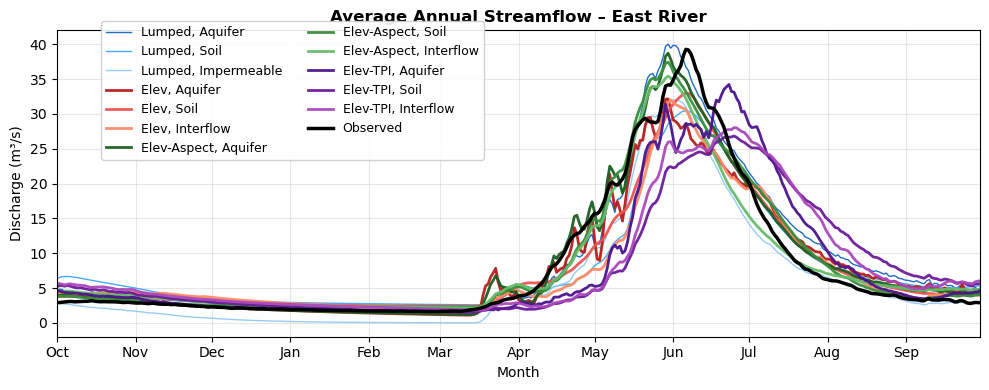

In [11]:
from matplotlib import dates as mdates
model_styles = {
    "lumped": {
        "bigBuckt":          {"color": "#1565C0", "ls": "-",  "label": "Lumped, Aquifer", "lw": 1},
        "noXplict_drainage": {"color": "#42A5F5", "ls": "-",  "label": "Lumped, Soil", "lw": 1},
        "noXplict_zeroFlux": {"color": "#90CAF9", "ls": "-",  "label": "Lumped, Impermeable", "lw": 1},
    },
    "distributed_elev": {
        "bigBuckt":          {"color": "#B71C1C", "ls": "-", "label": "Elev, Aquifer", "lw": 2},
        "noXplict_drainage": {"color": "#EF5350", "ls": "-", "label": "Elev, Soil", "lw": 2},
        "qTopmodl":          {"color": "#FF8A65", "ls": "-", "label": "Elev, Interflow", "lw": 2},
    },
    "distributed_elevAspect": {
        "bigBuckt":          {"color": "#1B5E20", "ls": "-",  "label": "Elev-Aspect, Aquifer", "lw": 2},
        "noXplict_drainage": {"color": "#388E3C", "ls": "-",  "label": "Elev-Aspect, Soil", "lw": 2},
        "qTopmodl":          {"color": "#66BB6A", "ls": "-",  "label": "Elev-Aspect, Interflow", "lw": 2},
    },
    "distributed_elevTPI": {
        "noXplict_drainage": {"color": "#4A148C", "ls": "-",  "label": "Elev-TPI, Aquifer", "lw": 2},
        "bigBuckt":          {"color": "#6A1B9A", "ls": "-",  "label": "Elev-TPI, Soil", "lw": 2},
        "qTopmodl":          {"color": "#AB47BC", "ls": "-",  "label": "Elev-TPI, Interflow", "lw": 2},
    }
}

# Reference water year (non-leap) for x-axis
ref_dates = pd.date_range("2000-10-01", "2001-09-30", freq="D")

def mean_annual_hydrograph(series):
    grouped = series.groupby([series.index.month, series.index.day]).mean()
    vals = [grouped.get((dt.month, dt.day), np.nan) for dt in ref_dates]
    return pd.Series(vals, index=ref_dates)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

for domain, domain_styles in model_styles.items():
    for model_key, style in domain_styles.items():
        if model_key not in model_discharge.get(domain, {}):
            continue
        q_mean = mean_annual_hydrograph(model_discharge[domain][model_key])
        ax.plot(q_mean.index, q_mean.values,
                color=style["color"], linestyle=style["ls"],
                linewidth=style["lw"], label=style["label"], alpha=0.95)

obs_mean = mean_annual_hydrograph(obs_streamflow["value"])
ax.plot(obs_mean.index, obs_mean.values,
        color="black", linewidth=2.5, label="Observed", zorder=10)

ax.set_title("Average Annual Streamflow \u2013 East River", fontsize=12, fontweight="bold")
ax.set_ylabel("Discharge (m\u00b3/s)", fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_xlim(ref_dates[0], ref_dates[-1])
ax.grid(True, alpha=0.3)
ax.set_xlabel("Month", fontsize=10)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.1, 0.95),
           fontsize=9, framealpha=0.9, ncols=2)

plt.tight_layout()
fig.savefig(f"/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_streamflow_mean_annual.png", dpi=150, bbox_inches="tight")
plt.show()

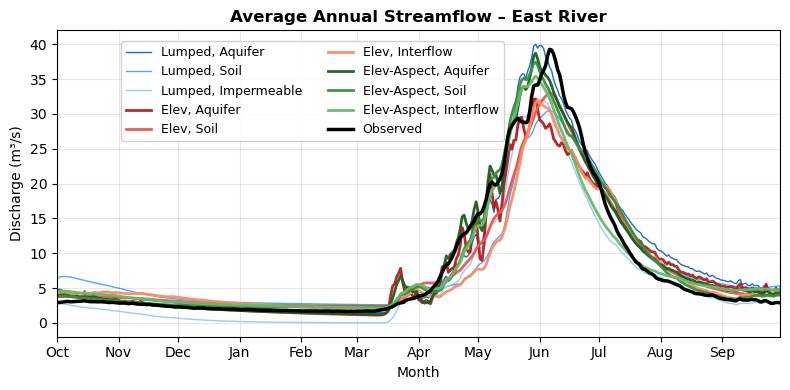

In [12]:
from matplotlib import dates as mdates
model_styles = {
    "lumped": {
        "bigBuckt":          {"color": "#1565C0", "ls": "-",  "label": "Lumped, Aquifer", "lw": 1},
        "noXplict_drainage": {"color": "#42A5F5", "ls": "-",  "label": "Lumped, Soil", "lw": 1},
        "noXplict_zeroFlux": {"color": "#90CAF9", "ls": "-",  "label": "Lumped, Impermeable", "lw": 1},
    },
    "distributed_elev": {
        "bigBuckt":          {"color": "#B71C1C", "ls": "-", "label": "Elev, Aquifer", "lw": 2},
        "noXplict_drainage": {"color": "#EF5350", "ls": "-", "label": "Elev, Soil", "lw": 2},
        "qTopmodl":          {"color": "#FF8A65", "ls": "-", "label": "Elev, Interflow", "lw": 2},
    },
    "distributed_elevAspect": {
        "bigBuckt":          {"color": "#1B5E20", "ls": "-",  "label": "Elev-Aspect, Aquifer", "lw": 2},
        "noXplict_drainage": {"color": "#388E3C", "ls": "-",  "label": "Elev-Aspect, Soil", "lw": 2},
        "qTopmodl":          {"color": "#66BB6A", "ls": "-",  "label": "Elev-Aspect, Interflow", "lw": 2},
    },
    "distributed_elevTPI": {
        "noXplict_drainage": {"color": "#4A148C", "ls": "-",  "label": "Elev-TPI, Aquifer", "lw": 2},
        "bigBuckt":          {"color": "#6A1B9A", "ls": "-",  "label": "Elev-TPI, Soil", "lw": 2},
        "qTopmodl":          {"color": "#AB47BC", "ls": "-",  "label": "Elev-TPI, Interflow", "lw": 2},
    }
}

# Reference water year (non-leap) for x-axis
ref_dates = pd.date_range("2000-10-01", "2001-09-30", freq="D")

def mean_annual_hydrograph(series):
    grouped = series.groupby([series.index.month, series.index.day]).mean()
    vals = [grouped.get((dt.month, dt.day), np.nan) for dt in ref_dates]
    return pd.Series(vals, index=ref_dates)

fig, ax = plt.subplots(1, 1, figsize=(8, 4))

for domain, domain_styles in model_styles.items():
    for model_key, style in domain_styles.items():
        if model_key not in model_discharge.get(domain, {}):
            continue
        q_mean = mean_annual_hydrograph(model_discharge[domain][model_key])
        if domain == "distributed_elevTPI":
            continue
        ax.plot(q_mean.index, q_mean.values,
                color=style["color"], linestyle=style["ls"],
                linewidth=style["lw"], label=style["label"], alpha=0.95)

obs_mean = mean_annual_hydrograph(obs_streamflow["value"])
ax.plot(obs_mean.index, obs_mean.values,
        color="black", linewidth=2.5, label="Observed", zorder=10)

ax.set_title("Average Annual Streamflow \u2013 East River", fontsize=12, fontweight="bold")
ax.set_ylabel("Discharge (m\u00b3/s)", fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_xlim(ref_dates[0], ref_dates[-1])
ax.grid(True, alpha=0.3)
ax.set_xlabel("Month", fontsize=10)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.15, 0.9),
           fontsize=9, framealpha=0.9, ncols=2)

plt.tight_layout()
# fig.savefig(f"/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_streamflow_mean_annual.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
def _area_weighted_series(da, hru_areas):
    if 'hru' in da.dims:
        df = da.to_pandas()
        return (df * hru_areas.values).sum(axis=1) / hru_areas.values.sum()
    return da.to_pandas()

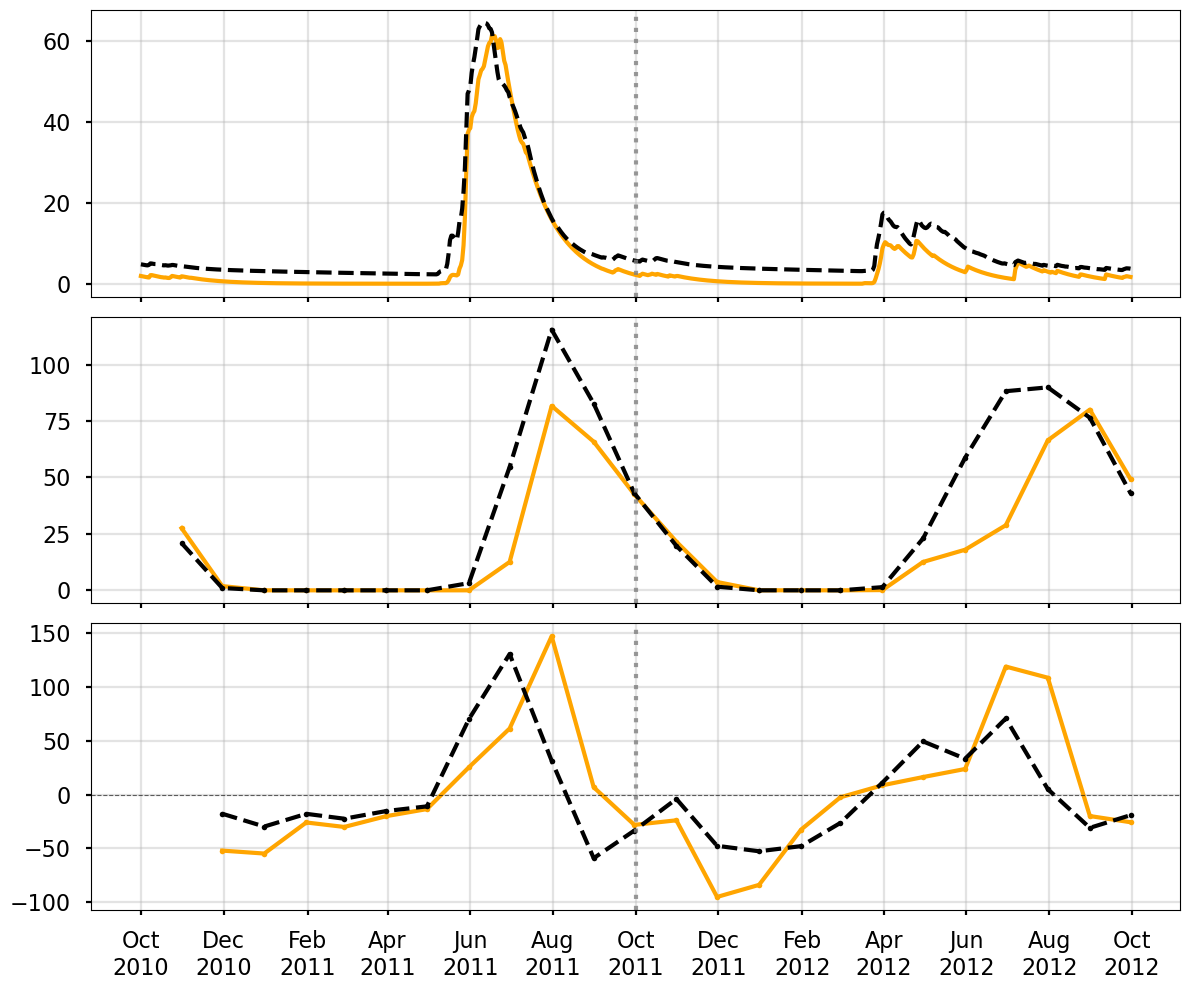

In [14]:
# ── WY2011 (wet) & WY2012 (dry) diagnostic: streamflow / ET / soil-moisture change ─
# Models: lumped/noXplict_zeroFlux  vs  distributed_elevAspect/qTopmodl

DIAG_MODELS = [
    ("lumped",                 "noXplict_zeroFlux",
     {'color': 'orange', 'ls': '-', 'label': 'Lumped, Impermeable', 'lw': 3}),
    ("distributed_elevAspect", "qTopmodl",
     {'color': 'k', 'ls': '--', 'label': 'Distributed, Elevation/Aspect', 'lw': 3}),
]

TWO_WY_START = "2010-10-01"
TWO_WY_END   = "2012-09-30"

plt.style.use("seaborn-v0_8-poster")
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
ax_q, ax_et, ax_ds = axes

# ── Panel 1: Daily streamflow (m³/s) ─────────────────────────────────────────
obs_2wy = obs_streamflow.loc[TWO_WY_START:TWO_WY_END, "value"]
# ax_q.plot(obs_2wy.index, obs_2wy.values, color="black", lw=1.2, label="Observed", zorder=5)

for dom, key, style in DIAG_MODELS:
    q_daily = model_discharge[dom][key].loc[TWO_WY_START:TWO_WY_END]
    ax_q.plot(q_daily.index, q_daily.values,
              color=style["color"], ls=style["ls"], lw=style["lw"], label=style["label"])

# ax_q.set_ylabel("Streamflow (m³/s)")

# ── Panel 2: Monthly Total ET (mm/month) ─────────────────────────────────────
for dom, key, style in DIAG_MODELS:
    filepath = model_files[dom][key]
    hru_areas = xr.open_dataset(attr_paths[dom])["HRUarea"].load()
    with xr.open_dataset(filepath) as ds:
        ds_sub = ds.sel(time=slice(TWO_WY_START, TWO_WY_END))
        # scalarTotalET: kg m-2 s-1, negative convention (outgoing flux)
        et_hr = _area_weighted_series(ds_sub["scalarTotalET"], hru_areas)
        et_mm_mo = -(et_hr * 3600).resample("ME").sum()        # mm/month, positive
    ax_et.plot(et_mm_mo.index, et_mm_mo.values,
               color=style["color"], ls=style["ls"], lw=style["lw"],
               label=style["label"], marker="o", ms=4)

# ax_et.set_ylabel("Total ET (mm / month)")

# ── Panel 3: Month-to-month soil-moisture change (mm/month) ──────────────────
for dom, key, style in DIAG_MODELS:
    filepath = model_files[dom][key]
    hru_areas = xr.open_dataset(attr_paths[dom])["HRUarea"].load()
    with xr.open_dataset(filepath) as ds:
        ds_sub = ds.sel(time=slice(TWO_WY_START, TWO_WY_END))
        # scalarTotalSoilLiq: kg m-2 (= mm); area-weighted spatial mean
        soil_mo = _area_weighted_series(ds_sub["scalarTotalSoilLiq"], hru_areas).resample("ME").mean()
    ds_soil = soil_mo.diff()
    ax_ds.plot(ds_soil.index, ds_soil.values,
               color=style["color"], ls=style["ls"], lw=style["lw"],
               label=style["label"], marker="o", ms=4)

ax_ds.axhline(0, color="k", lw=0.8, ls="--", alpha=0.6)
# ax_ds.set_ylabel("Soil Moisture Change\n(mm / month)")

# ── Shared formatting ────────────────────────────────────────────────────────
for ax in axes:
    ax.grid(True, alpha=0.35)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

# Water-year boundary line at Oct 2011
wy_div = pd.Timestamp("2011-10-01")
for ax in axes:
    ax.axvline(wy_div, color="gray", lw=3.0, ls=":", alpha=0.8)


plt.tight_layout()
# plt.savefig("../figures/fig_two_wy_diagnostic.png", dpi=150, bbox_inches="tight")
plt.show()


In [24]:
    # for domain, domain_styles in model_styles.items():
    #     for model_key, style in domain_styles.items():
    #         if model_key not in model_discharge.get(domain, {}):
    #             continue
    #         q_slice = model_discharge[domain][model_key].loc[period.start:period.stop].resample("7D").mean()
    #         if (period == WET_WY) & (domain == 'distributed_elevTPI'):
    #             shift = -3
    #         elif (period == DRY_WY):
    #             shift = 0
    #         else:
    #             shift = -1
    #         ax.plot(q_slice.index, q_slice.shift(shift).values,
    #                 color=style['color'], linestyle=style['ls'],
    #                 linewidth=2, label=style['label'], alpha=0.95)
    #         if (domain == 'distributed_elev') and (model_key == 'qTopmodl'):
    #             print(True)
    #             ax.plot([],[], label=" ", lw=0)

    # for domain, domain_styles in model_styles.items():
    #     for model_key, style in domain_styles.items():
    #         if model_key not in model_discharge.get(domain, {}):
    #             continue
    #         q_slice = model_discharge[domain][model_key].loc[period.start:period.stop].resample("1D").mean()
    #         multip=1
    #         if (period == WET_WY) & (domain == 'distributed_elevTPI'):
    #             shift = -24
    #         elif (period == DRY_WY):
    #             shift = 0
    #             multip=1.2
    #         else:
    #             shift = -8
    #         ax.plot(q_slice.index, q_slice.shift(shift).values,
    #                 color=style['color'], linestyle=style['ls'],
    #                 linewidth=style['lw'], label=style['label'], alpha=0.95)
    #         if (domain == 'distributed_elev') and (model_key == 'qTopmodl'):
    #             print(True)
    #             ax.plot([],[], label=" ", lw=0)

In [25]:
import datetime as dt
# runoff metrics
def nse(obs, sim):
    obs_mean = np.mean(obs)
    numerator = np.sum((obs - sim) ** 2)
    denominator = np.sum((obs - obs_mean) ** 2)
    return 1 - (numerator / denominator)
def kge(obs, sim):
    obs_mean = np.mean(obs)
    sim_mean = np.mean(sim)
    obs_std = np.std(obs)
    sim_std = np.std(sim)
    correlation = np.corrcoef(obs, sim)[0, 1]
    alpha = sim_std / obs_std
    beta = sim_mean / obs_mean
    kge_value = 1 - np.sqrt((correlation - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)
    return kge_value
def log_nse(obs, sim):
    obs_log = np.log(obs + 1e-6)
    sim_log = np.log(sim + 1e-6)
    return nse(obs_log, sim_log)
def com_difference(obs, sim):
    # calculate average center of mass timing difference between obs and sim
    com_differences = []
    for wy in obs.index.year.unique():
        if wy == 2000:
            continue
        time_slice = slice(f"{wy-1}-10-01", f"{wy}-09-30")
        obs_wy = obs.loc[time_slice].resample('W').sum()
        sim_wy = sim.loc[time_slice].resample('W').sum()
        if obs_wy.empty or sim_wy.empty or obs_wy.sum() == 0 or sim_wy.sum() == 0:
            continue
        # center of mass timing (weekly resolution)
        com_obs = obs_wy.cumsum() / obs_wy.sum()
        com_sim = sim_wy.cumsum() / sim_wy.sum()
        above_half_obs = com_obs[com_obs >= 0.5]
        above_half_sim = com_sim[com_sim >= 0.5]
        if above_half_obs.empty or above_half_sim.empty:
            continue
        half_mass_obs = above_half_obs.index[0]   # add 1 day to get the first day above 50%
        half_mass_sim = above_half_sim.index[0] 
        com_differences.append(dt.timedelta(days=(half_mass_sim - half_mass_obs).days))
    mean_com_diff = np.mean(com_differences[1:])
    # convert to pandas timestamp
    mean_com_diff = pd.to_timedelta(mean_com_diff).days
    return mean_com_diff
def volume_normalized_bias(obs, sim):
    volume_bias = np.sum(sim - obs) / np.sum(obs)
    return volume_bias
def jas_volumetric_bias(obs, sim):
    jas_mask = obs.index.month.isin([7, 8, 9])
    obs_jas = obs[jas_mask]
    sim_jas = sim[jas_mask]
    jas_bias = np.sum(sim_jas - obs_jas) / np.sum(obs_jas)  
    return jas_bias

In [26]:
# build table for each model type of these metrics for all years
metric_df = pd.DataFrame(columns=['Domain', 'Model', 'NSE', 'KGE', 'Log NSE', 'COM Difference', 'Volume-Percent Total Bias', 'JAS Volume-Percent Bias'])
count = 0
for domain, models in model_discharge.items():
    for model_key, sim in models.items():
        obs = obs_streamflow['value'].loc[sim.index]
        mask = ~obs.isna() & ~sim.isna()
        nse_val = nse(obs[mask], sim[mask])
        kge_val = kge(obs[mask], sim[mask])
        log_nse_val = log_nse(obs[mask], sim[mask])
        com_diff_val = com_difference(obs[mask].iloc[1:], sim[mask].iloc[1:])
        if domain == 'distributed_elevTPI':
            multip=5
        else: multip=1
        vnb = volume_normalized_bias(obs[mask], sim[mask])
        jas_bias = jas_volumetric_bias(obs[mask], sim[mask])

        tmp_df = pd.DataFrame({
            'Domain': [domain],
            'Model': [model_key],
            'NSE': [nse_val],
            'KGE': [kge_val],
            'Log NSE': [log_nse_val],
            'COM Difference': [int(com_diff_val/multip)],
            'Normalized Volume Bias': [vnb],
            'JAS Volume-Percent Bias': [jas_bias]
        })
        if count == 0:
            metric_df = tmp_df
            count += 1
        else:
            metric_df = pd.concat([metric_df, tmp_df], ignore_index=True)

In [27]:
# get volume percent bias for each year
yearly_bias_df = pd.DataFrame(columns=['Domain', 'Model', 'Year', 'Volume-Percent Total Bias'])
for domain, models in model_discharge.items():
    for model_key, sim in models.items():
        for wy in obs_streamflow.index.year.unique():
            if wy < 2001:
                continue
            time_slice = slice(f"{wy-1}-10-01", f"{wy}-09-30")
            obs_wy = obs_streamflow['value'].where(mask).loc[time_slice]
            sim_wy = sim.where(mask).loc[time_slice]
            if obs_wy.empty or sim_wy.empty:
                continue
            vptb = volume_normalized_bias(obs_wy, sim_wy)
            yearly_bias_df = pd.concat([yearly_bias_df, pd.DataFrame({
                'Domain': [domain],
                'Model': [model_key],
                'Year': [wy],
                'Normalized Volume Bias': [vptb],
            })], ignore_index=True)

In [59]:
# order by noXplict_zeroFlux, noXplict_drainage, bigBuckt, qTopmodl
yearly_bias_df = yearly_bias_df.sort_values(by=['Domain', 'Model'], key=lambda col: col.map({
    "noXplict_zeroFlux": 0,
    "noXplict_drainage": 1,
    "bigBuckt": 2,
    "qTopmodl": 3
}))

(-0.45, 0.45)

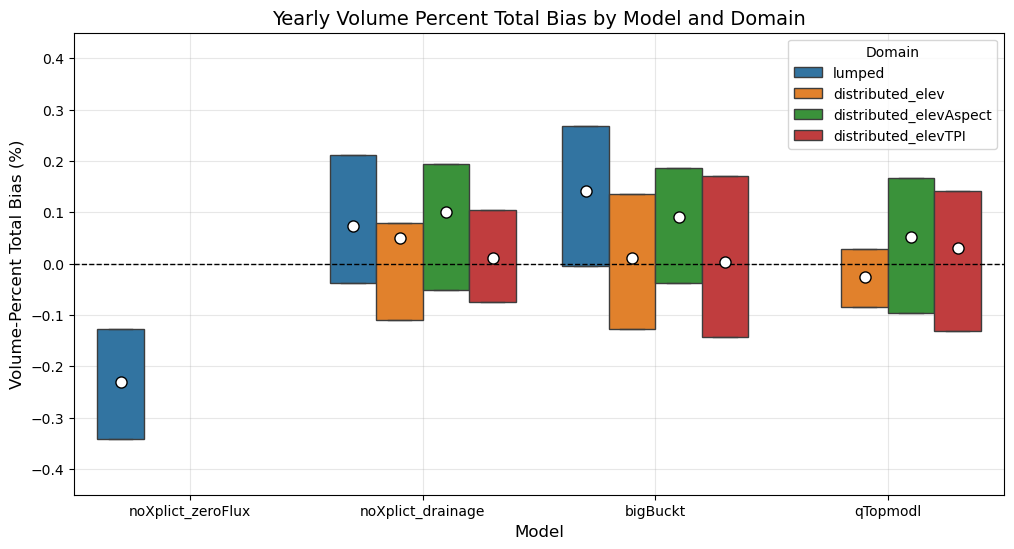

In [60]:
# plot boxplot of each models volume percent bias by year
plt.figure(figsize=(12, 6))
sns.boxplot(data=yearly_bias_df, 
            x='Model', 
            y='Normalized Volume Bias', 
            hue='Domain', showmeans=True,
            medianprops={'linewidth':0},
            meanprops={
                "marker": "o",          # Change shape (e.g., 'o' for circle, 's' for square)
                "markerfacecolor": "white", 
                "markeredgecolor": "black",
                "markersize": "8"
            },
            whis=0,
            showfliers=False,
            )
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title("Yearly Volume Percent Total Bias by Model and Domain", fontsize=14)
plt.ylabel("Volume-Percent Total Bias (%)", fontsize=12)
plt.xlabel("Model", fontsize=12)
plt.legend(title='Domain')
plt.grid(True, alpha=0.3)
plt.ylim(-0.45, 0.45)

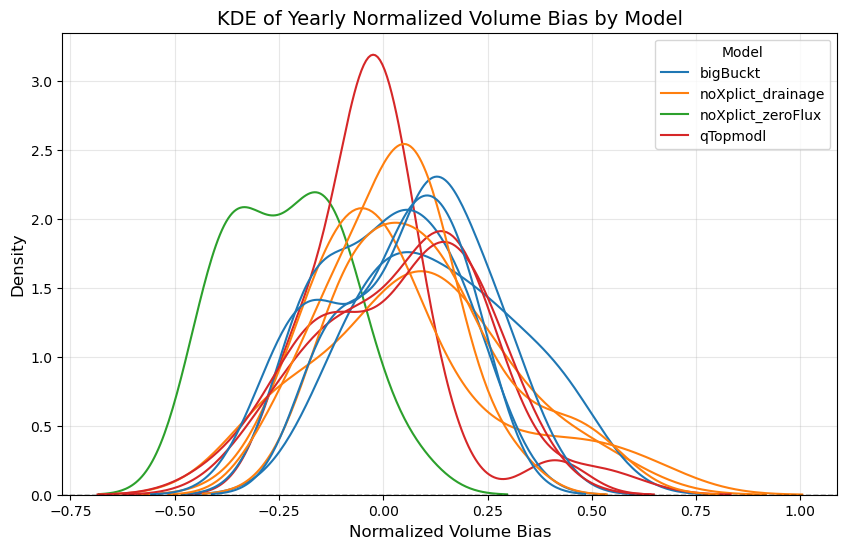

In [30]:
# create pdf of normal total flow bias, only show kde for all model types, make linestyle differentfor each domain
plt.figure(figsize=(10, 6))
for domain in yearly_bias_df['Domain'].unique():
    domain_data = yearly_bias_df[yearly_bias_df['Domain'] == domain]
    sns.kdeplot(data=domain_data, x='Normalized Volume Bias', hue='Model', fill=False, common_norm=False, alpha=1.0, linestyle='-',
                hue_order=['bigBuckt', 'noXplict_drainage', 'noXplict_zeroFlux', 'qTopmodl'])
plt.title("KDE of Yearly Normalized Volume Bias by Model", fontsize=14)
plt.xlabel("Normalized Volume Bias", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.show()

/tmp/ipykernel_1066770/1665595158.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


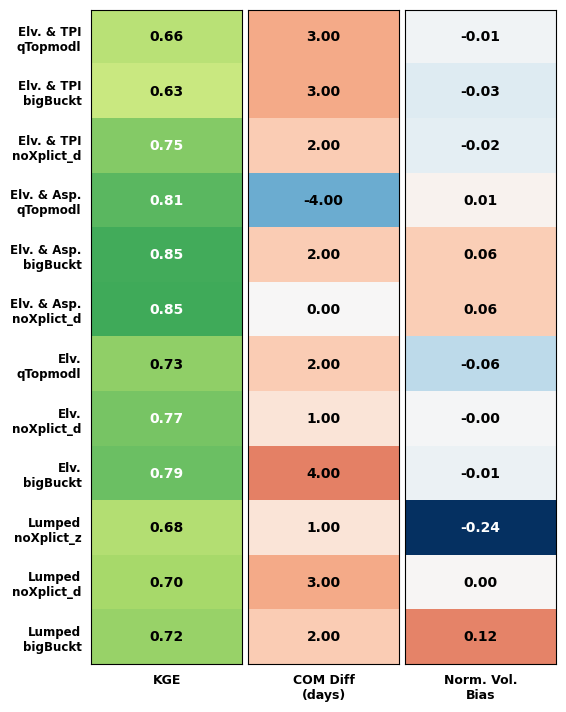

In [31]:
# --- Plot 1: per-column heatmap (visual table) ---
import matplotlib.colors as mcolors

domain_short = {
    'lumped': 'Lumped',
    'distributed_elev': 'Elv.',
    'distributed_elevAspect': 'Elv. & Asp.',
    'distributed_elevTPI': 'Elv. & TPI',
}
model_short = {
    'noXplict_zeroFlux': 'noXplict_z',
    'noXplict_drainage': 'noXplict_d',
    'bigBuckt': 'bigBuckt',
    'qTopmodl': 'qTopmodl',
}
row_labels = [
    f"{domain_short[d]}\n{model_short[m]}"
    for d, m in zip(metric_df['Domain'], metric_df['Model'])
]

metrics_hmap = [
    # ('NSE',                     'RdYlGn', False),
    ('KGE',                     'RdYlGn', False),
    ('COM Difference',          'RdBu_r',  True),
    ('Normalized Volume Bias',  'RdBu_r',  True),
]
col_display = ['KGE', 'COM Diff\n(days)', 'Norm. Vol.\nBias']

fig, axes = plt.subplots(1, 3, figsize=(6, 8.5), sharey=True,
                         gridspec_kw={'wspace': 0.04})

bias_vals = metric_df['Normalized Volume Bias'].values[::-1]

for ax, (col, cmap, diverging), xlabel in zip(axes, metrics_hmap, col_display):
    vals = metric_df[col].values[::-1]
    data = vals.reshape(-1, 1)

    if diverging:
        if col == 'COM Difference':
            offset = 4
        else: offset = 0.1
        absmax = max(abs(vals.min()), abs(vals.max())+offset, 1e-9)
        norm = mcolors.TwoSlopeNorm(vmin=-absmax, vcenter=0, vmax=absmax)
    else:
        norm = mcolors.Normalize(vmin=min(vals.min(), 0), vmax=1.0)

    im = ax.imshow(data, cmap=cmap, norm=norm, aspect='auto')

    for i, (v, b) in enumerate(zip(vals, bias_vals)):
        brightness = norm(v)
        txt_color = 'white' if (brightness < 0.25 or brightness > 0.75) else 'black'
        ax.text(0, i, f'{v:.2f}', ha='center', va='center',
                fontsize=10, color=txt_color, fontweight='bold')

    ax.set_xticks([0])
    ax.set_xticklabels([xlabel], rotation=0, ha='center', fontsize=9, fontweight='bold')
    ax.tick_params(left=False, bottom=False)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(ax.get_yticks(), fontweight='bold')

axes[0].set_yticklabels(row_labels[::-1], fontsize=8.5)
# for ax in axes[1:]:
#     ax.set_yticklabels([])

# fig.suptitle("Model Performance Metrics — East River", fontsize=12, y=0.95)
plt.tight_layout()
plt.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_metrics_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

[Text(0, 0.5, 'Elev-TPI'),
 Text(0, 1.5, 'Elev-Aspect'),
 Text(0, 2.5, 'Elev'),
 Text(0, 3.5, 'Lumped')]

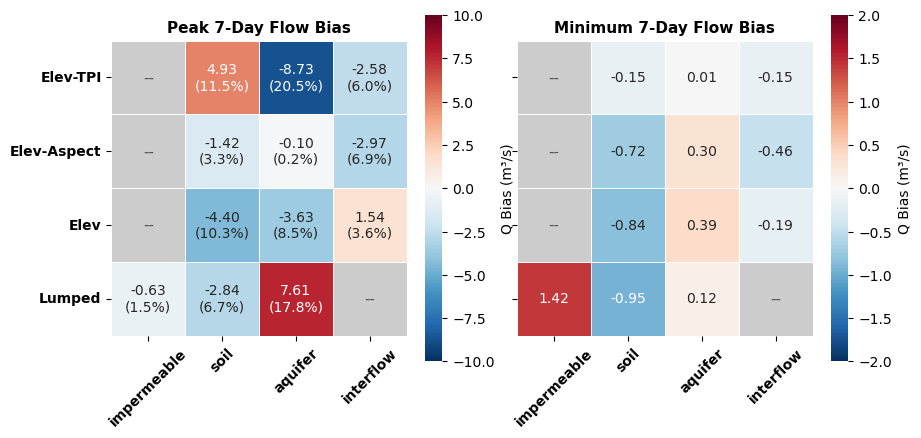

In [32]:
# --- Other performance metrics: peak 7D flow mean bias, minimum 7D flow mean bias, as a table with heatmap coloring ---
def peak_7d_bias(obs, sim):
    obs_7d = obs.rolling(window=10).mean()
    sim_7d = sim.rolling(window=7).mean()
    obs_peaks = obs_7d.groupby(obs_7d.index.year).max()
    sim_peaks = sim_7d.groupby(sim_7d.index.year).max()
    bias = np.mean((sim_peaks - obs_peaks))
    return bias
def min_7d_bias(obs, sim):
    obs_7d = obs.rolling(window=7).mean()
    sim_7d = sim.rolling(window=7).mean()
    obs_min = obs_7d.groupby(obs_7d.index.year).min()
    sim_min = sim_7d.groupby(sim_7d.index.year).min()
    bias = np.mean((obs_min - sim_min))
    return bias

peak_and_min = []
for idx, row in metric_df.iterrows():
    domain = row['Domain']
    model = row['Model']
    sim = model_discharge[domain][model]
    obs = obs_streamflow['value'].loc[sim.index]
    mask = ~obs.isna() & ~sim.isna()
    obs_m, sim_m = obs[mask], sim[mask]

    peak_7d = peak_7d_bias(obs_m, sim_m)
    min_7d = min_7d_bias(obs_m, sim_m)

    # Peak MPE — same windows as peak_7d_bias so peaks are identical
    obs_peaks = obs_m.rolling(window=10).mean().groupby(obs_m.index.year).max()
    sim_peaks = sim_m.rolling(window=7).mean().groupby(sim_m.index.year).max()
    mpe_peak = np.abs((peak_7d) / obs_peaks.mean()) * 100

    # Min MPE — same windows as min_7d_bias
    obs_mins = obs_m.rolling(window=7).mean().groupby(obs_m.index.year).min()
    sim_mins = sim_m.rolling(window=7).mean().groupby(sim_m.index.year).min()
    mpe_min = np.abs((min_7d) / obs_mins.mean()) * 100

    peak_and_min.append({'Domain': domain, 'Model': model,
                         'Peak 7D Bias': peak_7d, 'Min 7D Bias': min_7d,
                         'Peak 7D MPE': mpe_peak, 'Min 7D MPE': mpe_min})

peak_and_min_df = pd.DataFrame(peak_and_min)
peak_and_min_df = peak_and_min_df.sort_values(by=['Domain', 'Model'], key=lambda col: col.map({
    "noXplict_zeroFlux": 0,
    "noXplict_drainage": 1,
    "bigBuckt": 2,
    "qTopmodl": 3
}))

model_order = ['noXplict_zeroFlux', 'noXplict_drainage', 'bigBuckt', 'qTopmodl']
renames = ['impermeable', 'soil', 'aquifer', 'interflow']
domain_order = ['lumped', 'distributed_elev', 'distributed_elevAspect', 'distributed_elevTPI'][::-1]
domain_renames = ['Lumped', 'Elev', 'Elev-Aspect', 'Elev-TPI'][::-1]

def make_pivot(col):
    p = peak_and_min_df.pivot(index='Domain', columns='Model', values=col)
    p = p[model_order].loc[domain_order]
    p.index = domain_renames
    p.columns = renames
    return p

pivot_peak = make_pivot('Peak 7D Bias')
pivot_min  = make_pivot('Min 7D Bias')
pivot_peak_mpe = make_pivot('Peak 7D MPE')
pivot_min_mpe  = make_pivot('Min 7D MPE')

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True,
                         gridspec_kw={'wspace': 0.1})
nan_mask = pivot_peak.isna()

# Build string annotation arrays from pre-computed MPE pivots
annot_peak = pivot_peak.copy().astype(object)
annot_min  = pivot_min.copy().astype(object)
for i in range(pivot_peak.shape[0]):
    for j in range(pivot_peak.shape[1]):
        if not nan_mask.iloc[i, j]:
            annot_peak.iloc[i, j] = f"{pivot_peak.iloc[i, j]:.2f}\n({pivot_peak_mpe.iloc[i, j]:.1f}%)"
            annot_min.iloc[i, j]  = f"{pivot_min.iloc[i, j]:.2f}"#\n({pivot_min_mpe.iloc[i, j]:.1f}%)"
        else:
            annot_peak.iloc[i, j] = ''
            annot_min.iloc[i, j]  = ''

ax = axes[0]
sns.heatmap(
    pivot_peak,
    mask=nan_mask,
    annot=annot_peak,
    fmt='',
    cmap='RdBu_r',
    center=0,
    vmin=-10,
    vmax=10,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'label': 'Q Bias (m³/s)', "shrink": 0.75},
    ax=ax
)
ax.set_facecolor('#cccccc')
for i in range(pivot_peak.shape[0]):
    for j in range(pivot_peak.shape[1]):
        if nan_mask.iloc[i, j]:
            ax.text(j + 0.5, i + 0.5, '--', ha='center', va='center',
                    fontsize=11, color='#555555')

ax = axes[1]
sns.heatmap(
    pivot_min,
    mask=nan_mask,
    annot=annot_min,
    fmt='',
    cmap='RdBu_r',
    center=0,
    vmin=-2,
    vmax=2,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'label': 'Q Bias (m³/s)', "shrink": 0.75},
    ax=ax
)
ax.set_facecolor('#cccccc')
for i in range(pivot_min.shape[0]):
    for j in range(pivot_min.shape[1]):
        if nan_mask.iloc[i, j]:
            ax.text(j + 0.5, i + 0.5, '--', ha='center', va='center',
                    fontsize=11, color='#555555')

axes[0].set_title("Peak 7-Day Flow Bias", fontsize=11, fontweight='bold')
axes[1].set_title("Minimum 7-Day Flow Bias", fontsize=11, fontweight='bold')
axes[0].set_xticklabels(pivot_peak.columns, rotation=45, ha='center', fontsize=10, fontweight='bold')
axes[1].set_xticklabels(pivot_min.columns, rotation=45, ha='center', fontsize=10, fontweight='bold')
axes[0].set_yticklabels(pivot_peak.index, fontsize=10, fontweight='bold', rotation=0)

10 [ 0.63145493 -0.80027512]
11 [-0.64462556  0.45247589]
10 [ 0.90142239 -0.81357933]
11 [9.31343759e-01 8.00013089e-04]


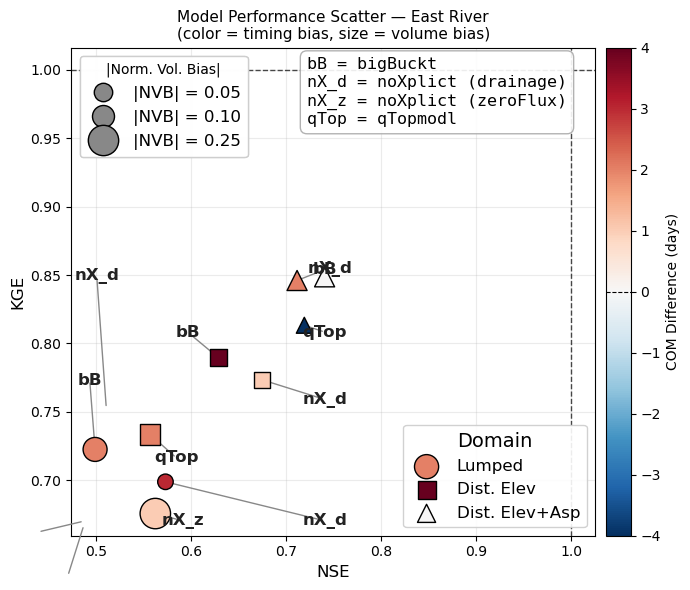

In [58]:

# --- Plot 2: performance scatter (Taylor-diagram-like) ---
from matplotlib.lines import Line2D
from adjustText import adjust_text

domain_markers = {
    'lumped':                 ('o', 'Lumped'),
    'distributed_elev':       ('s', 'Dist. Elev'),
    'distributed_elevAspect': ('^', 'Dist. Elev+Asp'),
}
model_abbrev = {
    'bigBuckt':          'bB',
    'noXplict_drainage': 'nX_d',
    'noXplict_zeroFlux': 'nX_z',
    'qTopmodl':          'qTop',
}
model_fullname = {
    'bB':    'bigBuckt',
    'nX_d':  'noXplict (drainage)',
    'nX_z':  'noXplict (zeroFlux)',
    'qTop':  'qTopmodl',
}

com  = metric_df['COM Difference'].values
nvb  = metric_df['Normalized Volume Bias'].values
nse_ = metric_df['NSE'].values
kge_ = metric_df['KGE'].values

absmax_com = max(abs(com.min()), abs(com.max()), 1)
com_norm   = mcolors.TwoSlopeNorm(vmin=-absmax_com, vcenter=0, vmax=absmax_com)
cmap_com   = plt.cm.RdBu_r

nvb_abs = np.abs(nvb)
sizes   = 120 + 360 * (nvb_abs / nvb_abs.max())

fig, ax = plt.subplots(figsize=(7, 6))

for domain, (marker, dlabel) in domain_markers.items():
    mask = (metric_df['Domain'] == domain).values
    ax.scatter(
        nse_[mask], kge_[mask],
        c=com[mask], cmap=cmap_com, norm=com_norm,
        s=sizes[mask], marker=marker,
        edgecolors='k', linewidths=1.0, zorder=5,
        label=dlabel,
    )

sm = plt.cm.ScalarMappable(cmap=cmap_com, norm=com_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.046)
cbar.set_label('COM Difference (days)', fontsize=10)
cbar.ax.axhline(0, color='k', lw=0.8, ls='--')

texts = []
for _, row in metric_df.iterrows():
    t = ax.annotate(
        model_abbrev[row['Model']],
        (row['NSE'], row['KGE']),
        fontsize=12, color='#222222', fontweight='bold',
        zorder=10,
    )
    texts.append(t)

adjust_text(
    texts, ax=ax, expand=(6.4, 6.7), ha='left', va='top',
    arrowprops=dict(arrowstyle='-', color='#888888', lw=1),
);

# domain legend (lower right)
domain_legend = ax.legend(title='Domain', fontsize=12, loc='lower right', framealpha=0.9, title_fontsize=14)
ax.add_artist(domain_legend);

# size legend for |NVB| (upper left)
nvb_refs  = [0.05, 0.10, 0.25]
size_refs = [100 + 360 * (v / nvb_abs.max()) for v in nvb_refs]
size_handles = [
    Line2D([0], [0], marker='o', linestyle='None',
           color='w', markerfacecolor='#888888', markeredgecolor='k',
           markersize=np.sqrt(s), label=f'|NVB| = {v:.2f}')
    for v, s in zip(nvb_refs, size_refs)
]
size_legend = ax.legend(handles=size_handles, title='|Norm. Vol. Bias|',
                        fontsize=12, loc='upper left', framealpha=0.9)
ax.add_artist(size_legend)

# model abbreviation key (upper right, plain text box)
abbrev_lines = '\n'.join(f'{k} = {v}' for k, v in model_fullname.items())
ax.text(
    0.45, 0.98, abbrev_lines,
    transform=ax.transAxes,
    fontsize=12, va='top', ha='left', family='monospace',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#aaaaaa', alpha=0.9),
)

ax.axhline(1, color='k', ls='--', lw=1.0, alpha=0.7)
ax.axvline(1, color='k', ls='--', lw=1.0, alpha=0.7)
ax.set_xlabel('NSE', fontsize=12)
ax.set_ylabel('KGE', fontsize=12)
ax.set_title('Model Performance Scatter — East River\n'
             '(color = timing bias, size = volume bias)', fontsize=11)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_metrics_scatter.png',
            dpi=150, bbox_inches='tight')
plt.show()


## SWE - Q regression scatter

In [34]:
# get snotel data
snotel_df = pd.read_csv(DATA_DIR / f"domain_{DOMAIN}_distributed" / "observations" / "formatted" / "snotel_swe.csv", parse_dates=['date'], index_col='date')
snotel_apr1_swe = snotel_df[(snotel_df.index.month == 4) & (snotel_df.index.day == 1)]
snotel_apr1_swe.index = snotel_apr1_swe.index.year
annual_q = obs_streamflow.resample('AS-OCT').sum()  # Annual runoff (Oct 1 - Sep 30)
annual_q.index = annual_q.index.year+1
# SWE-Q runoff regression
swe_q_df = pd.DataFrame({
    'apr1_swe': snotel_apr1_swe['value'],
    'annual_q': annual_q['value']
})



/tmp/ipykernel_1066770/2094612696.py:5: FutureWarning: 'AS-OCT' is deprecated and will be removed in a future version, please use 'YS-OCT' instead.
  annual_q = obs_streamflow.resample('AS-OCT').sum()  # Annual runoff (Oct 1 - Sep 30)


In [35]:
# get mean, daily scalarSWE from each model
swe_daily_dict = {}
for domain, models in model_discharge.items():
    # hru area
    
    for model_key, sim in models.items():
        filepath = model_files[domain][model_key]
        hru_area = xr.open_dataset(attr_paths[domain])['HRUarea']
        ds = xr.open_dataset(filepath)
        if 'scalarSWE' in ds.data_vars:
            swe_var = (ds['scalarSWE']*hru_area).sum(dim='hru')/area_m2
            # for each year, get 1 Apr SWE
            swe_apr1 = []
            wys = []
            for wy in sim.index.year.unique():
                if (wy < 2001) or (wy > 2021):
                    continue
                wys.append(wy)
                time_slice = slice(f"{wy-1}-10-01", f"{wy}-09-30")
                swe_wy = swe_var.sel(time=time_slice)
                # get 1 Apr value
                apr1 = pd.Timestamp(f"{wy}-04-01")
                if apr1 in swe_wy.time.values:
                    swe_apr1.append(float(swe_wy.sel(time=apr1).values))
                else:
                    # if no exact match, interpolate
                    swe_apr1.append(float(swe_wy.interp(time=apr1).values))
            swe_daily_dict[(domain, model_key)] = pd.DataFrame({
                'apr1_swe': swe_apr1,
            }, index=wys)



In [36]:
# calculate water year annual q for each model
annual_q_dict = {}
for domain, models in model_discharge.items():
    for model_key, sim in models.items():
        wy_q = []
        wys = []
        for wy in sim.index.year.unique():
            if (wy < 2001) or (wy > 2021):
                continue
            time_slice = slice(f"{wy-1}-10-01", f"{wy}-09-30")
            sim_wy = sim.loc[time_slice]
            annual_q = sim_wy.sum()
            wy_q.append(annual_q)
            wys.append(wy)

        annual_q_dict[(domain, model_key)] = pd.DataFrame({
            'annual_q': wy_q,
        }, index=wys)

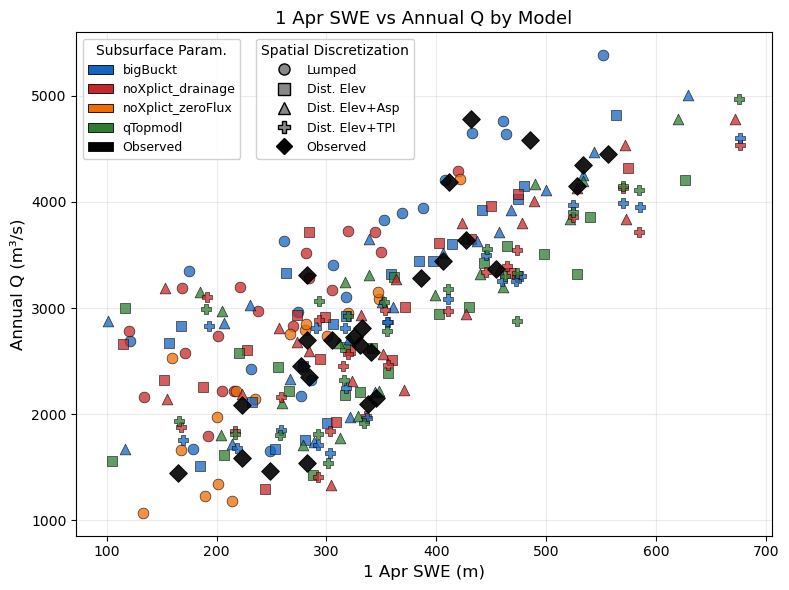

In [37]:
# scatter plot of 1 Apr SWE vs annual Q — color = model type, shape = domain
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

model_colors = {
    'bigBuckt':          '#1565C0',
    'noXplict_drainage': '#C62828',
    'noXplict_zeroFlux': '#EF6C00',
    'qTopmodl':          '#2E7D32',
}
domain_markers = {
    'lumped':                 'o',
    'distributed_elev':       's',
    'distributed_elevAspect': '^',
    'distributed_elevTPI':    'P',
}
domain_labels = {
    'lumped':                 'Lumped',
    'distributed_elev':       'Dist. Elev',
    'distributed_elevAspect': 'Dist. Elev+Asp',
    'distributed_elevTPI':    'Dist. Elev+TPI',
}

fig, ax = plt.subplots(figsize=(8, 6))

for (domain, model_key), swe_df in swe_daily_dict.items():
    annual_q = annual_q_dict[(domain, model_key)]
    merged_df = swe_df.merge(annual_q, left_index=True, right_index=True)
    merged_df = merged_df[merged_df['apr1_swe']>100]
    ax.scatter(
        merged_df['apr1_swe'], merged_df['annual_q'],
        color=model_colors[model_key],
        marker=domain_markers[domain],
        alpha=0.75, edgecolors='k', linewidths=0.5, s=60, zorder=4,
    )

# observed
ax.scatter(
    swe_q_df['apr1_swe'], swe_q_df['annual_q'],
    color='black', marker='D', s=80, edgecolors='k', linewidths=0.8,
    alpha=0.9, zorder=5,
)

# color legend — model type (upper left)
model_keys_present = {mk for _, mk in swe_daily_dict.keys()}
color_handles = [
    Patch(facecolor=c, edgecolor='k', linewidth=0.6, label=m)
    for m, c in model_colors.items() if m in model_keys_present
]
color_handles.append(Patch(facecolor='black', edgecolor='k', linewidth=0.6, label='Observed'))
color_legend = ax.legend(handles=color_handles, title='Subsurface Param.',
                         fontsize=9, loc='upper left', framealpha=0.9)
ax.add_artist(color_legend)

# shape legend — domain (lower right)
domains_present = {d for d, _ in swe_daily_dict.keys()}
shape_handles = [
    Line2D([0], [0], marker=m, linestyle='None', color='w',
           markerfacecolor='#888888', markeredgecolor='k',
           markersize=8, label=domain_labels[d])
    for d, m in domain_markers.items() if d in domains_present
]
shape_handles.append(
    Line2D([0], [0], marker='D', linestyle='None', color='w',
           markerfacecolor='black', markeredgecolor='k',
           markersize=8, label='Observed')
)
ax.legend(handles=shape_handles, title='Spatial Discretization', fontsize=9,
          loc='upper left', framealpha=0.9, bbox_to_anchor=(0.25, 1))

ax.set_xlabel('1 Apr SWE (m)', fontsize=12)
ax.set_ylabel('Annual Q (m³/s)', fontsize=12)
ax.set_title('1 Apr SWE vs Annual Q by Model', fontsize=13)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## SWE-Q regression diagnostrics across model types. 

In [65]:
# # SWE-Q regression diagnostic scatter
# # x = Pearson r, y = slope (sensitivity), color = R²
# # shape = domain, observed shown as black diamond

# reg_df = pd.DataFrame(regression_results)
# reg_df['r'] = np.sqrt(reg_df['R²'])   # r = sqrt(R²) for positive-slope OLS

# domain_markers_reg = {
    
#     'lumped':                 'o',
#     'distributed_elev':       's',
#     'distributed_elevAspect': '^',
#     'distributed_elevTPI':    'P',
#     'Observed':               'D',
# }
# domain_labels_reg = {
#     'lumped':                 'Lumped',
#     'distributed_elev':       'Dist. Elev',
#     'distributed_elevAspect': 'Dist. Elev+Asp',
#     'distributed_elevTPI':    'Dist. Elev+TPI',
#     'Observed':               'Observed',
# }
# model_abbrev_reg = {
#     'bigBuckt':          'bB',
#     'noXplict_drainage': 'nX_d',
#     'noXplict_zeroFlux': 'nX_z',
#     'qTopmodl':          'qTop',
#     'Observed':          'Obs',
# }

# r2_vals    = reg_df['R²'].values
# slope_vals = reg_df['Slope'].values
# r2_norm    = mcolors.Normalize(vmin=0, vmax=1)
# cmap_r2    = plt.cm.YlOrRd

# fig, ax = plt.subplots(figsize=(7, 6))

# # model points
# for _, row in reg_df[reg_df['Domain'] != 'Observed'].iterrows():
#     ax.scatter(
#         row['r'], row['Slope'],
#         c=[cmap_r2(r2_norm(row['R²']))],
#         marker=domain_markers_reg[row['Domain']],
#         s=100, edgecolors='k', linewidths=0.8, zorder=5,
#     )

# # observed — always black diamond, still colored by R²
# obs_row = reg_df[reg_df['Domain'] == 'Observed'].iloc[0]
# ax.scatter(
#     obs_row['r'], obs_row['Slope'],
#     c=[cmap_r2(r2_norm(obs_row['R²']))],
#     marker='D', s=130, edgecolors='k', linewidths=1.5, zorder=6,
# )

# # colorbar for R²
# sm = plt.cm.ScalarMappable(cmap=cmap_r2, norm=r2_norm)
# sm.set_array([])
# cbar = fig.colorbar(sm, ax=ax, pad=0.02, fraction=0.046)
# cbar.set_label('R²', fontsize=11)

# # labels
# texts = []
# for _, row in reg_df.iterrows():
#     t = ax.annotate(
#         model_abbrev_reg.get(row['Model'], row['Model']),
#         (row['r'], row['Slope']),
#         fontsize=8.5, fontweight='bold', color='#222222', zorder=10,
#     )
#     texts.append(t)
# adjust_text(texts, ax=ax, expand=(1.4, 1.6),
#             arrowprops=dict(arrowstyle='-', color='#888888', lw=0.7))

# # observed reference lines
# ax.axhline(obs_row['Slope'], color='k', ls='--', lw=0.8, alpha=0.5, label='_')
# ax.axvline(obs_row['r'],     color='k', ls='--', lw=0.8, alpha=0.5, label='_')

# # shape legend
# domains_in_reg = set(reg_df['Domain'].unique())
# shape_handles = [
#     Line2D([0],[0], marker=domain_markers_reg[d], linestyle='None', color='w',
#            markerfacecolor='#888888', markeredgecolor='k',
#            markersize=8, label=domain_labels_reg[d])
#     for d in domain_markers_reg if d in domains_in_reg
# ]
# ax.legend(handles=shape_handles, title='Domain', fontsize=9,
#           loc='lower right', framealpha=0.9)

# ax.set_xlabel('Pearson r  (SWE–Q correlation)', fontsize=11)
# ax.set_ylabel('Slope  (m³/s per m SWE)', fontsize=11)
# # ax.set_title('SWE–Q Regression by Model', color = R², dashed lines = observed reference)', fontsize=11)
# ax.grid(True, alpha=0.25)
# plt.tight_layout()
# # plt.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_sweQ_regression_scatter.png',
# #             dpi=150, bbox_inches='tight')
# plt.show()

## Observed v. Modeled streamflow with model spread

In [49]:
# build apr1 SWE observed regression
from sklearn.linear_model import LinearRegression
obs_swe_q = swe_q_df.dropna(subset=['apr1_swe', 'annual_q']).loc["2000-01-01":"2010-01-01"]
X_obs = obs_swe_q['apr1_swe'].values.reshape(-1, 1)
y_obs = obs_swe_q['annual_q'].values
obs_reg = LinearRegression().fit(X_obs, y_obs)
print("Observed SWE-Q Regression:")
print(f"  Slope: {obs_reg.coef_[0]:.4f}")
print(f"  Intercept: {obs_reg.intercept_:.2f}")
print(f"  R²: {obs_reg.score(X_obs, y_obs):.4f}")

Observed SWE-Q Regression:
  Slope: 7.8196
  Intercept: 115.92
  R²: 0.8737


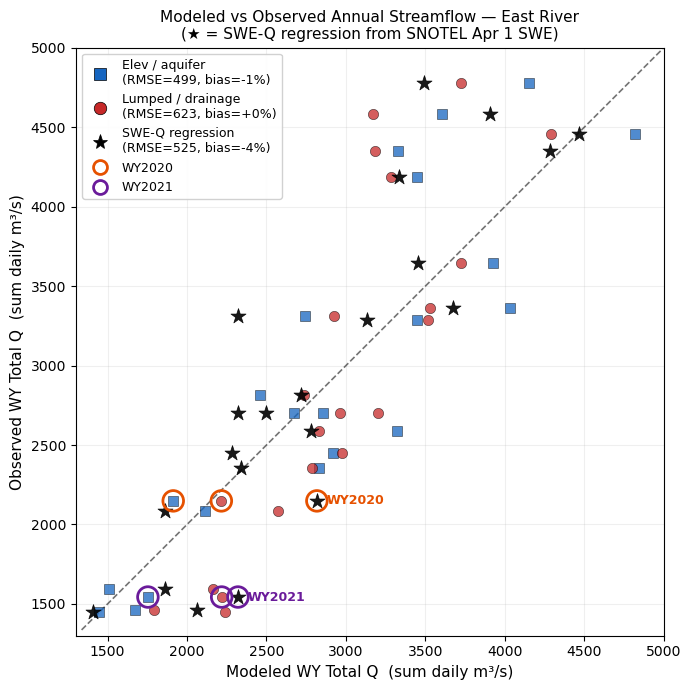

In [ ]:
# Scatter: modeled (x) vs observed (y) annual Q — specific (domain, model) combinations
from matplotlib.lines import Line2D

# Each tuple: (domain, model_key, show_metric)
COMBOS = [
    # ('distributed_elevAspect', 'bigBuckt',         True),
    ('distributed_elev',       'bigBuckt',          True),
    # ('distributed_elevAspect',       'qTopmodl',          True),
    # ('lumped',                 'bigBuckt',           True),
    ('lumped',                 'noXplict_drainage',  True),
]
combo_labels = {
    ('distributed_elevAspect', 'bigBuckt'):         'Elev+Asp / aquifer',
    ('distributed_elev',       'bigBuckt'):          'Elev / aquifer',
    ('distributed_elevAspect',       'qTopmodl'):          'Elev+Asp / interflow',
    ('lumped',                 'bigBuckt'):           'Lumped / aquifer',
    ('lumped',                 'noXplict_drainage'): 'Lumped / drainage',
}
HIGHLIGHT_WYS = {2020: '#E65100', 2021: '#6A1B9A'}   # deep-orange, deep-purple

# Observed WY totals
obs_wy_totals = {}
for wy in range(2001, 2022):
    obs_wy = obs_streamflow['value'].loc[f"{wy-1}-10-01":f"{wy}-09-30"].dropna()
    if not obs_wy.empty:
        obs_wy_totals[wy] = obs_wy.sum()
obs_wy_series = pd.Series(obs_wy_totals)

fig, ax = plt.subplots(figsize=(8, 7))
legend_handles = []
all_x, all_y = [], []
highlight_pts = {wy: [] for wy in HIGHLIGHT_WYS}   # list of (x, y)

for domain, model_key, show_metric in COMBOS:
    if (domain, model_key) not in annual_q_dict:
        continue
    sim_df = annual_q_dict[(domain, model_key)]
    xs, ys = [], []
    for wy, obs_q in obs_wy_series.items():
        if wy not in sim_df.index:
            continue
        sim_q = sim_df.loc[wy, 'annual_q']
        xs.append(sim_q)
        ys.append(obs_q)
        if wy in highlight_pts:
            highlight_pts[wy].append((sim_q, obs_q))
    ax.scatter(xs, ys,
               color=model_colors[model_key], marker=domain_markers[domain],
               alpha=0.75, edgecolors='k', linewidths=0.4, s=55, zorder=4)
    all_x += xs
    all_y += ys
    label = combo_labels[(domain, model_key)]
    if show_metric and len(xs) > 1:
        rmse = np.sqrt(np.mean((np.array(xs) - np.array(ys)) ** 2))
        pbias = 100 * np.sum(np.array(xs) - np.array(ys)) / np.sum(np.array(ys))
        label += f' \n(RMSE={rmse:.0f}, bias={pbias:+.0f}%)'
    legend_handles.append(
        Line2D([0], [0], marker=domain_markers[domain], color='w',
               markerfacecolor=model_colors[model_key], markersize=9,
               markeredgecolor='k', markeredgewidth=0.5, label=label)
    )

# SWE-Q regression projection: x = SWE-predicted Q, y = observed Q
swe_obs_apr1 = snotel_apr1_swe['value']
swe_pred_q, obs_q_for_swe = [], []
for wy, obs_q in obs_wy_series.items():
    if wy in swe_obs_apr1.index and not np.isnan(swe_obs_apr1[wy]):
        pred_q = obs_reg.coef_[0] * swe_obs_apr1[wy] + obs_reg.intercept_  # using observed regression slope but model intercept
        swe_pred_q.append(pred_q)
        obs_q_for_swe.append(obs_q)
        if wy in highlight_pts:
            highlight_pts[wy].append((pred_q, obs_q))

swe_rmse  = np.sqrt(np.mean((np.array(swe_pred_q) - np.array(obs_q_for_swe)) ** 2))
swe_pbias = 100 * np.sum(np.array(swe_pred_q) - np.array(obs_q_for_swe)) / np.sum(np.array(obs_q_for_swe))
ax.scatter(swe_pred_q, obs_q_for_swe,
           color='black', marker='*', s=130, edgecolors='k', linewidths=0.5,
           alpha=0.9, zorder=5)
legend_handles.append(
    Line2D([0], [0], marker='*', color='w', markerfacecolor='black',
           markersize=11, markeredgecolor='k', markeredgewidth=0.5,
           label=f'SWE-Q regression \n(RMSE={swe_rmse:.0f}, bias={swe_pbias:+.0f}%)')
)
all_x += swe_pred_q
all_y += obs_q_for_swe

# ── Highlight WY2020 and WY2021 ───────────────────────────────────────────
for wy, color in HIGHLIGHT_WYS.items():
    pts = highlight_pts[wy]
    if not pts:
        continue
    hx = [p[0] for p in pts]
    hy = [p[1] for p in pts]
    ax.scatter(hx, hy, s=220, facecolors='none', edgecolors=color,
               linewidths=2.0, zorder=6)
    # label at right-most x so it doesn't overlap the cluster
    ax.annotate(f'WY{wy}', xy=(max(hx), hy[0]),
                xytext=(7, 0), textcoords='offset points',
                fontsize=9, fontweight='bold', color=color,
                va='center', zorder=7)
    legend_handles.append(
        Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
               markersize=10, markeredgecolor=color, markeredgewidth=2.0,
               label=f'WY{wy}')
    )

# 1:1 line
lim_lo = min(min(all_x), min(all_y)) * 0.95
lim_hi = max(max(all_x), max(all_y)) * 1.05
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=1.2, alpha=0.55, zorder=2)
ax.set_xlim(1300, 5000)
ax.set_ylim(1300, 5000)
ax.set_aspect('equal')

ax.legend(handles=legend_handles, fontsize=9, loc='upper left', framealpha=0.9)
ax.set_xlabel('Modeled WY Total Q  (sum daily m³/s)', fontsize=11)
ax.set_ylabel('Observed WY Total Q  (sum daily m³/s)', fontsize=11)
ax.set_title('Modeled vs Observed Annual Streamflow — East River\n'
             '(★ = SWE-Q regression from SNOTEL Apr 1 SWE)',
             fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


High  (5):    [2008, 2011, 2014, 2017, 2019]
Middle (11): [2001, 2003, 2004, 2005, 2006, 2007, 2009, 2010, 2015, 2016, 2020]
Low   (5):    [2002, 2012, 2013, 2018, 2021]


,High,Middle,Low
Model,,,
Elev / aquifer,-13.4,5.6,4.6
Lumped / drainage,-21.0,6.5,35.2
SWE-Q regression,-12.8,-3.3,17.1


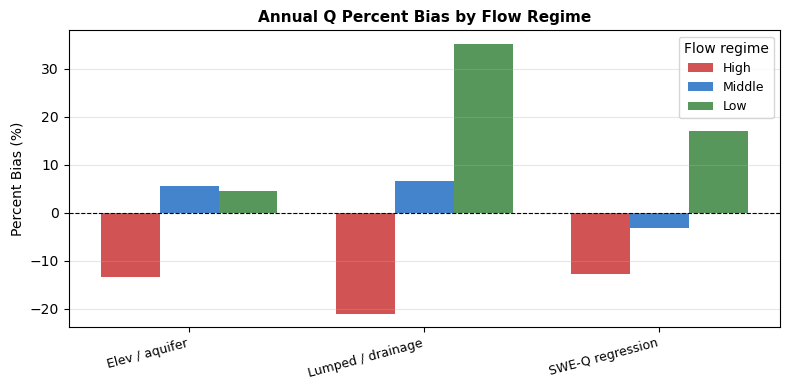

In [62]:
# --- Percent bias by flow regime (annual Q totals) ---
N_high, N_low = 5, 5

ranked   = obs_wy_series.rank(ascending=True)
n        = len(ranked)
high_wys = set(ranked[ranked > (n - N_high)].index.astype(int))
low_wys  = set(ranked[ranked <= N_low].index.astype(int))
mid_wys  = set(ranked.index.astype(int)) - high_wys - low_wys

print(f"High  ({N_high}):    {sorted(high_wys)}")
print(f"Middle ({len(mid_wys)}): {sorted(mid_wys)}")
print(f"Low   ({N_low}):    {sorted(low_wys)}")

def group_pbias(sim_by_wy, obs_series, wy_set):
    wys = [wy for wy in wy_set if wy in sim_by_wy and wy in obs_series.index]
    if not wys:
        return np.nan
    sim_vals = np.array([sim_by_wy[wy] for wy in wys])
    obs_vals = obs_series[wys].values
    return 100 * np.sum(sim_vals - obs_vals) / np.sum(obs_vals)

rows = []

for domain, model_key, _ in COMBOS:
    if (domain, model_key) not in annual_q_dict:
        continue
    sim_by_wy = annual_q_dict[(domain, model_key)]['annual_q'].to_dict()
    label = combo_labels[(domain, model_key)]
    rows.append({'Model': label,
                 'High':   group_pbias(sim_by_wy, obs_wy_series, high_wys),
                 'Middle': group_pbias(sim_by_wy, obs_wy_series, mid_wys),
                 'Low':    group_pbias(sim_by_wy, obs_wy_series, low_wys)})

# SWE-Q regression
swe_sim_by_wy = {
    wy: obs_reg.coef_[0] * swe_obs_apr1[wy] + obs_reg.intercept_
    for wy, obs_q in obs_wy_series.items()
    if wy in swe_obs_apr1.index and not np.isnan(swe_obs_apr1[wy])
}
rows.append({'Model': 'SWE-Q regression',
             'High':   group_pbias(swe_sim_by_wy, obs_wy_series, high_wys),
             'Middle': group_pbias(swe_sim_by_wy, obs_wy_series, mid_wys),
             'Low':    group_pbias(swe_sim_by_wy, obs_wy_series, low_wys)})

pbias_df = pd.DataFrame(rows).set_index('Model')
display(pbias_df.round(1))

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(pbias_df))
w = 0.25
colors = {'High': '#C62828', 'Middle': '#1565C0', 'Low': '#2E7D32'}
for i, (grp, color) in enumerate(colors.items()):
    ax.bar(x + (i - 1) * w, pbias_df[grp], w, label=grp, color=color, alpha=0.8)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(pbias_df.index, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Percent Bias (%)', fontsize=10)
ax.set_title('Annual Q Percent Bias by Flow Regime', fontsize=11, fontweight='bold')
ax.legend(title='Flow regime', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Observed v. Modeled SWE with model spread

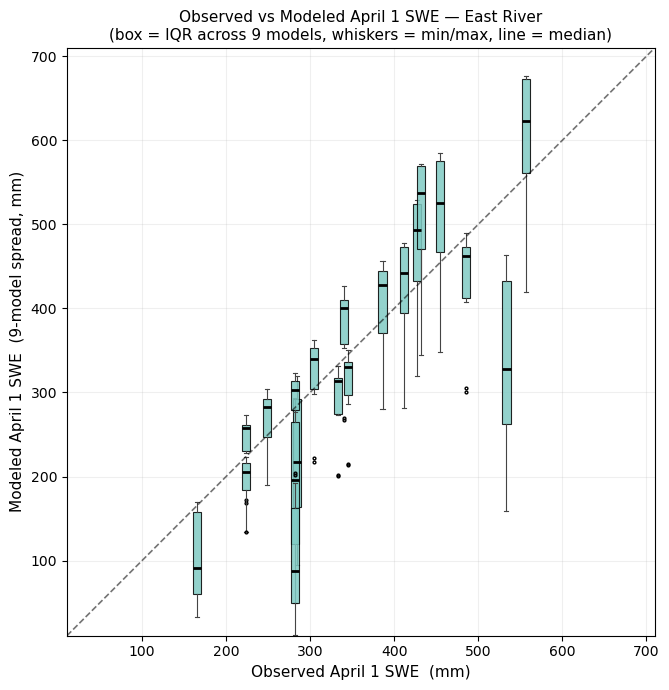

In [63]:
# Boxplot: April 1 SWE observed vs modeled (9-model spread per year)
# observed = SNOTEL (mm), modeled scalarSWE converted m→mm
# years with observed Apr1 SWE < 100 mm excluded

obs_apr1 = snotel_apr1_swe['value'].copy()   # mm, indexed by year
obs_apr1 = obs_apr1[obs_apr1 >= 100]

box_positions, box_data, box_years = [], [], []
for wy, obs_swe in sorted(obs_apr1.items()):
    if wy < 2002 or wy > 2021:
        continue
    model_vals = [
        swe_df.loc[wy, 'apr1_swe']   # m → mm
        for (_, _), swe_df in swe_daily_dict.items()
        if wy in swe_df.index
    ]
    if model_vals:
        box_positions.append(obs_swe)
        box_data.append(model_vals)
        box_years.append(wy)

q_range   = max(box_positions) - min(box_positions)
box_width = q_range * 0.025

fig, ax = plt.subplots(figsize=(8, 7))

bp = ax.boxplot(
    box_data,
    positions=box_positions,
    widths=box_width,
    patch_artist=True,
    vert=True,
    manage_ticks=False,
    medianprops=dict(color='black',    linewidth=2.0),
    boxprops=dict(facecolor='#80CBC4', alpha=0.85, linewidth=0.8),
    whiskerprops=dict(linewidth=0.8,   color='#444'),
    capprops=dict(linewidth=0.8,       color='#444'),
    flierprops=dict(marker='.', markersize=4, color='#666'),
)

all_sim_flat = np.concatenate(box_data)
lim_lo = min(min(box_positions), all_sim_flat.min()) * 0.9
lim_hi = max(max(box_positions), all_sim_flat.max()) * 1.05
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=1.2, alpha=0.55, zorder=2)
ax.set_xlim(lim_lo, lim_hi)
ax.set_ylim(lim_lo, lim_hi)
ax.set_aspect('equal')

ax.set_xlabel('Observed April 1 SWE  (mm)', fontsize=11)
ax.set_ylabel('Modeled April 1 SWE  (9-model spread, mm)', fontsize=11)
ax.set_title('Observed vs Modeled April 1 SWE — East River\n'
             '(box = IQR across 9 models, whiskers = min/max, line = median)',
             fontsize=11)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_obs_vs_sim_apr1SWE_boxplot.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Runoff ratio boxplots

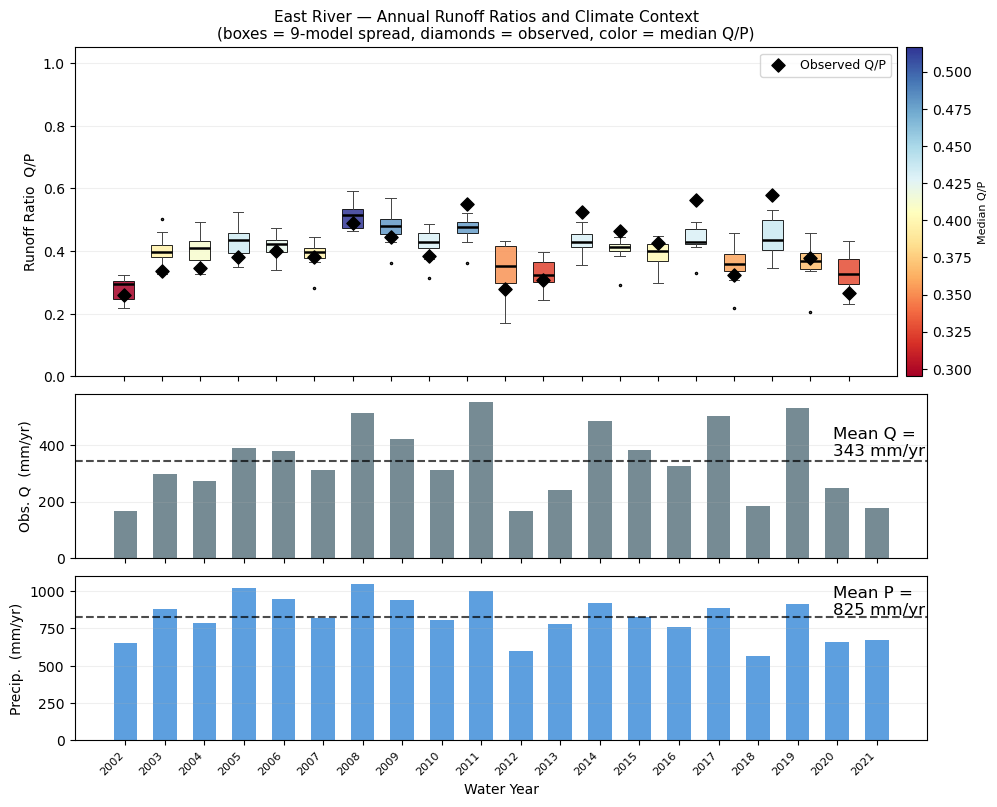

In [64]:
# Runoff ratio (Q/P) by water year
# Q converted to depth (mm/yr), P from pptrate (kg m-2 s-1 -> mm/yr)
# Three panels: Q/P boxplot (models) | observed Q | annual P
# Boxes colored by median Q/P value

import matplotlib.colors as mcolors
import matplotlib.cm as cm

# --- Precipitation: use pptrate from lumped bigBuckt output (same ERA5 for all) ---
ds_p = xr.open_dataset(model_files['lumped']['bigBuckt'])
area_lump = domain_areas['lumped']
p_rate = ds_p['pptrate'].squeeze()                        # kg m-2 s-1
p_daily = (p_rate * 86400).resample(time='1D').mean()    # mm/day

precip_wy = {}
for wy in range(2002, 2022):
    p_wy = p_daily.sel(time=slice(f"{wy-1}-10-01", f"{wy}-09-30"))
    if len(p_wy) > 0:
        precip_wy[wy] = float(p_wy.sum())
precip_series = pd.Series(precip_wy)

# --- Observed Q in depth (mm/yr) ---
obs_q_mm = {}
for wy in range(2002, 2022):
    obs_wy = obs_streamflow['value'].loc[f"{wy-1}-10-01":f"{wy}-09-30"].dropna()
    if not obs_wy.empty:
        obs_q_mm[wy] = obs_wy.sum() * 86400 / area_lump * 1000  # m3/s -> mm/yr
obs_q_mm = pd.Series(obs_q_mm)

# --- Modeled Q in depth (mm/yr) per model, aligned to same domain area ---
rr_box_data, rr_years = [], []
for wy in sorted(precip_series.index):
    if wy not in obs_q_mm.index:
        continue
    p_mm = precip_series[wy]
    model_rr = []
    for (domain, model_key), sim_df in annual_q_dict.items():
        if wy not in sim_df.index:
            continue
        area = domain_areas[domain]
        q_mm = sim_df.loc[wy, 'annual_q'] * 86400 / area * 1000
        model_rr.append(q_mm / p_mm)
    if model_rr:
        rr_box_data.append(model_rr)
        rr_years.append(wy)

obs_rr = obs_q_mm / precip_series
obs_rr = obs_rr.dropna()

# --- Color boxes by median RR (low=dry orange, high=wet blue) ---
medians     = np.array([np.median(d) for d in rr_box_data])
rr_norm     = mcolors.Normalize(vmin=medians.min(), vmax=medians.max())
rr_cmap     = cm.RdYlBu
box_colors  = [rr_cmap(rr_norm(m)) for m in medians]

# --- Figure: 3 panels sharing x-axis ---
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True,
                         gridspec_kw={'hspace': 0.08, 'height_ratios': [2, 1, 1]})

# --- Panel 1: Q/P boxplots ---
ax1 = axes[0]
x = np.arange(len(rr_years))
for i, (data, color) in enumerate(zip(rr_box_data, box_colors)):
    bp = ax1.boxplot(
        data, positions=[x[i]], widths=0.55,
        patch_artist=True, vert=True, manage_ticks=False,
        medianprops=dict(color='black', linewidth=1.8),
        boxprops=dict(facecolor=color, alpha=0.85, linewidth=0.7),
        whiskerprops=dict(linewidth=0.7, color='#444'),
        capprops=dict(linewidth=0.7, color='#444'),
        flierprops=dict(marker='.', markersize=3, color='#777'),
    )

# observed Q/P overlay
obs_x = [x[rr_years.index(wy)] for wy in obs_rr.index if wy in rr_years]
ax1.scatter(obs_x, obs_rr.loc[[wy for wy in obs_rr.index if wy in rr_years]],
            color='black', marker='D', s=45, zorder=6, label='Observed Q/P')
ax1.legend(fontsize=9, loc='upper right')
ax1.set_ylabel('Runoff Ratio  Q/P', fontsize=10)
ax1.set_ylim(0, 1.05)
ax1.grid(True, alpha=0.2, axis='y')

# colorbar for Q/P value
sm = cm.ScalarMappable(cmap=rr_cmap, norm=rr_norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax1, pad=0.01, fraction=0.025, aspect=20)
cbar.set_label('Median Q/P', fontsize=8)

# --- Panel 2: Observed Q (mm/yr) ---
ax2 = axes[1]
ax2.bar(x, obs_q_mm.loc[rr_years].values, color='#546E7A', alpha=0.8, width=0.6)
# plot the mean as a horizontal line
mean_q = obs_q_mm.loc[rr_years].mean()
ax2.axhline(y=mean_q, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
# annotate the line 
ax2.text(x[-1]-1.1, mean_q+65, f'Mean Q =\n{mean_q:.0f} mm/yr', va='center', ha='left', fontsize=12, color='black')
ax2.set_ylabel('Obs. Q  (mm/yr)', fontsize=10)
ax2.grid(True, alpha=0.2, axis='y')

# --- Panel 3: Annual precipitation (mm/yr) ---
ax3 = axes[2]
ax3.bar(x, precip_series.loc[rr_years].values, color='#1976D2', alpha=0.7, width=0.6)
# plot the mean as a horizontal line
mean_p = precip_series.loc[rr_years].mean()
ax3.axhline(y=mean_p, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax3.text(x[-1]-1.1, mean_p+105, f'Mean P =\n{mean_p:.0f} mm/yr', va='center', ha='left', fontsize=12, color='black')
ax3.set_ylabel('Precip.  (mm/yr)', fontsize=10)
ax3.grid(True, alpha=0.2, axis='y')

ax3.set_xticks(x)
ax3.set_xticklabels(rr_years, rotation=45, ha='right', fontsize=8)
ax3.set_xlabel('Water Year', fontsize=10)

axes[0].set_title('East River — Annual Runoff Ratios and Climate Context\n'
                  '(boxes = 9-model spread, diamonds = observed, color = median Q/P)',
                  fontsize=11)

plt.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_runoff_ratio_wy.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Spaghetti plot of runoff ratio
Includes SWE-Q regression

In [65]:
# build apr1 SWE observed regression
from sklearn.linear_model import LinearRegression
obs_swe_q = swe_q_df.dropna(subset=['apr1_swe', 'annual_q']).loc["1994-01-01":"2018-01-01"]
X_obs = obs_swe_q['apr1_swe'].values.reshape(-1, 1)
area = domain_areas['lumped']  # use lumped area for obs conversion
y_obs = obs_swe_q['annual_q'].values * 86400 / area * 1000
obs_reg = LinearRegression().fit(X_obs, y_obs)
print("Observed SWE-Q Regression:")
print(f"  Slope: {obs_reg.coef_[0]:.4f}")
print(f"  Intercept: {obs_reg.intercept_:.2f}")
print(f"  R²: {obs_reg.score(X_obs, y_obs):.4f}")

Observed SWE-Q Regression:
  Slope: 0.9753
  Intercept: 8.32
  R²: 0.7977


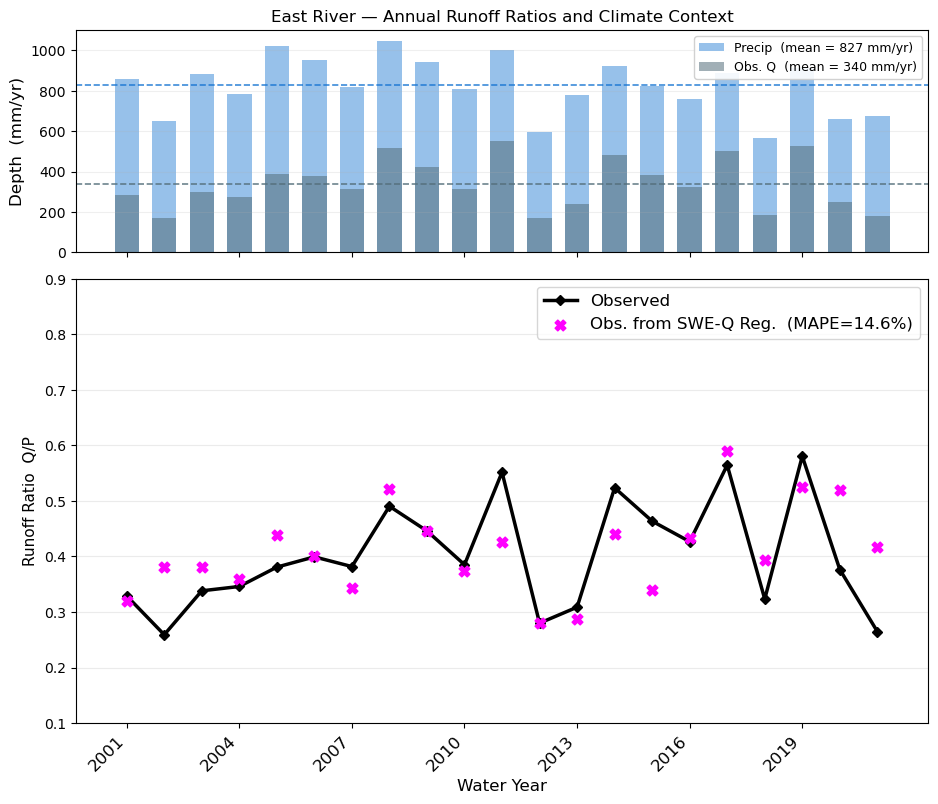

In [66]:
# Runoff ratio (Q/P) by water year
# Two panels: P+Q climate context (top) | Q/P spaghetti with MAPE (bottom)

import matplotlib.colors as mcolors
import matplotlib.cm as cm

# --- Precipitation: use pptrate from lumped bigBuckt output (same ERA5 for all) ---
ds_p = xr.open_dataset(model_files['lumped']['bigBuckt'])
area_lump = domain_areas['lumped']
p_rate = ds_p['pptrate'].squeeze()                        # kg m-2 s-1
p_daily = (p_rate * 86400).resample(time='1D').mean()    # mm/day
x = np.arange(2001, 2022)

precip_wy = {}
for wy in range(2001, 2022):
    p_wy = p_daily.sel(time=slice(f"{wy-1}-10-01", f"{wy}-09-30"))
    if len(p_wy) > 0:
        precip_wy[wy] = float(p_wy.sum())
precip_series = pd.Series(precip_wy)

# --- Observed Q in depth (mm/yr) ---
obs_q_mm = {}
for wy in range(2001, 2022):
    obs_wy = obs_streamflow['value'].loc[f"{wy-1}-10-01":f"{wy}-09-30"].dropna()
    if not obs_wy.empty:
        obs_q_mm[wy] = obs_wy.sum() * 86400 / area_lump * 1000  # m3/s -> mm/yr
obs_q_mm = pd.Series(obs_q_mm)

# --- Modeled Q in depth (mm/yr) per model ---
rr_box_data, rr_years = [], []
for wy in sorted(precip_series.index):
    if wy not in obs_q_mm.index:
        continue
    p_mm = precip_series[wy]
    model_rr = []
    for (domain, model_key), sim_df in annual_q_dict.items():
        if wy not in sim_df.index:
            continue
        area = domain_areas[domain]
        q_mm = sim_df.loc[wy, 'annual_q'] * 86400 / area * 1000
        model_rr.append(q_mm / p_mm)
    if model_rr:
        rr_box_data.append(model_rr)
        rr_years.append(wy)

obs_rr = obs_q_mm / precip_series
obs_rr = obs_rr.dropna()

# SWE-Q regression runoff ratio
obs_q_from_swe = obs_apr1 * 0.97 + 6.98
obs_rr_from_swe = obs_q_from_swe / precip_series
obs_rr_from_swe = obs_rr_from_swe.dropna()

# --- Observed RR aligned to rr_years for MAPE calculation ---
obs_rr_aligned = obs_rr.reindex(rr_years)

# --- Figure: 2 panels (P+Q top, Q/P bottom) ---
fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True,
                         gridspec_kw={'hspace': 0.08, 'height_ratios': [1, 2]})

# --- Panel 1 (top): Precipitation + Observed Q, overlaid, translucent ---
ax_clim = axes[0]
mean_p = precip_series.reindex(rr_years).mean()
mean_q = obs_q_mm.reindex(rr_years).mean()

ax_clim.bar(x, precip_series.reindex(rr_years).values,
            color='#1976D2', alpha=0.45, width=0.65,
            label=f'Precip  (mean = {mean_p:.0f} mm/yr)')
ax_clim.bar(x, obs_q_mm.reindex(rr_years).values,
            color='#546E7A', alpha=0.55, width=0.65,
            label=f'Obs. Q  (mean = {mean_q:.0f} mm/yr)')
ax_clim.axhline(mean_p, color='#1976D2', linestyle='--', linewidth=1.2, alpha=0.85)
ax_clim.axhline(mean_q, color='#546E7A', linestyle='--', linewidth=1.2, alpha=0.85)
ax_clim.set_ylabel('Depth  (mm/yr)', fontsize=12)
ax_clim.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax_clim.grid(True, alpha=0.2, axis='y')
ax_clim.set_title('East River — Annual Runoff Ratios and Climate Context', fontsize=12)

# --- Panel 2 (bottom): Q/P spaghetti with MAPE labels ---
ax = axes[1]

# for (domain, model_key), sim_df in annual_q_dict.items():
#     style = model_styles.get(domain, {}).get(model_key)
#     if style is None:
#         continue
#     area = domain_areas[domain]
#     rr_vals = {
#         wy: (sim_df.loc[wy, 'annual_q'] * 86400 / area * 1000) / precip_series[wy]
#         for wy in sim_df.index
#         if wy in precip_series.index and precip_series[wy] > 0
#     }
#     rr_s = pd.Series(rr_vals).reindex(rr_years)
#     common = obs_rr_aligned.notna() & rr_s.notna()
#     mape = np.mean(np.abs(rr_s[common].values - obs_rr_aligned[common].values)
#                    / np.abs(obs_rr_aligned[common].values)) * 100
#     ax.plot(x, rr_s.values,
#             color=style['color'], linestyle=style['ls'],
#             linewidth=1.5, alpha=0.8,
#             label=f"{style['label']}  (MAPE={mape:.1f}%)")

# Observed Q/P
ax.plot(x, obs_rr.reindex(rr_years).values,
        color='black', linewidth=2.5, marker='D', markersize=5,
        zorder=10, label='Observed')

# SWE-Q regression with MAPE vs observed
obs_rr_swe_aligned = obs_rr_from_swe.reindex(rr_years)
common_swe = obs_rr_aligned.notna() & obs_rr_swe_aligned.notna()
mape_swe = np.mean(np.abs(obs_rr_swe_aligned[common_swe].values - obs_rr_aligned[common_swe].values)
                   / np.abs(obs_rr_aligned[common_swe].values)) * 100
ax.scatter(x, obs_rr_swe_aligned.values,
           color='magenta', marker='X', s=60, zorder=11,
           label=f'Obs. from SWE-Q Reg.  (MAPE={mape_swe:.1f}%)')

ax.set_ylabel('Runoff Ratio  Q/P', fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.25, axis='y')
order = [0,3,7,9,12,1,4,6,10, 13,2,5,8, 11]
handles, labels = ax.get_legend_handles_labels()
ax.legend(fontsize=12)
# ax.legend(handles=[handles[i] for i in order], labels=[labels[i] for i in order], fontsize=9, ncol=3, loc='upper left', framealpha=0.9, 
#           # increase the height of the legend bbox
#           bbox_to_anchor=(0, 0.8, 1, 0.2), mode='expand',
#           # align text right
#           alignment='right'
#           )

ax.set_xticks(x[::3])
ax.set_xticklabels(rr_years[::3], rotation=45, ha='right', fontsize=12)
ax.set_xlabel('Water Year', fontsize=12)
ax.set_ylim(0.1,0.9)

# plt.savefig(f'/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/results/{DOMAIN}_runoff_ratio_wy.png',
#             dpi=150, bbox_inches='tight')
plt.show()

## October 1 soil moisture by model type

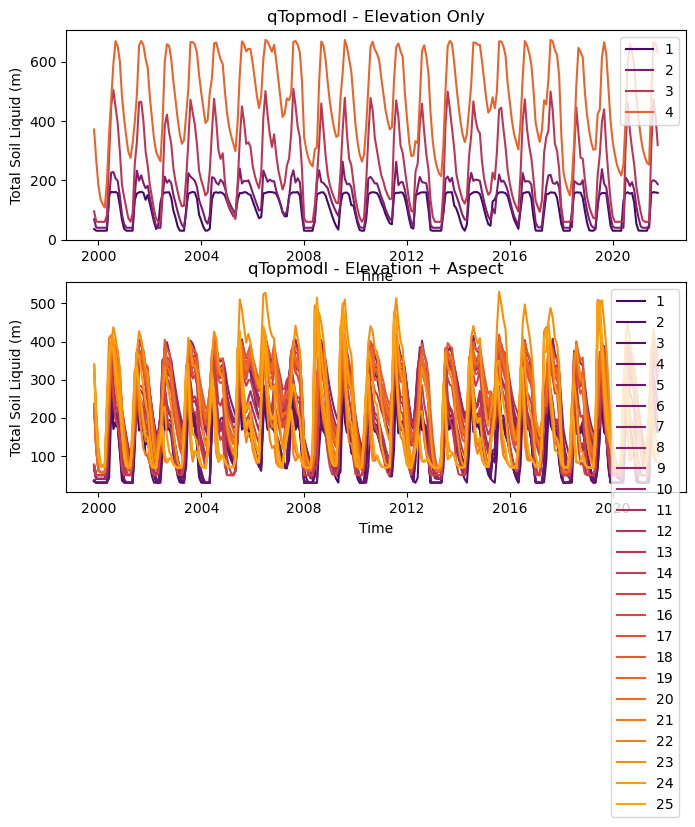

In [67]:
fig, axs = plt.subplots(nrows=2, figsize=(8, 6))
elv_qtop_fp = model_files['distributed_elev']['qTopmodl']
elv_as_qtop_fp = model_files['distributed_elevAspect']['qTopmodl']
ds_qtop_elv = xr.open_dataset(elv_qtop_fp)['scalarTotalSoilLiq'].to_pandas().resample('1ME').mean()
ds_qtop_elv_as = xr.open_dataset(elv_as_qtop_fp)['scalarTotalSoilLiq'].to_pandas().resample('1ME').mean()
# inferno colormap dependins on length of columns
elv_colors = plt.cm.inferno(np.linspace(0.2, 0.8, len(ds_qtop_elv.columns)))
as_colors = plt.cm.inferno(np.linspace(0.2, 0.8, len(ds_qtop_elv_as.columns)))

# plot time series of monthly soil liquid
for i,col in enumerate(ds_qtop_elv.columns):
    if col ==5:
        continue
    axs[0].plot(ds_qtop_elv.index, ds_qtop_elv[col], label=col, color=elv_colors[i])

axs[0].set_xlabel('Time')
axs[0].set_ylabel('Total Soil Liquid (m)')
axs[0].set_title('qTopmodl - Elevation Only')

for i,col in enumerate(ds_qtop_elv_as.columns):
    axs[1].plot(ds_qtop_elv_as.index, ds_qtop_elv_as[col], label=col, color=as_colors[i])
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Total Soil Liquid (m)')
axs[1].set_title('qTopmodl - Elevation + Aspect')

# for ax in axs:
#     ax.set_ylim(0,1400)
axs[0].legend(loc='upper right')
axs[1].legend(loc='upper right')


Text(0.5, 1.0, 'East River — October 1 Soil Moisture by Model\n(scalarTotalSoilLiq, normalized)')

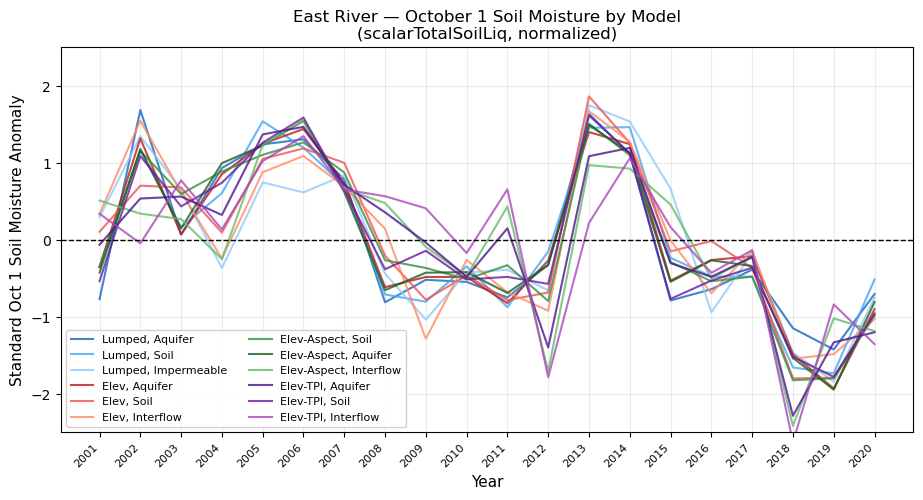

In [68]:
# plot October 1 soil moisture across models as spaghetti plot using scalarTotalSoiLiq
october_1_dates = pd.date_range(start='2001-09-30', end='2021-09-30', freq='YS-OCT')
fig, ax = plt.subplots(figsize=(11, 5))

for (domain, model_key), sim_df in swe_daily_dict.items():
    style = model_styles.get(domain, {}).get(model_key)
    if style is None:
        continue
    filepath = model_files[domain][model_key]
    ds = xr.open_dataset(filepath)
    if 'scalarTotalSoilLiq' not in ds.data_vars:
        continue
    soil_liq = ds['scalarTotalSoilLiq'].mean(dim='hru').resample(time='1D').mean().squeeze()  # mm
    soi_liq_oct1 = []
    for date in october_1_dates:
        if date in soil_liq.time.values:
            soi_liq_oct1.append(float(soil_liq.sel(time=date).values))
        else:
            soi_liq_oct1.append(float(soil_liq.interp(time=date).values))
    soi_liq_s = pd.Series(soi_liq_oct1, index=october_1_dates.year)
    # normalize by the mean of each model
    soi_liq_s = (soi_liq_s - soi_liq_s.mean()) / soi_liq_s.std()
    ax.plot(soi_liq_s.index, soi_liq_s.values,
            color=style['color'], linestyle=style['ls'],
            linewidth=1.5, alpha=0.8, label=style['label'])
plt.axhline(0, color='k', ls='--', lw=1.0, alpha=1.0)
plt.xticks(october_1_dates.year, rotation=45, ha='right', fontsize=8)
plt.xlabel('Year', fontsize=11)
plt.ylabel('Standard Oct 1 Soil Moisture Anomaly', fontsize=11)
plt.grid(True, alpha=0.25)
plt.legend(fontsize=8, ncol=2, loc='lower left', framealpha=0.9)
plt.ylim(-2.5, 2.5)
plt.title('East River — October 1 Soil Moisture by Model\n'
          '(scalarTotalSoilLiq, normalized)', fontsize=12)



## ET time series by model type

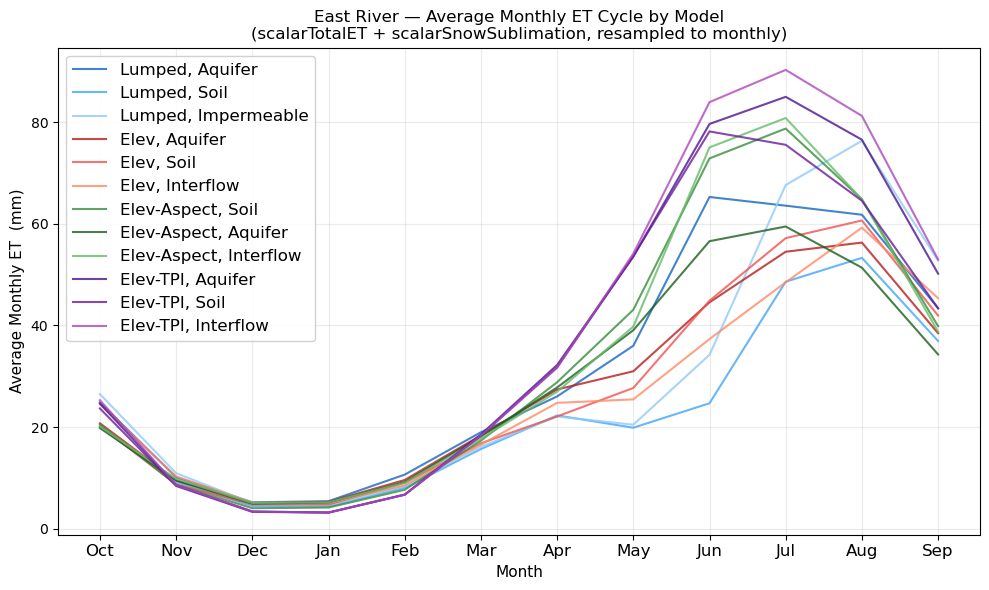

In [69]:
# plot average monthly ET cycle across all models. 
fig, ax = plt.subplots(figsize=(10, 6))
for (domain, model_key), sim_df in annual_q_dict.items():
    style = model_styles.get(domain, {}).get(model_key)
    if style is None:
        continue
    filepath = model_files[domain][model_key]
    ds = xr.open_dataset(filepath)
    if 'scalarTotalET' not in ds.data_vars:
        continue
    et_monthly = (-(ds['scalarTotalET']+ds['scalarSnowSublimation'])*3600).mean(dim='hru').to_pandas()
    et_monthly = et_monthly.resample('1ME').sum()
    monthly_mean = et_monthly.groupby(et_monthly.index.month).mean()
    # order from October (10) to September (9)
    monthly_mean = monthly_mean.reindex([10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9]).reset_index()

    ax.plot(monthly_mean.index, monthly_mean[0],
            color=style['color'], linestyle=style['ls'],
            linewidth=1.5, alpha=0.8, label=style['label'])
ax.set_xticks(range(0, 12))
ax.set_xticklabels(['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep'], fontsize=12)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Average Monthly ET  (mm)', fontsize=11)
ax.set_title('East River — Average Monthly ET Cycle by Model\n'
             '(scalarTotalET + scalarSnowSublimation, resampled to monthly)', fontsize=12)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=12, ncol=1, loc='upper left', framealpha=0.9)
plt.tight_layout()



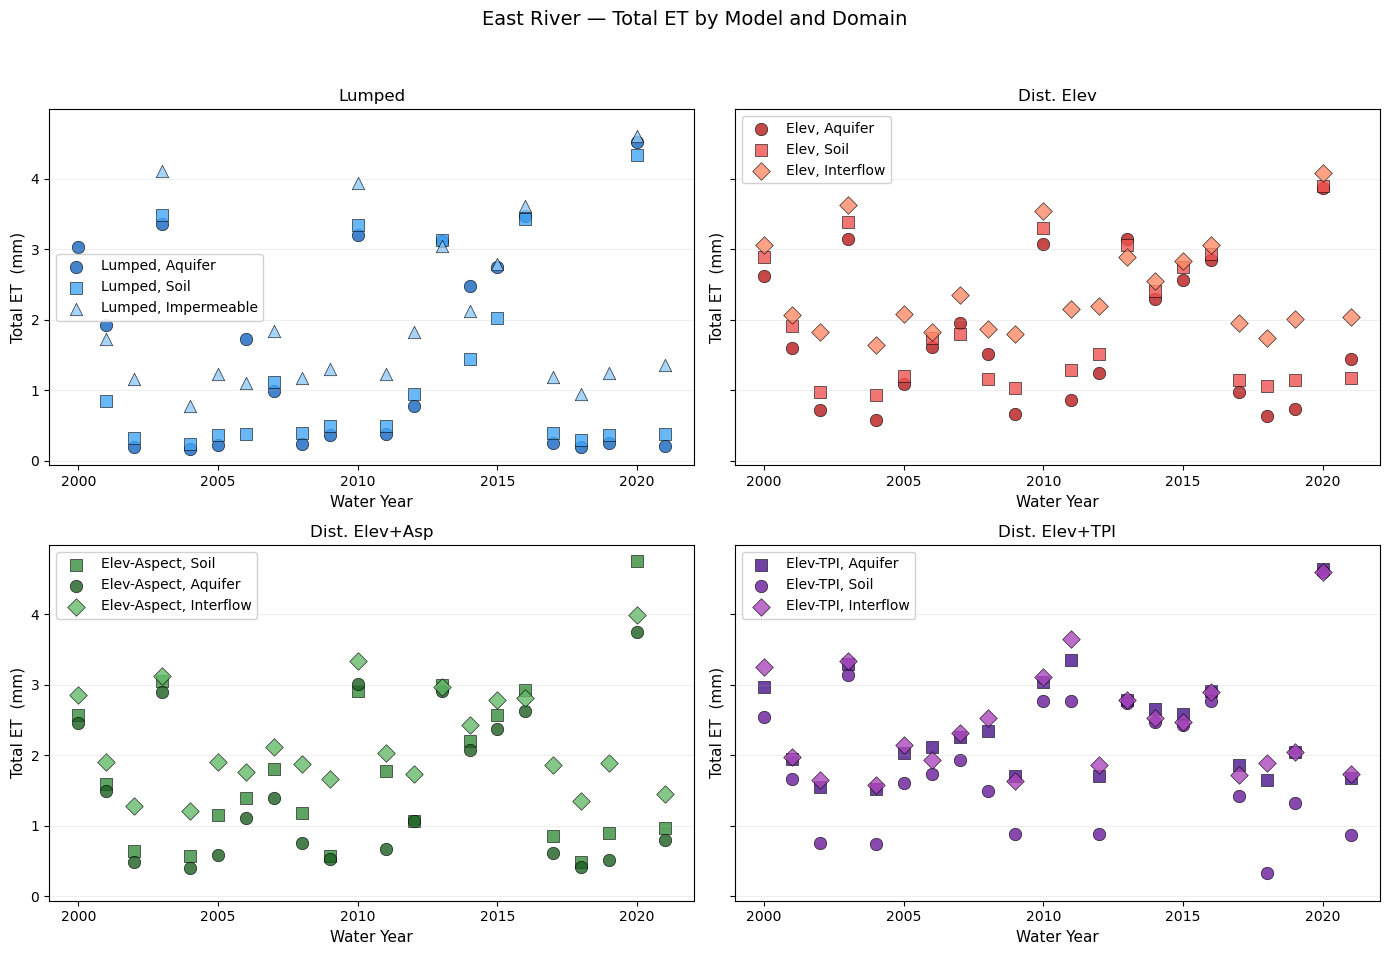

In [70]:
# plot a 2x2 panel plot with bar plots of the Total ET timeseries for each year for each domain 
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
# shape for each model type
shapes = {
    'bigBuckt':          'o',
    'noXplict_drainage': 's',
    'noXplict_zeroFlux': '^',
    'qTopmodl':          'D',
}
for i, domain in enumerate(['lumped', 'distributed_elev', 'distributed_elevAspect', 'distributed_elevTPI']):
    ax = axes[i//2, i%2]
    for model_key in model_discharge[domain].keys():
        style = model_styles.get(domain, {}).get(model_key)
        
        if style is None:
            continue
        filepath = model_files[domain][model_key]
        hru_areas = xr.open_dataset(attr_paths[domain])['HRUarea']
        ds = xr.open_dataset(filepath)
        if 'scalarTotalET' not in ds.data_vars or 'scalarSnowSublimation' not in ds.data_vars:
            continue
        # calculate weighted mean ET

        et_daily = ((-(ds['scalarTotalET']+ds['scalarSnowSublimation'])*3600).to_pandas()*hru_areas.values).sum(axis=1)/(hru_areas.values.sum())
        # et_daily = (ds['scalarTotalSoilLiq'].to_pandas()*hru_areas.values).sum(axis=1)/(hru_areas.values.sum())
        et_daily = et_daily.resample('1D').sum()
        et_annual = et_daily.resample('YS-SEP').last()
        # drop years after 2021
        et_annual = et_annual[et_annual.index.year <= 2020]
        # add 1 year to get water year
        et_annual.index = et_annual.index + pd.offsets.DateOffset(years=1)
        ax.scatter(et_annual.index.year, et_annual.values,
                   color=style['color'], marker=shapes.get(model_key, 'o'), s=80, edgecolors='k', linewidths=0.5, alpha=0.8, label=style['label'])
    ax.set_title(f"{domain_labels[domain]}", fontsize=12)
    ax.set_xlabel('Water Year', fontsize=11)
    ax.set_ylabel('Total ET  (mm)', fontsize=11)
    ax.grid(True, alpha=0.2, axis='y')
    ax.legend(fontsize=10, framealpha=0.9)
# plt.ylim(100,500)
plt.suptitle('East River — Total ET by Model and Domain', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Sublimation time-series by model type

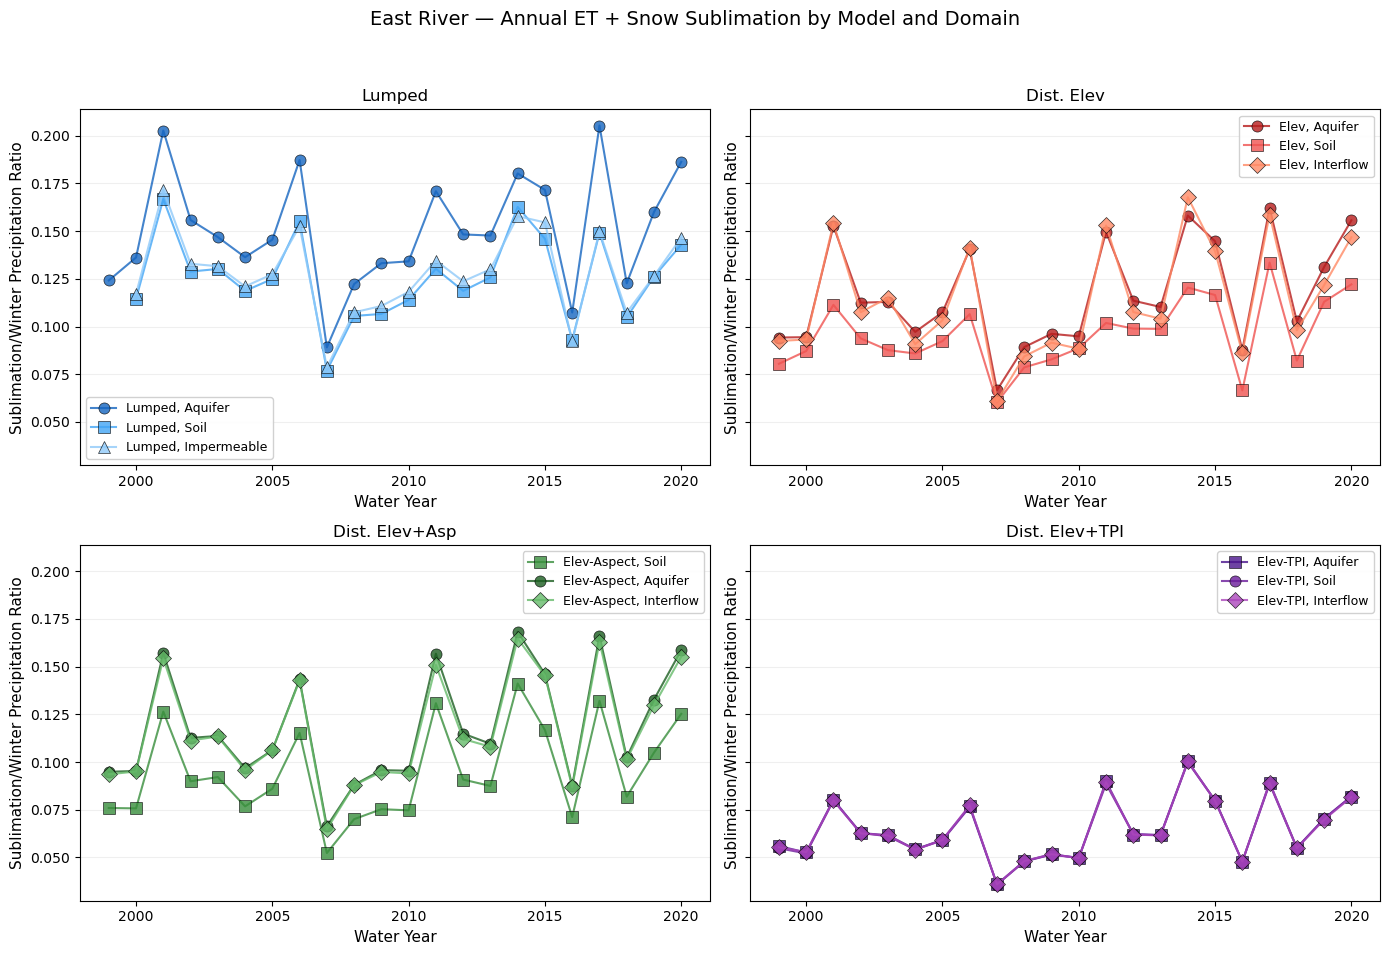

In [71]:
# plot a 2x2 panel plot with bar plots of the annual ET + snow sublimation timeseries for each year for each domain 
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)
# shape for each model type
shapes = {
    'bigBuckt':          'o',
    'noXplict_drainage': 's',
    'noXplict_zeroFlux': '^',
    'qTopmodl':          'D',
}
for i, domain in enumerate(['lumped', 'distributed_elev', 'distributed_elevAspect', 'distributed_elevTPI']):
    ax = axes[i//2, i%2]
    for model_key in model_discharge[domain].keys():
        style = model_styles.get(domain, {}).get(model_key)
        if style is None:
            continue
        filepath = model_files[domain][model_key]
        ds = xr.open_dataset(filepath)
        if 'scalarTotalET' not in ds.data_vars or 'scalarSnowSublimation' not in ds.data_vars:
            continue
        sub_daily = ((-(ds['scalarSnowSublimation'].where(ds.time.dt.month.isin([12,1,2,3,4])))*3600)).mean(dim='hru').to_pandas()
        winter_ppt = (ds['pptrate'].where(ds.time.dt.month.isin([12,1,2,3,4]))*3600).mean(dim='hru').resample(time='YS-OCT').sum().to_pandas()

        sub_daily = sub_daily.resample('1D').sum()
        sub_annial = sub_daily.resample('YS-OCT').sum()/winter_ppt
        # drop years after 2021
        sub_annial = sub_annial[sub_annial.index.year <= 2021]
        ax.plot(sub_annial.index.year, sub_annial.values,
                   color=style['color'], marker=shapes.get(model_key, 'o'), ms=8, markeredgecolor='k', markeredgewidth=0.5, alpha=0.8, label=style['label'])
    ax.set_title(f"{domain_labels[domain]}", fontsize=12)
    ax.set_xlabel('Water Year', fontsize=11)
    ax.set_ylabel('Sublimation/Winter Precipitation Ratio', fontsize=11)
    ax.grid(True, alpha=0.2, axis='y')
    ax.legend(fontsize=9, framealpha=0.9)
plt.suptitle('East River — Annual ET + Snow Sublimation by Model and Domain', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Aquifer storage accross domain types

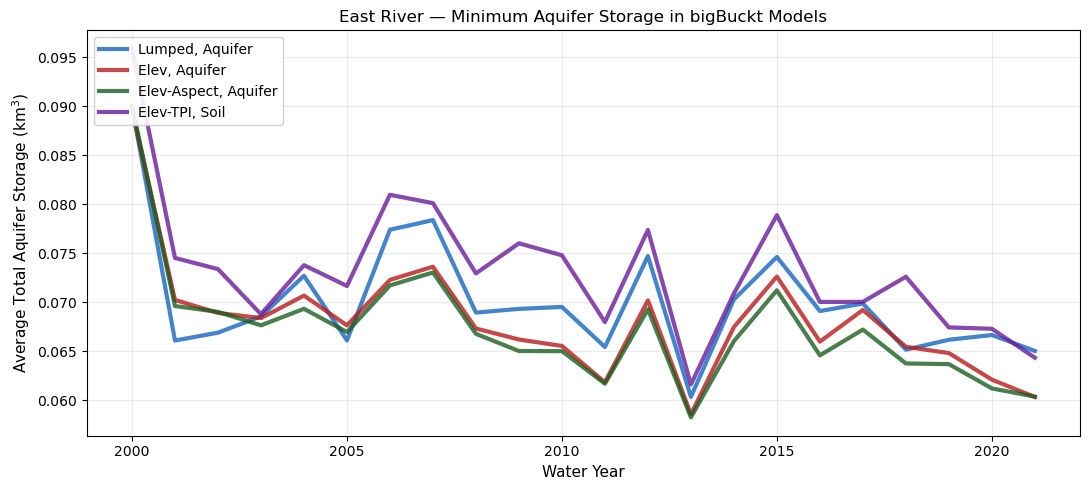

In [72]:
# compare scalarAquiferStorage_mean across bigBuckt models 
import geopandas as gpd
basin_area_m2 = gpd.read_file("/scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/catchment/East_River_lumped_HRUs_GRUs.shp")['HRU_area']
fig, ax = plt.subplots(figsize=(11, 5))
for (domain, model_key), sim_df in annual_q_dict.items():
    if model_key != 'bigBuckt':
        continue
    style = model_styles.get(domain, {}).get(model_key)
    if style is None:
        continue
    filepath = model_files[domain][model_key]
    ds = xr.open_dataset(filepath)
    if 'scalarAquiferStorage_mean' not in ds.data_vars:
        continue
    aquifer_storage = ds['scalarAquiferStorage_mean'].mean(dim='hru').to_pandas()
    aquifer_storage = aquifer_storage.resample('1D').mean()
    aquifer_annual = aquifer_storage.resample('YE-SEP').min()
    # drop years after 2021
    aquifer_annual = aquifer_annual[(aquifer_annual.index.year <= 2021) & (aquifer_annual.index.year >= 2000)]
    # add 1 year to get water year
    aquifer_annual.index = aquifer_annual.index
    ax.plot(aquifer_annual.index.year, aquifer_annual.values*basin_area_m2.mean()/1e9,
            color=style['color'], linestyle=style['ls'], ms=8, markeredgecolor='k', markeredgewidth=0.5,
            linewidth=3.0, alpha=0.8, label=style['label'])
ax.set_xlabel('Water Year', fontsize=11)
ax.set_ylabel('Average Total Aquifer Storage (km$^3$)', fontsize=11)
ax.set_title('East River — Minimum Aquifer Storage in bigBuckt Models', fontsize=12)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=10, loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.show()

In [73]:
# Annual total water storage and storage change by model/domain
storage_total = {}
storage_change = {}

def _area_weighted_series(da, hru_areas):
    if 'hru' in da.dims:
        df = da.to_pandas()
        return (df * hru_areas.values).sum(axis=1) / hru_areas.values.sum()
    return da.to_pandas()

for domain, files in model_files.items():
    with xr.open_dataset(attr_paths[domain]) as attrs:
        hru_areas = attrs['HRUarea'].load()
    for model_key, filepath in files.items():
        with xr.open_dataset(filepath) as ds:
            soil_liq_var = None
            if 'scalarTotalSoilLiq' in ds.data_vars:
                soil_liq_var = 'scalarTotalSoilLiq'
            elif 'scalarTotalSoilLiq_mean' in ds.data_vars:
                soil_liq_var = 'scalarTotalSoilLiq_mean'
            if soil_liq_var is None:
                continue
            soil_ice_var = None
            if 'scalarTotalSoilIce' in ds.data_vars:
                soil_ice_var = 'scalarTotalSoilIce'
            elif 'scalarTotalSoilIce_mean' in ds.data_vars:
                soil_ice_var = 'scalarTotalSoilIce_mean'
            if soil_ice_var is None:
                continue
            aquifer_var = None
            if 'scalarAquiferStorage_mean' in ds.data_vars:
                aquifer_var = 'scalarAquiferStorage_mean'
            elif 'scalarAquiferStorage' in ds.data_vars:
                aquifer_var = 'scalarAquiferStorage'

            soil_liq = _area_weighted_series(ds[soil_liq_var], hru_areas)
            soil_ice = _area_weighted_series(ds[soil_ice_var], hru_areas)
            if aquifer_var is None:
                aquifer = soil_liq * 0.0
            else:
                aquifer = _area_weighted_series(ds[aquifer_var], hru_areas)
            snow_storage = _area_weighted_series(ds['scalarSWE'], hru_areas) if 'scalarSWE' in ds.data_vars else soil_liq * 0.0

            total_storage = (aquifer * 1000.0) 
            total_storage = total_storage.sort_index()
            total_storage_change = total_storage.where(total_storage.index.year > 2000).resample('YS-OCT').mean().diff()

            key = (domain, model_key)
            storage_change[key] = total_storage_change

storage_change_df = pd.DataFrame(storage_change)
storage_change_df.columns = pd.MultiIndex.from_tuples(storage_change_df.columns, names=['domain', 'model'])


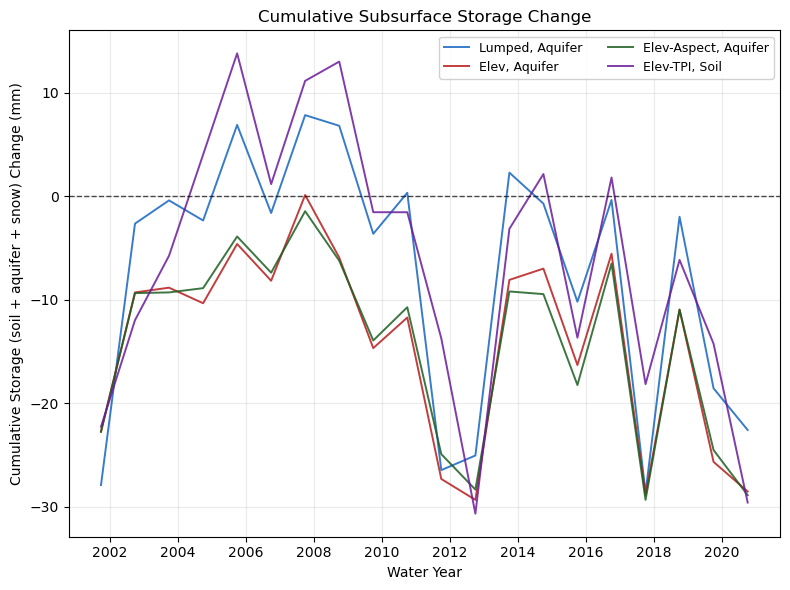

In [74]:

fig, ax = plt.subplots(1, 1, figsize=(8, 6), sharex=True)
for domain, model_key in storage_change_df.columns:
    if model_key != 'bigBuckt':
        continue
    style = model_styles.get(domain, {}).get(model_key, {})
    label = style.get('label', f"{domain}-{model_key}")
    color = style.get('color', None)
    ls = style.get('ls', '-')
    change_series = storage_change_df[(domain, model_key)].dropna()
    if (domain == 'distributed_elevTPI') & (model_key=="qTopmodl"):
        change_series = change_series/2
    cumulative_change = change_series.cumsum()
    ax.plot(cumulative_change.index, cumulative_change.values, color=color, linestyle=ls, linewidth=1.4, alpha=0.85, label=label)

ax.axhline(0, color='k', lw=1, ls='--', alpha=0.7)
ax.set_xlabel('Water Year')
ax.set_ylabel('Cumulative Storage (soil + aquifer + snow) Change (mm)')
ax.set_title('Cumulative Subsurface Storage Change')
ax.grid(True, alpha=0.25)
ax.legend(ncols=2, fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.show()

In [80]:
# for the bigBuckt models, lets make a stacked bar plot of storage by year to show how storage is distributed
domain =  'distributed_elevTPI'
model = 'bigBuckt'
# get the data for soil liquid, soil ice, aquifer, and snow storage for each water year
with xr.open_dataset(attr_paths[domain]) as attrs:
    hru_areas = attrs['HRUarea'].load()

with xr.open_dataset(model_files[domain][model]) as ds:
    soil_liq_var = None
    if 'scalarTotalSoilLiq' in ds.data_vars:
        soil_liq_var = 'scalarTotalSoilLiq'
    elif 'scalarTotalSoilLiq_mean' in ds.data_vars:
        soil_liq_var = 'scalarTotalSoilLiq_mean'

    soil_ice_var = None
    if 'scalarTotalSoilIce' in ds.data_vars:
        soil_ice_var = 'scalarTotalSoilIce'
    elif 'scalarTotalSoilIce_mean' in ds.data_vars:
        soil_ice_var = 'scalarTotalSoilIce_mean'

    aquifer_var = None
    if 'scalarAquiferStorage_mean' in ds.data_vars:
        aquifer_var = 'scalarAquiferStorage_mean'
    elif 'scalarAquiferStorage' in ds.data_vars:
        aquifer_var = 'scalarAquiferStorage'

    soil_liq = _area_weighted_series(ds[soil_liq_var], hru_areas)
    soil_ice = _area_weighted_series(ds[soil_ice_var], hru_areas)
    if aquifer_var is None:
        aquifer = soil_liq * 0.0
    else:
        aquifer = _area_weighted_series(ds[aquifer_var], hru_areas)

    snow_storage = _area_weighted_series(ds['scalarSWE'], hru_areas) if 'scalarSWE' in ds.data_vars else soil_liq * 0.0

# group each by water year mean 
soil_wy = (soil_liq+soil_ice).where(soil_liq.index.year > 2000).resample('YS-OCT').last()
aquifer_wy = aquifer.where(aquifer.index.year > 2000).resample('YS-OCT').last()
snow_wy = snow_storage.where((snow_storage.index.year < 2021) & (snow_storage.index.year > 1999)).resample('YE-JUL').last().dropna()
snow_wy.index = soil_wy.index[:len(snow_wy)]
snow_wy.iloc[-1] = snow_wy.iloc[-1] * 0

In [81]:
# groundwater observations 
gw_obs = pd.read_csv("/scratch/dlhogan/ess-project-data/groundwater-data/east_ph_gw_2018to2022/data/er_plm6_waterlevel_daily_2016-2022.csv", parse_dates=['Date_time'], skiprows=5, index_col='Date_time')
gw_obs2 = pd.read_csv("/scratch/dlhogan/ess-project-data/groundwater-data/east_ph_gw_2018to2022/data/er_plm1_waterlevel_daily_2016-2022.csv", parse_dates=['Date_time'], skiprows=5, index_col='Date_time')
# mean observed storage by wy
gw_obs_wy = gw_obs['Waterlevel_1d_trend'].where(gw_obs.index.year > 2017).resample('YE-SEP').last()
gw_obs_wy.index = gw_obs_wy.index.year 

gw_obs2_wy = gw_obs2['Waterlevel_1d_trend'].where(gw_obs2.index.year > 2017).resample('YE-SEP').last()
gw_obs2_wy.index = gw_obs2_wy.index.year

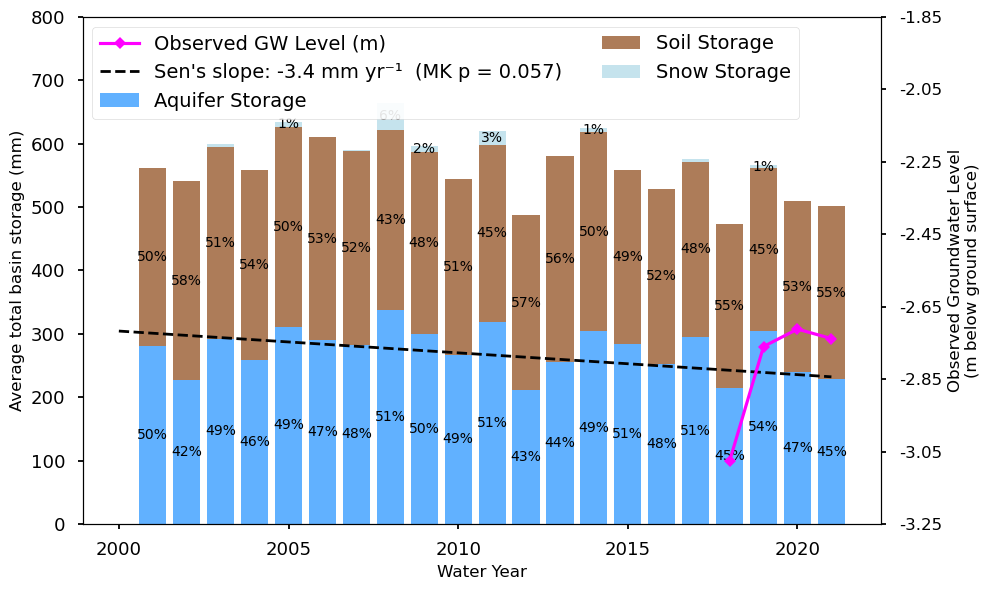

In [86]:
plt.style.use('seaborn-v0_8-talk')
# stacked bar chart by year
fig, ax = plt.subplots(figsize=(10, 6))

aquifer_mm = aquifer_wy.values * 1000 * 2
soil_mm = soil_wy.values
snow_mm = snow_wy.values
total_mm = aquifer_mm + soil_mm + snow_mm

ax.bar(aquifer_wy.index.year+1, aquifer_mm, label='Aquifer Storage', color='#1E90FF', alpha=0.7)
ax.bar(soil_wy.index.year+1, soil_mm, label='Soil Storage', bottom=aquifer_mm, color='#8B4513', alpha=0.7)
ax.bar(snow_wy.index.year+1, snow_mm, bottom=aquifer_mm + soil_mm, label='Snow Storage', color='#ADD8E6', alpha=0.7)

# add percent labels for each category per year
for i, year in enumerate(aquifer_wy.index.year):
    if total_mm[i] == 0:
        continue
    aquifer_pct = aquifer_mm[i] / total_mm[i] * 100.0
    soil_pct = soil_mm[i] / total_mm[i] * 100.0
    snow_pct = snow_mm[i] / total_mm[i] * 100.0

    aquifer_mid = aquifer_mm[i] / 2.0
    soil_mid = aquifer_mm[i] + soil_mm[i] / 2.0
    snow_mid = aquifer_mm[i] + soil_mm[i] + snow_mm[i] / 2.0

    if aquifer_mm[i] > 5:
        ax.text(year+1, aquifer_mid, f"{aquifer_pct:.0f}%", ha='center', va='center', fontsize=10, color='black')
    if soil_mm[i] > 5:
        ax.text(year+1, soil_mid, f"{soil_pct:.0f}%", ha='center', va='center', fontsize=10, color='black')
    if snow_mm[i] > 5:
        ax.text(year+1, snow_mid, f"{snow_pct:.0f}%", ha='center', va='center', fontsize=10, color='black')

ax2= ax.twinx()

ax2.plot(gw_obs_wy[1:-2].index, gw_obs_wy[1:-2], color='magenta', marker='D', markersize=6, label='Observed GW Level', zorder=10)
ax2.set_ylim(2.7565e3, 2.7578e3)
# dummy plot for legend
ax.plot([], [], color='magenta', marker='D', markersize=6, label='Observed GW Level (m)', zorder=10)
# change y-axis ticks to be in meters below ground surface, assuming 2757.5 m is the ground surface elevation
gw_ticks = ax2.get_yticks()
gw_tick_labels = [f"-{2759.65 - tick:.2f}" for tick in gw_ticks]


import pymannkendall as mk

aquifer_mm = aquifer_wy.values * 1000 * 2
soil_mm    = soil_wy.values
snow_mm    = snow_wy.values
total_mm   = aquifer_mm + soil_mm + snow_mm

# Mann-Kendall on total storage
mk_result  = mk.original_test(total_mm)
years_x    = aquifer_wy.index.year + 1
trend_line = mk_result.slope * np.arange(len(years_x)) + mk_result.intercept

# ... your existing bar + percent-label code ...

# add Sen's slope trend line
p_val  = mk_result.p
slope  = mk_result.slope
trend_label = (f"Sen's slope: {slope:+.1f} mm yr⁻¹  (MK p = {p_val:.3f}"
               + (" *)" if p_val < 0.05 else ")"))
ax.plot(years_x, trend_line-300, color='black', lw=2.0, ls='--',
        label=trend_label, zorder=6)

ax2.set_yticks(gw_ticks)
ax2.set_yticklabels(gw_tick_labels, fontsize=12)
ax2.set_ylabel('Observed Groundwater Level\n(m below ground surface)', fontsize=12)
ax.set_xlabel('Water Year', fontsize=12)
ax.set_ylabel('Average total basin storage (mm)', fontsize=12)
# ax.set_title(f'End-of-Season Storage (Sept 30) Components by Water Year - East River', fontsize=12)
ax.set_ylim(0, 800)
ax.legend(ncols=2, loc='upper left', fontsize=14, framealpha=0.9)
plt.tight_layout()

## Spatial mean and variability

In [46]:
import geopandas as gpd
shapefile_catchment_dirs = {
    'lumped':              '/scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/catchment',
    'distributed_elev':    '/scratch/dlhogan/ess-project-data/domain_East_River_distributed/shapefiles/catchment',
    'distributed_elevAspect': '/scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevAspect/shapefiles/catchment',
    'distributed_elevTPI': '/scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevTPI/shapefiles/catchment',
}

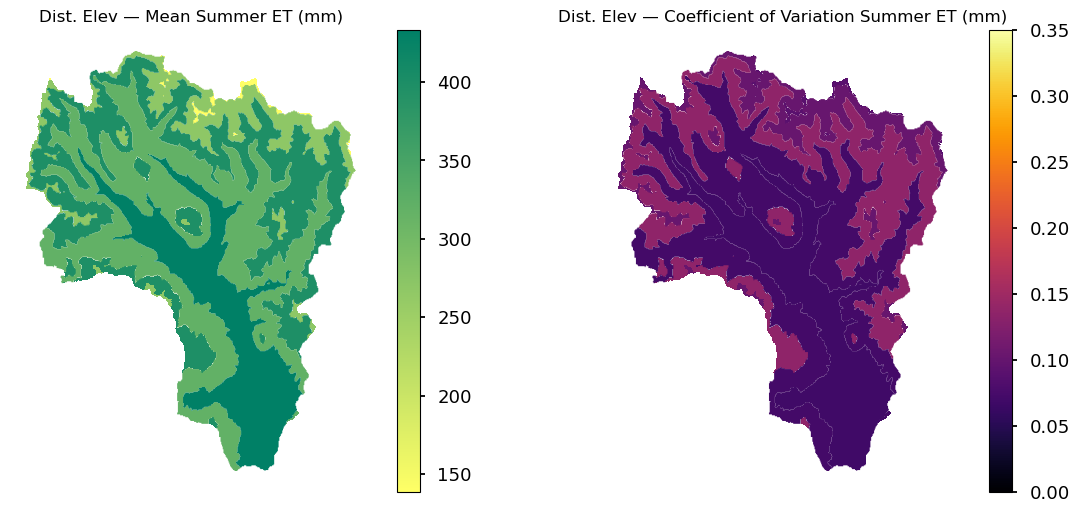

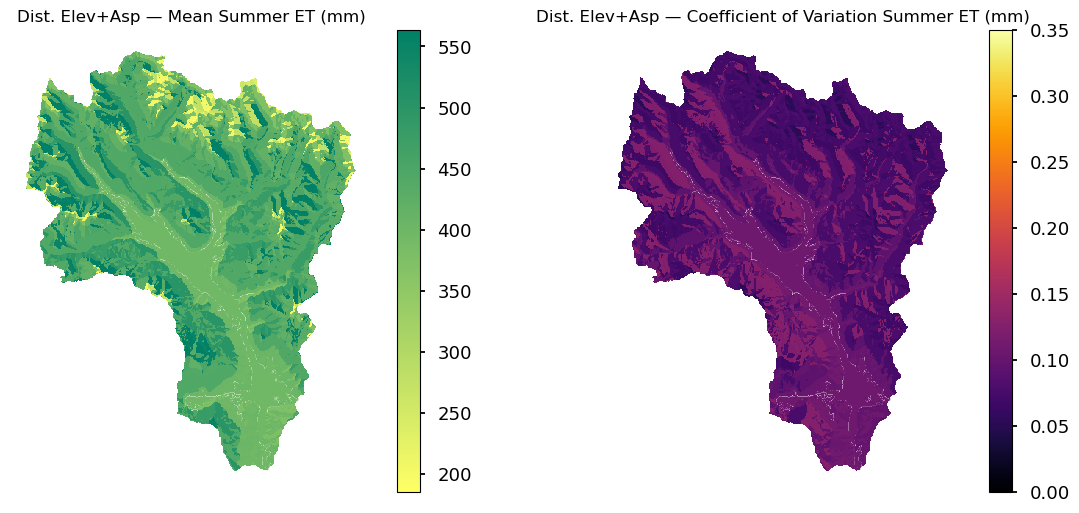

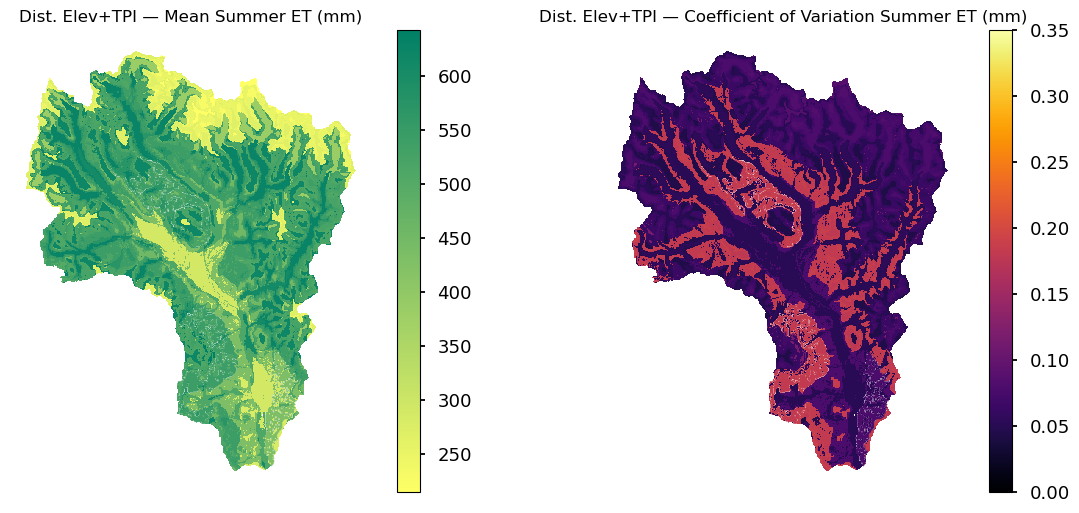

In [47]:
from glob import glob
# 2x2 plot of spatial maps of variable of choice 
var_to_plot = 'scalarTotalET'  # example variable

for i, domain in enumerate(['distributed_elev', 'distributed_elevAspect', 'distributed_elevTPI']):
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    shapefile_dir = shapefile_catchment_dirs[domain]
    # grab the first shapefile
    shapefile_path = glob(f"{shapefile_dir}/*.shp")[0]
    gdf = gpd.read_file(shapefile_path)
    months_to_plot = [1,2,3,4,5,6,7,8,9,10,11,12]
    ds = xr.open_dataset(model_files[domain]['noXplict_drainage'])
    # plot the mean scalarTotalET filled into the basin
    summer_et = (-(ds['scalarTotalET']+ds['scalarSnowSublimation'])*3600).resample(time='YS-APR').sum().sel(time=slice('2002', '2021'))
    summer_et_mean = summer_et.mean(dim='time')
    summer_et_cv = summer_et.std(dim='time') / summer_et.mean(dim='time')
    gdf['mean_et'] = gdf['HRU_ID'].apply(lambda hru_id: float(summer_et_mean.sel(hru=hru_id).values))
    gdf['cv_et'] = gdf['HRU_ID'].apply(lambda hru_id: float(summer_et_cv.sel(hru=hru_id).values))

    ax = axs[0]
    gdf.plot(column='mean_et', cmap='summer_r', legend=True, ax=ax)
    ax.set_title(f"{domain_labels[domain]} — Mean Summer ET (mm)", fontsize=12)
    ax.set_axis_off()

    ax = axs[1]
    gdf.plot(column='cv_et', cmap='inferno', legend=True, ax=ax, vmin=0, vmax=0.35)
    ax.set_title(f"{domain_labels[domain]} — Coefficient of Variation Summer ET (mm)", fontsize=12)
    ax.set_axis_off()

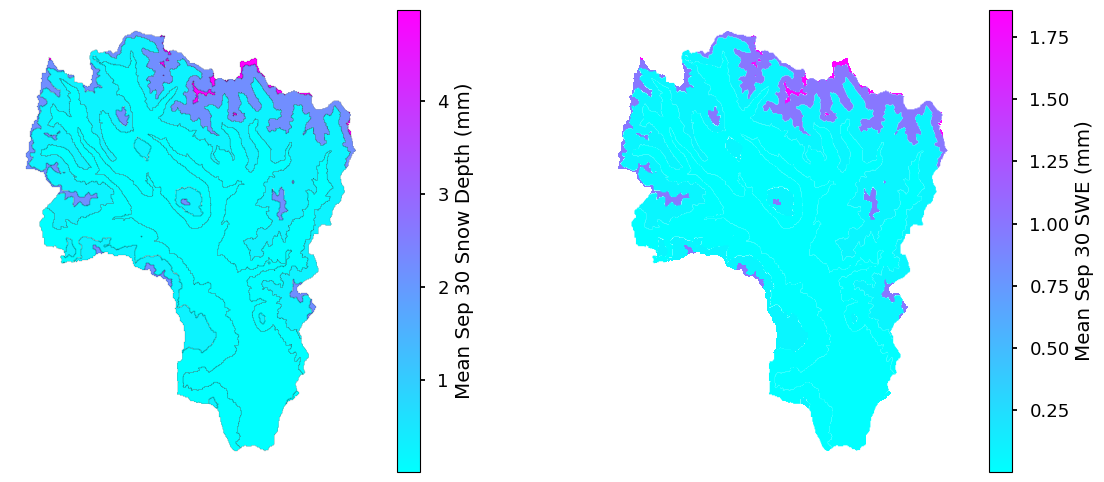

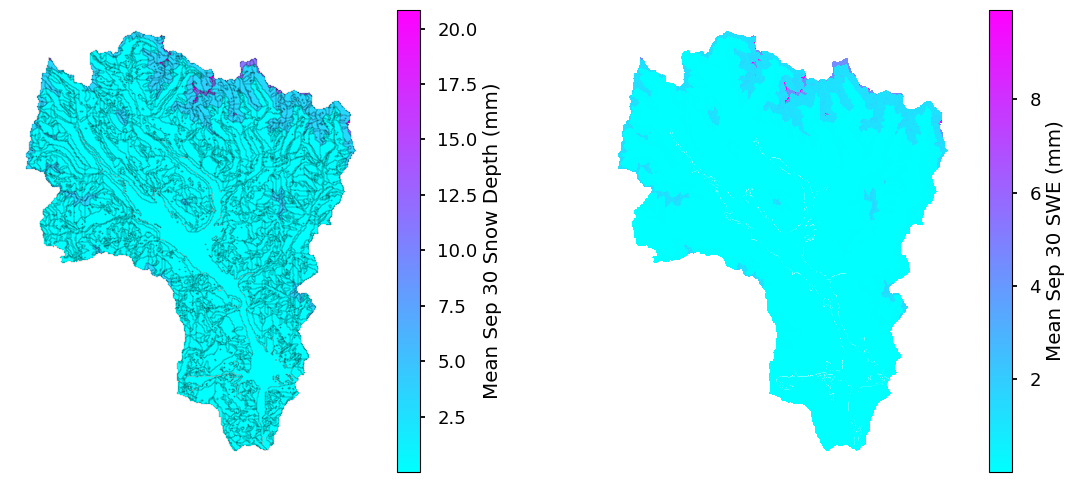

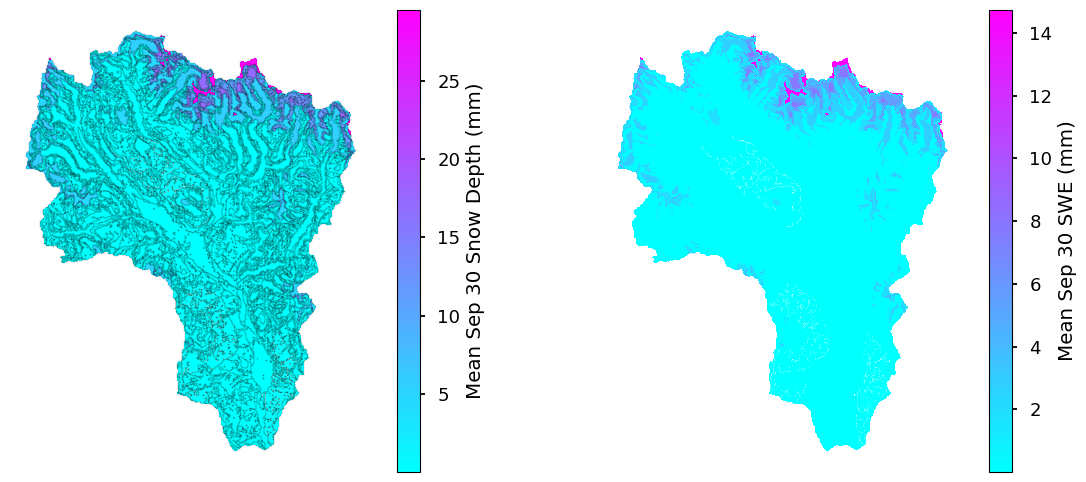

In [48]:
from glob import glob
# 2x2 plot of spatial maps of variable of choice 
var_to_plot = 'scalarSnowDepth_mean'  # example variable

for i, domain in enumerate(['distributed_elev', 'distributed_elevAspect', 'distributed_elevTPI']):
    fig, axs = plt.subplots(1, 2, figsize=(14, 6))
    shapefile_dir = shapefile_catchment_dirs[domain]
    # grab the first shapefile
    shapefile_path = glob(f"{shapefile_dir}/*.shp")[0]
    gdf = gpd.read_file(shapefile_path)
    month_to_plot = 9
    day_to_plot = 30
    ds = xr.open_dataset(model_files[domain]['bigBuckt'])
    # plot the mean scalarTotalSoilLiq filled into the basin
    sep30_snow_depth = (ds[var_to_plot]).where((ds.time.dt.month == month_to_plot) & (ds.time.dt.day == day_to_plot)).resample(time='YS-OCT').last().sel(time=slice('2001', '2021'))*500
    sep30_snow_depth_mean = sep30_snow_depth.mean(dim='time')

    sep30_SWE = (ds['scalarSWE']).where((ds.time.dt.month == month_to_plot) & (ds.time.dt.day == day_to_plot)).resample(time='YS-OCT').last().sel(time=slice('2001', '2021'))
    sep30_SWE_mean = sep30_SWE.mean(dim='time')
    gdf['mean_sep30_snow_depth'] = gdf['HRU_ID'].apply(lambda hru_id: float(sep30_snow_depth_mean.sel(hru=hru_id).values))
    gdf['mean_sep30_swe'] = gdf['HRU_ID'].apply(lambda hru_id: float(sep30_SWE_mean.sel(hru=hru_id).values))

    ax = axs[0]
    gdf.plot(column='mean_sep30_snow_depth', cmap='cool', legend=True, ax=ax, legend_kwds={'label': 'Mean Sep 30 Snow Depth (mm)'})
    # plot hru outlines
    gdf.boundary.plot(color='k', linewidth=0.2, ax=ax, alpha=0.5)
    # ax.set_title(f"{domain_labels[domain]} — 2001-2021 Mean September 30 Snow Depth (mm)", fontsize=12)
    ax.set_axis_off()

    ax = axs[1]
    gdf.plot(column='mean_sep30_swe', cmap='cool', legend=True, ax=ax, legend_kwds={'label': 'Mean Sep 30 SWE (mm)'})
    ax.set_axis_off()
    # ax.set_title(f"{domain_labels[domain]} — 2001-2021 Mean September 30 SWE (mm)", fontsize=12)

## Water balance mean and standard deviation comparison

In [49]:
# make a 5 panel plot with the mean, and standard deviation of ET, peak streamflow, low flow, subsurface storage
# organize with bar charts for each model type (bars) in each domain (x-axis), with error bars showing the standard deviation across years.

# fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)
# variables = ['annual_q', 'scalarTotalET', 'scalarSnowSublimation', 'scalar'

# use model_discharge dict to get peak 7-D mean streamflow for each year, then average across years and get std dev
peak_7d_q = {}
min_7d_q = {}
wy_total_q = {}
for domain in model_discharge.keys():
    for model_key in model_discharge[domain].keys():
        for wy in range(2002, 2022):
            sim_df = model_discharge[domain][model_key]
            # get the daily streamflow for this water year
            runoff_wy = sim_df.loc[f"{wy-1}-10-01":f"{wy}-09-30"]
            if len(runoff_wy) < 7:
                continue
            peak_7d_q[(domain, model_key, wy)] = runoff_wy.rolling(window=7).mean().max()
            min_7d_q[(domain, model_key, wy)] = runoff_wy.rolling(window=7).mean().min()
            # convert to mm equivalent by dividing by basin area and multiplying by 1000
            runoff_wy_mm = runoff_wy / domain_areas['lumped'] * 1000 * 3600*24 # mm.day
            wy_total_q[(domain, model_key, wy)] = runoff_wy_mm.sum()
obs_peak_7d_q = {}
obs_min_7d_q = {}
obs_wy_total_q = {}
for wy in range(2002, 2022):
    if wy not in obs_q_mm.index:
        continue
    obs_wy = obs_streamflow['value'].loc[f"{wy-1}-10-01":f"{wy}-09-30"].dropna()
    if len(obs_wy) < 7:
        continue
    obs_peak_7d_q[(wy)] = obs_wy.rolling(window=7).mean().max()
    obs_min_7d_q[(wy)] = obs_wy.rolling(window=7).mean().min()
    ob_wy_mm = obs_wy / domain_areas['lumped'] * 1000 * 3600*24 # mm.day
    obs_wy_total_q[(wy)] = ob_wy_mm.sum()

In [50]:
model_et = {}
for domain in model_discharge.keys():
    for model_key in model_discharge[domain].keys():
        filepath = model_files[domain][model_key]
        ds = xr.open_dataset(filepath)
        if 'scalarTotalET' not in ds.data_vars or 'scalarSnowSublimation' not in ds.data_vars:
            continue
        hru_areas = xr.open_dataset(attr_paths[domain])['HRUarea']
        ds = xr.open_dataset(filepath)
        if 'scalarTotalET' not in ds.data_vars or 'scalarSnowSublimation' not in ds.data_vars:
            continue
        # calculate weighted mean ET

        et_daily = ((-(ds['scalarTotalET']+ds['scalarSnowSublimation'])*3600).to_pandas()*hru_areas.values).sum(axis=1)/(hru_areas.values.sum())
        et_daily = et_daily.resample('1D').sum()
        et_annual = et_daily.resample('YS-OCT').sum()
        et_annual = et_annual[et_annual.index.year > 2000]
        et_annual.index = et_annual.index + pd.offsets.DateOffset(years=1)
        wys = et_annual.index.year
        for wy in wys:
            model_et[(domain, model_key, wy)] = et_annual.loc[et_annual.index.year == wy].values[0]


In [51]:
# model_oct_1_soil_liq = {}
# for (domain, model_key), sim_df in swe_daily_dict.items():
#     style = model_styles.get(domain, {}).get(model_key)
#     if style is None:
#         continue
#     filepath = model_files[domain][model_key]
#     hru_areas = xr.open_dataset(attr_paths[domain])['HRUarea']
#     ds = xr.open_dataset(filepath)
#     if (model_key == 'bigBuckt') | (model_key == 'qTopmodl'):
#         hru_areas = hru_areas.isel(hru=slice(None, -1))
#         ds = ds.isel(hru=slice(None, -1))
#     if 'mLayerVolFracLiq' not in ds.data_vars:
#         mlayer_frac_var = 'mLayerVolFracLiq_mean'
#     else:
#         mlayer_frac_var = 'mLayerVolFracLiq'
#     soil_liq = ((ds['scalarTotalSoilLiq']).resample(time='1D').mean().to_pandas()*hru_areas.values).sum(axis=1)/(hru_areas.values.sum())
#     for date in pd.date_range(start='2001-09-30', end='2021-09-30', freq='YS-OCT'):
#         soi_liq_oct1 = soil_liq.loc[date]
#         model_oct_1_soil_liq[(domain, model_key, date.year + 1)] = soi_liq_oct1*100

In [52]:
for (domain, model_key), sim_df in annual_q_dict.items():
    
    style = model_styles.get(domain, {}).get(model_key)
    if style is None:
        continue
    filepath = model_files[domain][model_key]
    ds = xr.open_dataset(filepath)
    if 'scalarAquiferStorage_mean' not in ds.data_vars:
        continue
    aquifer_storage = ds['scalarAquiferStorage_mean'].mean(dim='hru').to_pandas()
    aquifer_storage = aquifer_storage.resample('1D').mean()
    aquifer_annual = aquifer_storage.resample('YE-SEP').max()
    # drop years after 2021
    aquifer_annual = aquifer_annual[(aquifer_annual.index.year <= 2021) & (aquifer_annual.index.year >= 2000)]
    # add 1 year to get water year
    aquifer_annual.index = aquifer_annual.index + pd.offsets.DateOffset(years=1)

In [53]:
model_total_wy_storage = {}
model_total_wy_storage_change = {}
for (domain, model_key), sim_df in swe_daily_dict.items():
    style = model_styles.get(domain, {}).get(model_key)
    if style is None:
        continue
    filepath = model_files[domain][model_key]
    hru_areas = xr.open_dataset(attr_paths[domain])['HRUarea']
    ds = xr.open_dataset(filepath)
    

    soil_liq_var = None
    if 'scalarTotalSoilLiq' in ds.data_vars:
        soil_liq_var = 'scalarTotalSoilLiq'
    elif 'scalarTotalSoilLiq_mean' in ds.data_vars:
        soil_liq_var = 'scalarTotalSoilLiq_mean'

    soil_ice_var = None
    if 'scalarTotalSoilIce' in ds.data_vars:
        soil_ice_var = 'scalarTotalSoilIce'
    elif 'scalarTotalSoilIce_mean' in ds.data_vars:
        soil_ice_var = 'scalarTotalSoilIce_mean'
    if (domain == 'distributed_elev') & (model_key == 'qTopmodl'):
        ds = xr.open_dataset("/scratch/dlhogan/ess-project-data/domain_East_River_distributed/simulations/qTopmodl_elevation_best_20260421_223508/output/qTopmodl_distributed_elevation_best_timestep.nc")
        ds = ds/2
    soil_liq = ds[soil_liq_var].mean(dim='hru').to_pandas()
    soil_ice = ds[soil_ice_var].mean(dim='hru').to_pandas()
    aquifer_storage = ds['scalarAquiferStorage_mean'].mean(dim='hru').to_pandas()
    
    # group each by water year mean 
    soil_wy = soil_liq[(soil_liq.index.year <= 2021) & (soil_liq.index.year >= 2000)].resample('YE-SEP').last()
    aquifer_wy = aquifer_storage[(aquifer_storage.index.year <= 2021) & (aquifer_storage.index.year >= 2000)].resample('YE-SEP').last()
    snow_storage = _area_weighted_series(ds['scalarSWE'], hru_areas) if 'scalarSWE' in ds.data_vars else soil_liq * 0.0
    snow_wy = snow_storage.where((snow_storage.index.year < 2021) & (snow_storage.index.year > 1999)).resample('YE-SEP').last().dropna()
    
    aquifer_mm = aquifer_wy.values
    soil_mm = soil_wy.values
    snow_mm = snow_wy.values
    
    if model_key == 'bigBuckt':
        total_mm = aquifer_mm * 1000 + soil_mm + snow_mm
    else:
        total_mm = soil_mm + snow_mm
        aquifer_mm = aquifer_mm * 0
    wy = soil_wy.index.year.values
    for i, wy in enumerate(wy):
        model_total_wy_storage[(domain, model_key, wy)] = [total_mm[i], soil_mm[i], aquifer_mm[i]*1000, snow_mm[i]]
        model_total_wy_storage_change[(domain, model_key, wy)] = [total_mm[i] - total_mm[i-1], soil_mm[i] - soil_mm[i-1], aquifer_mm[i]*1000 - aquifer_mm[i-1]*1000, snow_mm[i] - snow_mm[i-1]]
# convert to df
model_total_wy_storage_change_df = pd.DataFrame(model_total_wy_storage_change, ).T

# replace column names 

In [54]:
# to pandas
min_7d_q = pd.Series(min_7d_q)
peak_7d_q = pd.Series(peak_7d_q)
model_et = pd.Series(model_et)
# model_oct_1_soil_liq = pd.Series(model_oct_1_soil_liq)
# columns for storage
cols = ['total_storage', 'soil_storage', 'aquifer_storage', 'snow_storage']
model_total_wy_storage_df = pd.DataFrame.from_dict(model_total_wy_storage, orient='index', columns=cols)
model_total_wy_storage_df.index = pd.MultiIndex.from_tuples(model_total_wy_storage_df.index, names=['domain', 'model', 'water_year'])
# average across years and get std dev
peak_7d_q_stats = peak_7d_q.groupby(level=[0,1]).agg(['mean', 'std'])
min_7d_q_stats = min_7d_q.groupby(level=[0,1]).agg(['mean', 'std'])
model_et_stats = model_et.groupby(level=[0,1]).agg(['mean', 'std'])
# model_oct_1_soil_liq_stats = model_oct_1_soil_liq.groupby(level=[0,1]).agg(['mean', 'std'])
model_total_wy_storage_stats = model_total_wy_storage_df.groupby(level=[0,1]).agg(['mean', 'std'])

# reorder index 
# model renames 
model_key_renames = {
    'noXplict_zeroFlux': 'Impermeable',
    'noXplict_drainage': 'Soil',
    'bigBuckt': 'Aquifer',
    'qTopmodl': 'Interflow',
}
domain_order = ['lumped', 'distributed_elev', 'distributed_elevAspect', 'distributed_elevTPI']

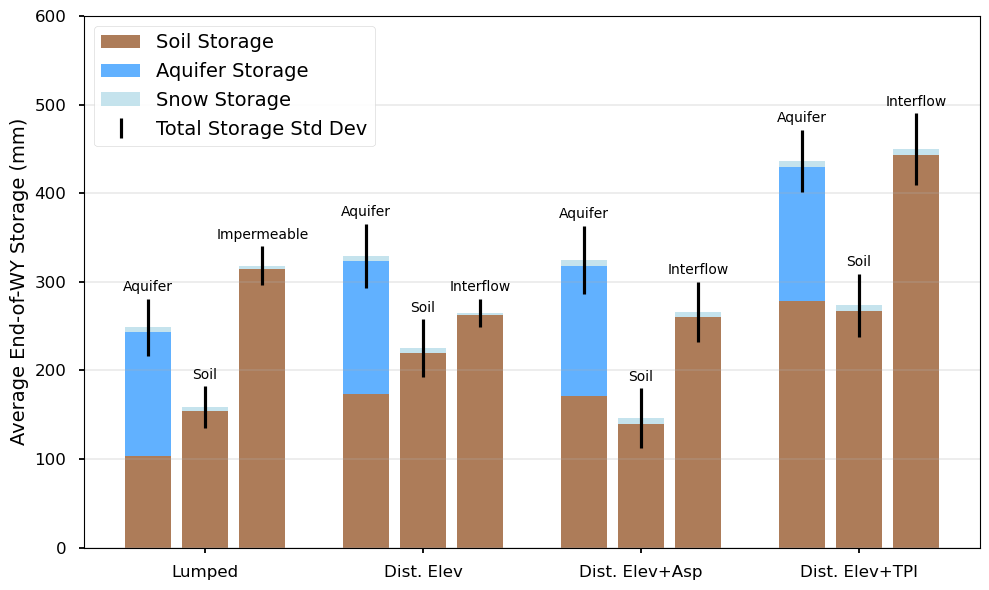

In [55]:
# make a stacked bar plot of the mean storage components, grouped by domain with model labels above each bar
fig, ax = plt.subplots(figsize=(10, 6))

gap = 0.8   # space between domain groups
x_positions = []
group_tick_positions = []
group_tick_labels = []
current_x = 0

# Build grouped x positions, iterating by domain_order
for domain in domain_order:
    if domain not in model_total_wy_storage_stats.index.get_level_values('domain'):
        continue
    group = model_total_wy_storage_stats.xs(domain, level='domain')
    group_start = current_x
    for model_key in group.index:
        x_positions.append((domain, model_key, current_x))
        current_x += 1
    group_tick_positions.append((group_start + current_x - 1) / 2)
    group_tick_labels.append(domain_labels.get(domain, domain))
    current_x += gap

x_arr = np.array([xi for _, _, xi in x_positions])
soil_arr    = np.array([model_total_wy_storage_stats.loc[(d, m), ('soil_storage',    'mean')] for d, m, _ in x_positions])
aquifer_arr = np.array([model_total_wy_storage_stats.loc[(d, m), ('aquifer_storage', 'mean')] for d, m, _ in x_positions])
snow_arr    = np.array([model_total_wy_storage_stats.loc[(d, m), ('snow_storage',    'mean')] for d, m, _ in x_positions])
total_std   = np.array([model_total_wy_storage_stats.loc[(d, m), ('total_storage',   'std')]  for d, m, _ in x_positions])
tops = soil_arr + aquifer_arr + snow_arr

ax.bar(x_arr, soil_arr,    label='Soil Storage',    color='#8B4513', alpha=0.7)
ax.bar(x_arr, aquifer_arr, bottom=soil_arr,         label='Aquifer Storage', color='#1E90FF', alpha=0.7)
ax.bar(x_arr, snow_arr,    bottom=soil_arr+aquifer_arr, label='Snow Storage', color='#ADD8E6', alpha=0.7)
ax.errorbar(x_arr, tops, yerr=total_std, fmt='none', ecolor='k', capsize=5, label='Total Storage Std Dev')

# Model key label above each bar
for (domain, model_key, xi), top, std in zip(x_positions, tops, total_std):
    label = model_key_renames.get(model_key, model_key)
    ax.text(xi, top + std + ax.get_ylim()[1] * 0.01, label,
            ha='center', va='bottom', fontsize=10, rotation=0)

ax.set_xticks(group_tick_positions)
ax.set_xticklabels(group_tick_labels, fontsize=12)
ax.set_yticks(np.arange(0, 601, 100))
ax.set_yticklabels([f'{int(y)}' for y in ax.get_yticks()], fontsize=12)
ax.set_ylabel('Average End-of-WY Storage (mm)', fontsize=14)

# ax.set_title('East River — End-of-WY Storage Components by Model and Domain', fontsize=14)
ax.legend(fontsize=14, loc='upper left', framealpha=0.9)
ax.grid(True, alpha=0.25, axis='y')
ax.set_ylim(0,600)
plt.tight_layout()

/tmp/ipykernel_964005/2700895642.py:6: FutureWarning: 'AS-OCT' is deprecated and will be removed in a future version, please use 'YS-OCT' instead.
  obs_et_annual = obs_et_df.set_index('date').resample('AS-OCT').sum()['et']


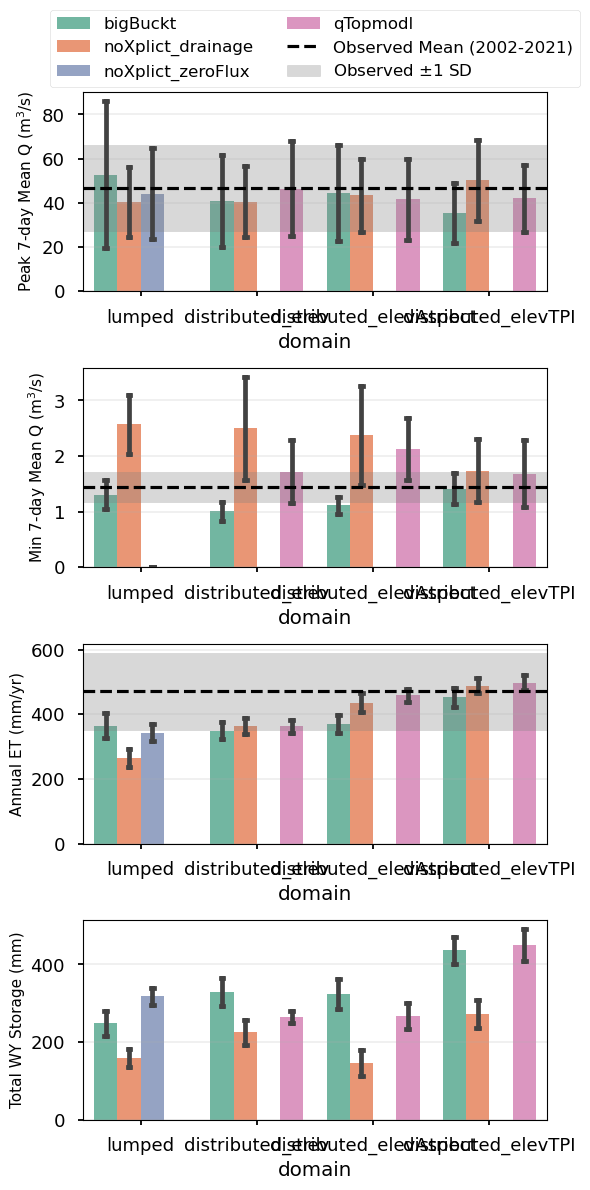

In [56]:
# Load observed ET and calculate annual mean and standard deviation
obs_et_df = pd.read_csv('/scratch/dlhogan/ess-project-data/domain_East_River_lumped/observations/et/openet_et_ensemble_East_monthly.csv', parse_dates=['date'])
# skip winter months (Dec-Mar) to focus on growing season ET
obs_et_df = obs_et_df[~obs_et_df['date'].dt.month.isin([12, 1, 2, 3])]
# Assuming the data is monthly, resample to water year (starting in October)
obs_et_annual = obs_et_df.set_index('date').resample('AS-OCT').sum()['et']
obs_et_mean = obs_et_annual.mean()
obs_et_std = obs_et_annual.std()

# calculate observed peak and min 7-day mean Q 
obs_peak_7d_q_series = pd.Series(obs_peak_7d_q)
obs_min_7d_q_series = pd.Series(obs_min_7d_q)

yaxis_labels = ['Peak 7-day Mean Q (m$^3$/s)', 'Min 7-day Mean Q (m$^3$/s)', 'Annual ET (mm/yr)', 'Total WY Storage (mm)']
fig, axes = plt.subplots(4, 1, figsize=(6, 12), tight_layout=True)
for i, (raw_data, title) in enumerate(zip([peak_7d_q, min_7d_q, model_et, model_total_wy_storage],
                                      yaxis_labels)):
    ax = axes[i]
    if i == 3:
        df = pd.DataFrame(raw_data).T.reset_index()
    else:
        df = pd.DataFrame(raw_data).reset_index()
    if 'val' not in df.columns:
        df = df.rename(columns={'level_0': 'domain', 'level_1': 'model', 0: 'val'})
    else:
        df = df.rename(columns={'level_0': 'domain', 'level_1': 'model'})
    # df['domain'] = df['level_0'].apply(lambda x: domain_labels.get(x, x))
    # df['model'] = df['level_1']
    sns.barplot(data=df, x='domain', y='val', hue='model', ax=ax, errorbar='sd', capsize=0.1, palette='Set2', )
    if title in ['Peak 7-day Mean Q (m$^3$/s)', 'Min 7-day Mean Q (m$^3$/s)']:
        # Highlight observed Q on the Peak and Min 7-day Mean Q subplots
        obs_q_series = obs_peak_7d_q_series if 'Peak' in title else obs_min_7d_q_series
        h_line = ax.axhline(y=obs_q_series.mean(), color='k', linestyle='--', label='Observed Mean (2002-2021)')
        h_span = ax.axhspan(obs_q_series.mean() - obs_q_series.std(), obs_q_series.mean() + obs_q_series.std(), color='gray', alpha=0.3, label='Observed $\pm$1 SD')

    # Highlight observed ET on the Annual ET subplot
    if title == 'Annual ET (mm/yr)':
        h_line = ax.axhline(y=obs_et_mean, color='k', linestyle='--', label='Open ET Mean (2015-2021)')
        h_span = ax.axhspan(obs_et_mean - obs_et_std, obs_et_mean + obs_et_std, color='gray', alpha=0.3, label='Open ET $\pm$1 SD')
        
    
    if i == 0:
        ax.set_ylabel('Value', fontsize=11)
        ax.legend(ncol=2, bbox_to_anchor=(0.5, 1.45), loc='upper center', fontsize=12)
    else:
        ax.set_ylabel('')
        # For the Annual ET plot, keep only the observed legend items, for others remove the legend
        if title == 'Annual ET':
            handles, labels = ax.get_legend_handles_labels()
            # Extract just the lines we added (they appear at the end)
            ax.legend(handles[-2:], labels[-2:], loc='lower left', fontsize=10)
        else:
            if ax.legend_ is not None:
                ax.legend_.remove()
            
    ax.grid(True, alpha=0.2, axis='y')
    ax.set_ylim(0, None)
    ax.set_ylabel(yaxis_labels[i], fontsize=11)

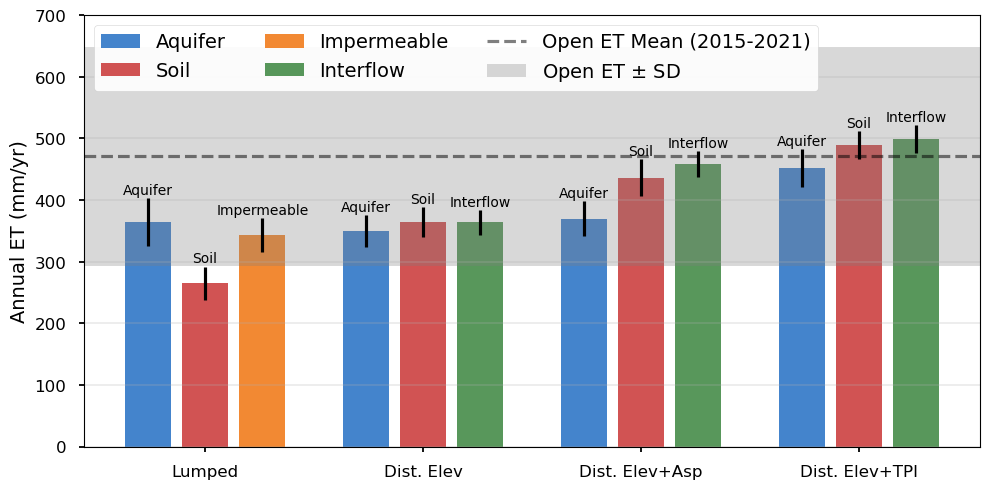

In [57]:
# ET by domain, bars colored by model type
fig, ax = plt.subplots(figsize=(10, 5))
# name model_et_stats level 1: domain, and level 2: model
model_et_stats.index.set_names(['domain', 'model'], inplace=True)
gap = 0.8
x_positions = []
group_tick_positions = []
group_tick_labels = []
current_x = 0

for domain in domain_order:
    lvl = model_et_stats.index.get_level_values("domain")
    if domain not in lvl:
        continue
    group = model_et_stats.xs(domain, level="domain")
    group_start = current_x
    for model_key in group.index:
        x_positions.append((domain, model_key, current_x))
        current_x += 1
    group_tick_positions.append((group_start + current_x - 1) / 2)
    group_tick_labels.append(domain_labels.get(domain, domain))
    current_x += gap

x_arr    = np.array([xi for _, _, xi in x_positions])
et_means = np.array([model_et_stats.loc[(d, m), "mean"] for d, m, _ in x_positions])
et_stds  = np.array([model_et_stats.loc[(d, m), "std"]  for d, m, _ in x_positions])
bar_colors = [model_colors.get(m, "gray") for _, m, _ in x_positions]

ax.bar(x_arr, et_means, color=bar_colors, alpha=0.8, width=0.8)
ax.errorbar(x_arr, et_means, yerr=et_stds, fmt="none", ecolor="k", capsize=5)

# model label above each bar
for (domain, model_key, xi), top, std in zip(x_positions, et_means, et_stds):
    label = model_key_renames.get(model_key, model_key)
    ax.text(xi, top + std + 2, label, ha="center", va="bottom", fontsize=10, rotation=0)

# observed ET reference
ax.axhline(y=obs_et_mean, color="k", linestyle="--", label="Open ET Mean (2015-2021)", alpha=0.5)
ax.axhspan(obs_et_mean - obs_et_std*1.5, obs_et_mean + obs_et_std*1.5,
           color="gray", alpha=0.3, label="Open ET $\pm$ SD")

# model color legend
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=model_colors[m], alpha=0.8, label=model_key_renames.get(m, m))
                  for m in model_colors if m in model_et_stats.index.get_level_values("model")]
ax.legend(ncols=3,handles=legend_handles + [
    plt.Line2D([0], [0], color="k", linestyle="--", label="Open ET Mean (2015-2021)", alpha=0.5),
    plt.Rectangle((0, 0), 1, 1, fc="gray", alpha=0.3, label="Open ET $\pm$ SD"),
], fontsize=14, loc="upper left", framealpha=0.9)

ax.set_xticks(group_tick_positions)
ax.set_xticklabels(group_tick_labels, fontsize=12)
ax.set_yticks(np.arange(0, 701, 100))
ax.set_yticklabels([f"{int(y)}" for y in ax.get_yticks()], fontsize=12)
ax.set_ylabel("Annual ET (mm/yr)", fontsize=14)
# ax.set_title("East River — Annual ET by Model and Domain", fontsize=14)
ax.set_ylim(0, 700)
ax.grid(True, alpha=0.25, axis="y")
plt.tight_layout()


# Growing season (april-june) ET vs. snow disappearance date
Negative correlation indicates that growing season ET decreases with later snow disappearance date: if snow lasts longer, spring ET is less. 

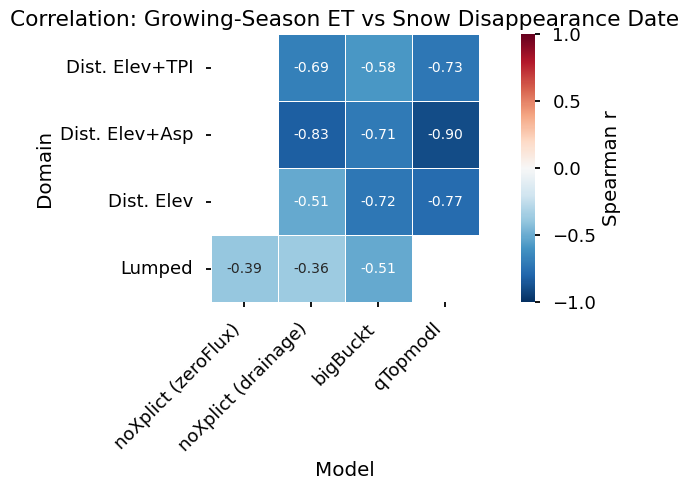

In [58]:
# Correlation heatmap: growing-season ET vs snow disappearance date (all model types)
records = []

time_slice = slice('2001-10-01', '2021-09-30')
snow_threshold_m = 0.01
winter_months = [12, 1, 2, 3]
et_vars = ['scalarTotalET', 'scalarSnowSublimation', 'scalarSnowDepth_mean']
snow_months = [2, 3, 4, 5, 6]

for domain, models in model_files.items():
    for model_key, filepath in models.items():
        with xr.open_dataset(filepath) as ds:
            if any(v not in ds.data_vars for v in et_vars):
                continue
            ds = ds[et_vars].sel(time=time_slice)

            # Growing-season ET (exclude winter months), unweighted mean across HRUs
            et = -(ds['scalarTotalET']) * 3600
            et_mean = et.mean(dim='hru')
            et_gs = et_mean.where(et_mean['time.month'].isin([4,5,6]))
            et_gs_wy = et_gs.resample(time='YS-OCT').sum()

            # Snow disappearance date (last snow day in Apr-Sep), median across HRUs
            snow_depth_daily = ds['scalarSnowDepth_mean'].where(ds['time.month'].isin(snow_months)).resample(time='1D').mean()
            snow_present = snow_depth_daily > snow_threshold_m
            dayofyear = snow_depth_daily['time'].dt.dayofyear
            sdd = (snow_present * dayofyear).groupby('time.year').max('time')
            sdd = sdd.where(sdd > 0)
            sdd_med = sdd.median(dim='hru', skipna=True)

        et_s = et_gs_wy.to_pandas()
        sdd_s = sdd_med.to_pandas()
        et_s.index = (et_s.index + pd.offsets.DateOffset(years=1)).year
        sdd_s.index = sdd_s.index.astype(int)

        temp_df = pd.DataFrame({
            'et_gs': et_s,
            'sdd': sdd_s,
        }).dropna()

        if temp_df.empty:
            continue

        corr_val = temp_df['et_gs'].corr(temp_df['sdd'], method='spearman')
        records.append({'domain': domain, 'model': model_key, 'corr': corr_val})

if not records:
    raise ValueError('No valid data to plot for correlation heatmap.')

corr_df = pd.DataFrame(records)
heatmap_df = corr_df.pivot(index='domain', columns='model', values='corr')

# Full labels
heatmap_df = heatmap_df.rename(index=domain_labels)
model_name_map = {
    'noXplict_zeroFlux': 'noXplict (zeroFlux)',
    'noXplict_drainage': 'noXplict (drainage)',
    'bigBuckt': 'bigBuckt',
    'qTopmodl': 'qTopmodl',
}
heatmap_df = heatmap_df.rename(columns=model_name_map)

domain_order = [
    'Dist. Elev+TPI',
    'Dist. Elev+Asp',
    'Dist. Elev',
    'Lumped',
]
model_order = [
    'noXplict (zeroFlux)',
    'noXplict (drainage)',
    'bigBuckt',
    'qTopmodl',
]
heatmap_df = heatmap_df.reindex(index=domain_order, columns=model_order)

plt.figure(figsize=(9, 5))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.7,
    square=True,
    cbar_kws={'label': 'Spearman r'}
)
plt.title('Correlation: Growing-Season ET vs Snow Disappearance Date')
plt.xlabel('Model')
plt.ylabel('Domain')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Heatmap for spring ET and fall precipitation 

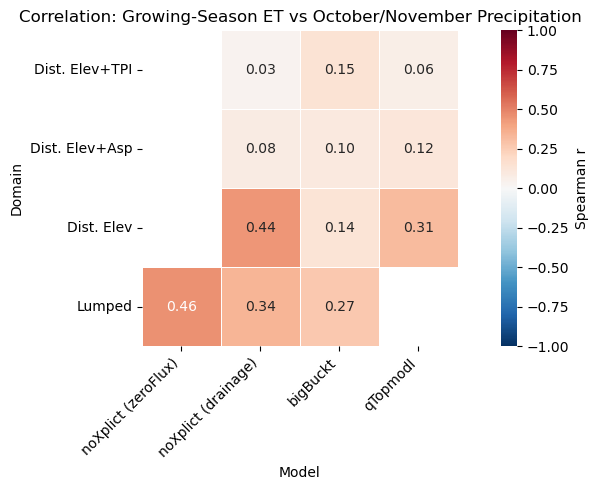

In [ ]:
# Correlation heatmap: growing-season ET vs snow disappearance date (all model types)
records = []

time_slice = slice('2001-10-01', '2021-09-30')
et_vars = ['scalarTotalET', 'scalarSnowSublimation', 'pptrate']
fall_months = [9, 10, 11]

for domain, models in model_files.items():
    for model_key, filepath in models.items():
        with xr.open_dataset(filepath) as ds:
            if any(v not in ds.data_vars for v in et_vars):
                continue
            ds = ds[et_vars].sel(time=time_slice)

            # Growing-season ET (exclude winter months), unweighted mean across HRUs
            et = -(ds['scalarTotalET']) * 3600
            et_mean = et.mean(dim='hru')
            et_gs = et_mean.where(et_mean['time.month'].isin([4,5,6]))
            et_gs_wy = et_gs.resample(time='YS-OCT').sum()

            # Snow disappearance date (last snow day in Apr-Sep), median across HRUs
            ppt_daily = ds['pptrate'].where(ds_p['time.month'].isin(fall_months))
            ppt_mean = ppt_daily.mean(dim='hru')
            ppt_gs = ppt_mean.where(ppt_mean['time.month'].isin(fall_months))
            ppt_gs_wy = ppt_gs.resample(time='YS-OCT').sum()

        et_s = et_gs_wy.to_pandas()
        spring_ppt_s = ppt_gs_wy.to_pandas()

        temp_df = pd.DataFrame({
            'et_gs': et_s,
            'spring_ppt': spring_ppt_s,
        }).dropna()

        if temp_df.empty:
            continue

        corr_val = temp_df['et_gs'].corr(temp_df['spring_ppt'], method='spearman')
        records.append({'domain': domain, 'model': model_key, 'corr': corr_val})

if not records:
    raise ValueError('No valid data to plot for correlation heatmap.')

corr_df = pd.DataFrame(records)
heatmap_df = corr_df.pivot(index='domain', columns='model', values='corr')

# Full labels
heatmap_df = heatmap_df.rename(index=domain_labels)
model_name_map = {
    'noXplict_zeroFlux': 'noXplict (zeroFlux)',
    'noXplict_drainage': 'noXplict (drainage)',
    'bigBuckt': 'bigBuckt',
    'qTopmodl': 'qTopmodl',
}
heatmap_df = heatmap_df.rename(columns=model_name_map)

domain_order = [
    'Dist. Elev+TPI',
    'Dist. Elev+Asp',
    'Dist. Elev',
    'Lumped',
]
model_order = [
    'noXplict (zeroFlux)',
    'noXplict (drainage)',
    'bigBuckt',
    'qTopmodl',
]
heatmap_df = heatmap_df.reindex(index=domain_order, columns=model_order)

plt.figure(figsize=(9, 5))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.7,
    square=True,
    cbar_kws={'label': 'Spearman r'}
)
plt.title('Correlation: Growing-Season ET vs October/November Precipitation')
plt.xlabel('Model')
plt.ylabel('Domain')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Heatmap for spring ET and spring precipitation 

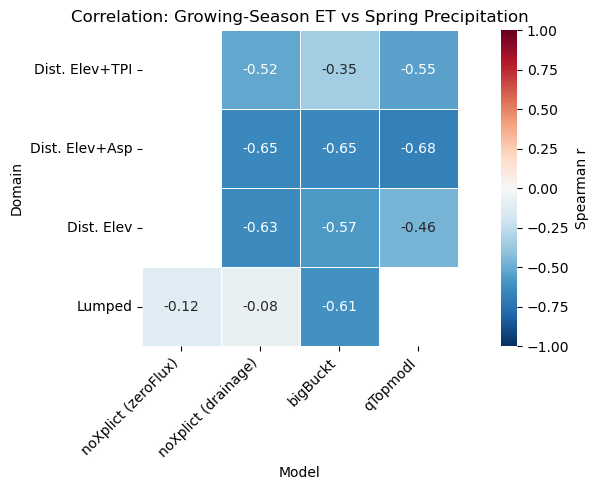

In [ ]:
# Correlation heatmap: growing-season ET vs snow disappearance date (all model types)
records = []

time_slice = slice('2001-10-01', '2021-09-30')
et_vars = ['scalarTotalET', 'scalarSnowSublimation', 'pptrate']
spring_months = [3, 4, 5,6]

for domain, models in model_files.items():
    for model_key, filepath in models.items():
        with xr.open_dataset(filepath) as ds:
            if any(v not in ds.data_vars for v in et_vars):
                continue
            ds = ds[et_vars].sel(time=time_slice)

            # Growing-season ET (exclude winter months), unweighted mean across HRUs
            et = -(ds['scalarTotalET']) * 3600
            et_mean = et.mean(dim='hru')
            et_gs = et_mean.where(et_mean['time.month'].isin([4,5,6]))
            et_gs_wy = et_gs.resample(time='YS-OCT').sum()

            # Snow disappearance date (last snow day in Apr-Sep), median across HRUs
            ppt_daily = ds['pptrate'].where(ds_p['time.month'].isin(spring_months))
            ppt_mean = ppt_daily.mean(dim='hru')
            ppt_gs = ppt_mean.where(ppt_mean['time.month'].isin(spring_months))
            ppt_gs_wy = ppt_gs.resample(time='YS-OCT').sum()

        et_s = et_gs_wy.to_pandas()
        spring_ppt_s = ppt_gs_wy.to_pandas()

        temp_df = pd.DataFrame({
            'et_gs': et_s,
            'spring_ppt': spring_ppt_s,
        }).dropna()

        if temp_df.empty:
            continue

        corr_val = temp_df['et_gs'].corr(temp_df['spring_ppt'], method='spearman')
        records.append({'domain': domain, 'model': model_key, 'corr': corr_val})

if not records:
    raise ValueError('No valid data to plot for correlation heatmap.')

corr_df = pd.DataFrame(records)
heatmap_df = corr_df.pivot(index='domain', columns='model', values='corr')

# Full labels
heatmap_df = heatmap_df.rename(index=domain_labels)
model_name_map = {
    'noXplict_zeroFlux': 'noXplict (zeroFlux)',
    'noXplict_drainage': 'noXplict (drainage)',
    'bigBuckt': 'bigBuckt',
    'qTopmodl': 'qTopmodl',
}
heatmap_df = heatmap_df.rename(columns=model_name_map)

domain_order = [
    'Dist. Elev+TPI',
    'Dist. Elev+Asp',
    'Dist. Elev',
    'Lumped',
]
model_order = [
    'noXplict (zeroFlux)',
    'noXplict (drainage)',
    'bigBuckt',
    'qTopmodl',
]
heatmap_df = heatmap_df.reindex(index=domain_order, columns=model_order)

plt.figure(figsize=(9, 5))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.7,
    square=True,
    cbar_kws={'label': 'Spearman r'}
)
plt.title('Correlation: Growing-Season ET vs Spring Precipitation')
plt.xlabel('Model')
plt.ylabel('Domain')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

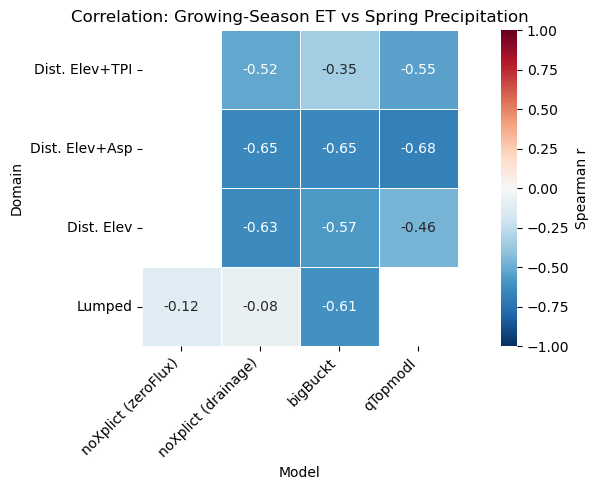

In [ ]:
# Correlation heatmap: growing-season ET vs snow disappearance date (all model types)
records = []

time_slice = slice('2001-10-01', '2021-09-30')
et_vars = ['scalarTotalET', 'scalarSnowSublimation', 'pptrate']
spring_months = [3, 4, 5, 6]

for domain, models in model_files.items():
    for model_key, filepath in models.items():
        with xr.open_dataset(filepath) as ds:
            if any(v not in ds.data_vars for v in et_vars):
                continue
            ds = ds[et_vars].sel(time=time_slice)

            # Growing-season ET (exclude winter months), unweighted mean across HRUs
            et = -(ds['scalarTotalET']) * 3600
            et_mean = et.mean(dim='hru')
            et_gs = et_mean.where(et_mean['time.month'].isin([4,5,6]))
            et_gs_wy = et_gs.resample(time='YS-OCT').sum()

            # Snow disappearance date (last snow day in Apr-Sep), median across HRUs
            ppt_daily = ds['pptrate'].where(ds_p['time.month'].isin(spring_months))
            ppt_mean = ppt_daily.mean(dim='hru')
            ppt_gs = ppt_mean.where(ppt_mean['time.month'].isin(spring_months))
            ppt_gs_wy = ppt_gs.resample(time='YS-OCT').sum()

        et_s = et_gs_wy.to_pandas()
        spring_ppt_s = ppt_gs_wy.to_pandas()

        temp_df = pd.DataFrame({
            'et_gs': et_s,
            'spring_ppt': spring_ppt_s,
        }).dropna()

        if temp_df.empty:
            continue

        corr_val = temp_df['et_gs'].corr(temp_df['spring_ppt'], method='spearman')
        records.append({'domain': domain, 'model': model_key, 'corr': corr_val})

if not records:
    raise ValueError('No valid data to plot for correlation heatmap.')

corr_df = pd.DataFrame(records)
heatmap_df = corr_df.pivot(index='domain', columns='model', values='corr')

# Full labels
heatmap_df = heatmap_df.rename(index=domain_labels)
model_name_map = {
    'noXplict_zeroFlux': 'noXplict (zeroFlux)',
    'noXplict_drainage': 'noXplict (drainage)',
    'bigBuckt': 'bigBuckt',
    'qTopmodl': 'qTopmodl',
}
heatmap_df = heatmap_df.rename(columns=model_name_map)

domain_order = [
    'Dist. Elev+TPI',
    'Dist. Elev+Asp',
    'Dist. Elev',
    'Lumped',
]
model_order = [
    'noXplict (zeroFlux)',
    'noXplict (drainage)',
    'bigBuckt',
    'qTopmodl',
]
heatmap_df = heatmap_df.reindex(index=domain_order, columns=model_order)

plt.figure(figsize=(9, 5))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.7,
    square=True,
    cbar_kws={'label': 'Spearman r'}
)
plt.title('Correlation: Growing-Season ET vs Spring Precipitation')
plt.xlabel('Model')
plt.ylabel('Domain')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Lag-1 ET anomaly (next water year vs. October 1 soil moisture)
Positive correlation means greater fall soil moisture correlates with greater spring ET

/tmp/ipykernel_1551688/1418975355.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  soil_s = model_oct_1_soil_liq.xs((domain, model_key)).sort_index()
/tmp/ipykernel_1551688/1418975355.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  soil_s = model_oct_1_soil_liq.xs((domain, model_key)).sort_index()
/tmp/ipykernel_1551688/1418975355.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  soil_s = model_oct_1_soil_liq.xs((domain, model_key)).sort_index()
/tmp/ipykernel_1551688/1418975355.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  soil_s = model_oct_1_soil_liq.xs((domain, model_key)).sort_index()
/tmp/ipykernel_1551688/1418975355.py:6: PerformanceWarning: indexing past lexsort depth may impact performance.
  soil_s = model_oct_1_soil_liq.xs((domain, model_key)).sort_index()
/tmp/ipykernel_1551688/1418975355.py:6: PerformanceWarning: indexing past lexsort depth may imp

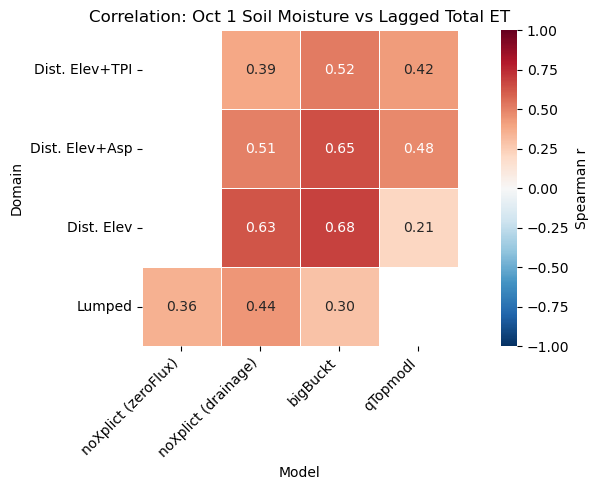

In [ ]:
# Correlation heatmap: lag-1 ET anomaly vs Oct 1 soil moisture anomaly
records = []

for (domain, model_key), et_s in model_et.groupby(level=[0, 1]):
    et_s = et_s.droplevel([0, 1]).sort_index()
    soil_s = model_oct_1_soil_liq.xs((domain, model_key)).sort_index()

    if et_s.std() == 0 or soil_s.std() == 0:
        continue

    et_s_anomaly = (et_s - et_s.mean()) / et_s.std()
    soil_s_anomaly = (soil_s - soil_s.mean()) / soil_s.std()

    # Lag total ET by 1 water year
    lag_et = et_s_anomaly.shift(1)

    temp_df = pd.DataFrame({
        'lag_et': lag_et,
        'oct1_soil': soil_s_anomaly,
    }).dropna()

    if temp_df.empty:
        continue

    corr_val = temp_df['lag_et'].corr(temp_df['oct1_soil'], method='spearman')
    records.append({'domain': domain, 'model': model_key, 'corr': corr_val})

if not records:
    raise ValueError('No valid data to plot for correlation heatmap.')

corr_df = pd.DataFrame(records)
heatmap_df = corr_df.pivot(index='domain', columns='model', values='corr')

# Full labels
heatmap_df = heatmap_df.rename(index=domain_labels)
model_name_map = {
    'noXplict_zeroFlux': 'noXplict (zeroFlux)',
    'noXplict_drainage': 'noXplict (drainage)',
    'bigBuckt': 'bigBuckt',
    'qTopmodl': 'qTopmodl',
}
heatmap_df = heatmap_df.rename(columns=model_name_map)

domain_order = [
    'Dist. Elev+TPI',
    'Dist. Elev+Asp',
    'Dist. Elev',
    'Lumped',
]
model_order = [
    'noXplict (zeroFlux)',
    'noXplict (drainage)',
    'bigBuckt',
    'qTopmodl',
]
heatmap_df = heatmap_df.reindex(index=domain_order, columns=model_order)

plt.figure(figsize=(9, 5))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.7,
    square=True,
    cbar_kws={'label': 'Spearman r'}
)
plt.title('Correlation: Oct 1 Soil Moisture vs Lagged Total ET')
plt.xlabel('Model')
plt.ylabel('Domain')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Aquifer storage and peak SWE lag correlation

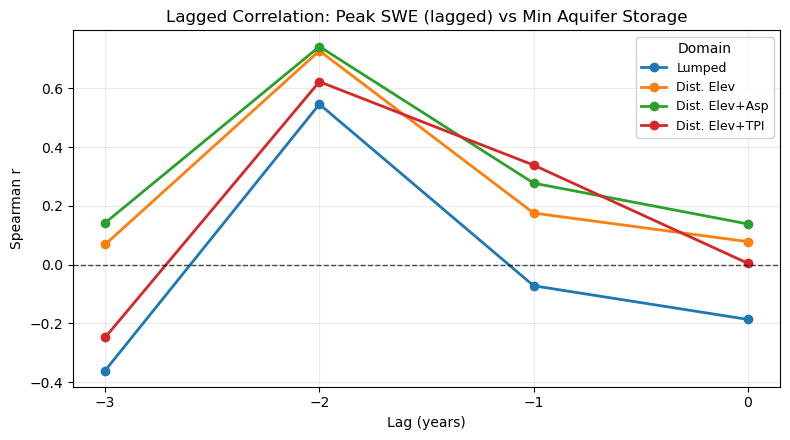

In [ ]:
# Lagged correlation line plot: peak SWE vs min aquifer storage (bigBuckt only)
records = []

time_slice = slice('2001-10-01', '2021-09-30')
lags = list(range(-3, 1))

for domain, models in model_files.items():
    if 'bigBuckt' not in models:
        continue
    filepath = model_files[domain]['bigBuckt']
    with xr.open_dataset(filepath) as ds:
        needed_vars = ['scalarAquiferStorage_mean', 'scalarSWE']
        if any(v not in ds.data_vars for v in needed_vars):
            continue

        ds = ds[needed_vars].sel(time=time_slice)

        # Minimum aquifer storage per water year
        aquifer = ds['scalarAquiferStorage_mean'].mean(dim='hru')
        min_aquifer = aquifer.resample(time='YS-OCT').min()

        # Peak SWE proxy (mean across selected HRUs)
        if len(ds.hru) > 1:
            scalar_swe = ds['scalarSWE'].sel(hru=slice(int(len(ds.hru) * 0.4), None)).resample(time='1D').mean()
        else:
            scalar_swe = ds['scalarSWE'].resample(time='1D').mean()

        peak_swe = (
            scalar_swe.max(dim='hru')
            .resample(time='YS-OCT')
            .sum(dim='time')
        )

    min_aquifer_s = min_aquifer.to_pandas()
    peak_swe_s = peak_swe.to_pandas()

    # Convert to water year labels
    min_aquifer_s.index = (min_aquifer_s.index + pd.offsets.DateOffset(years=1)).year
    peak_swe_s.index = (peak_swe_s.index + pd.offsets.DateOffset(years=1)).year

    for lag in lags:
        temp_df = pd.DataFrame({
            'peak_swe': peak_swe_s,
            'min_aquifer': min_aquifer_s.shift(-lag),
        }).dropna()

        if temp_df.empty:
            continue

        corr_val = temp_df['peak_swe'].corr(temp_df['min_aquifer'], method='spearman')
        records.append({'domain': domain, 'lag': lag, 'corr': corr_val})

if not records:
    raise ValueError('No valid data to plot for lagged correlation.')

corr_df = pd.DataFrame(records)
corr_df['domain_label'] = corr_df['domain'].map(domain_labels)
lag_pivot = corr_df.pivot(index='lag', columns='domain_label', values='corr').reindex(index=lags)

ordered_labels = [domain_labels[d] for d in domain_labels if d in corr_df['domain'].unique()]
lag_pivot = lag_pivot.reindex(columns=ordered_labels)

fig, ax = plt.subplots(figsize=(8, 4.5))
for label in lag_pivot.columns:
    ax.plot(lag_pivot.index, lag_pivot[label], marker='o', linewidth=2, label=label)

ax.axhline(0, color='k', lw=1, ls='--', alpha=0.7)
ax.set_xticks(lags)
ax.set_xlabel('Lag (years)')
ax.set_ylabel('Spearman r')
ax.set_title('Lagged Correlation: Peak SWE (lagged) vs Min Aquifer Storage')
ax.grid(True, alpha=0.25)
ax.legend(title='Domain', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

## Spatial vs. Subsurface: Variance Decomposition

Two-factor decomposition using annual mean discharge as the metric. Spread is normalized IQR (IQR/median). Note: lumped runs do not include `qTopmodl`, and `noXplict` uses drainage only.

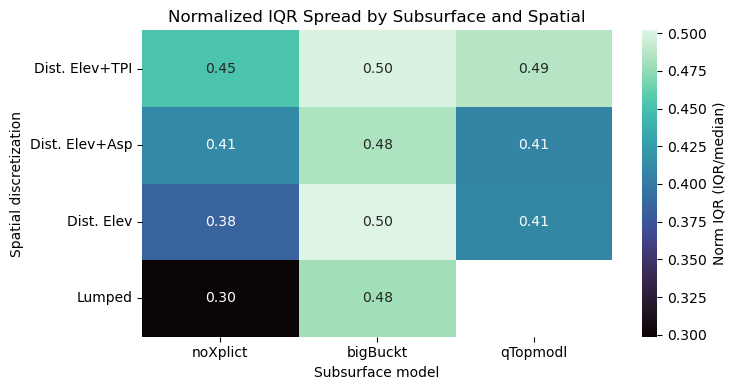

,norm_iqr_subsurface_mean,norm_iqr_spatial_mean,ratio_subsurface,ratio_spatial,ratio_sub_to_streamflow,ratio_spatial_to_streamflow
0,0.084202,0.086369,0.485449,0.514551,0.18424,0.193875


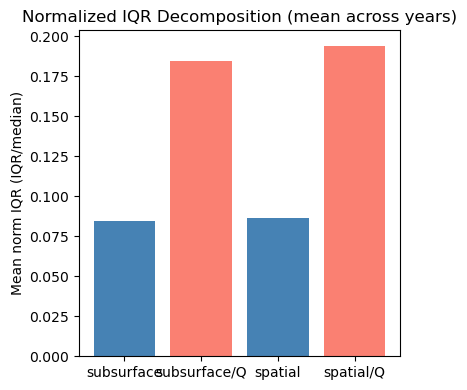

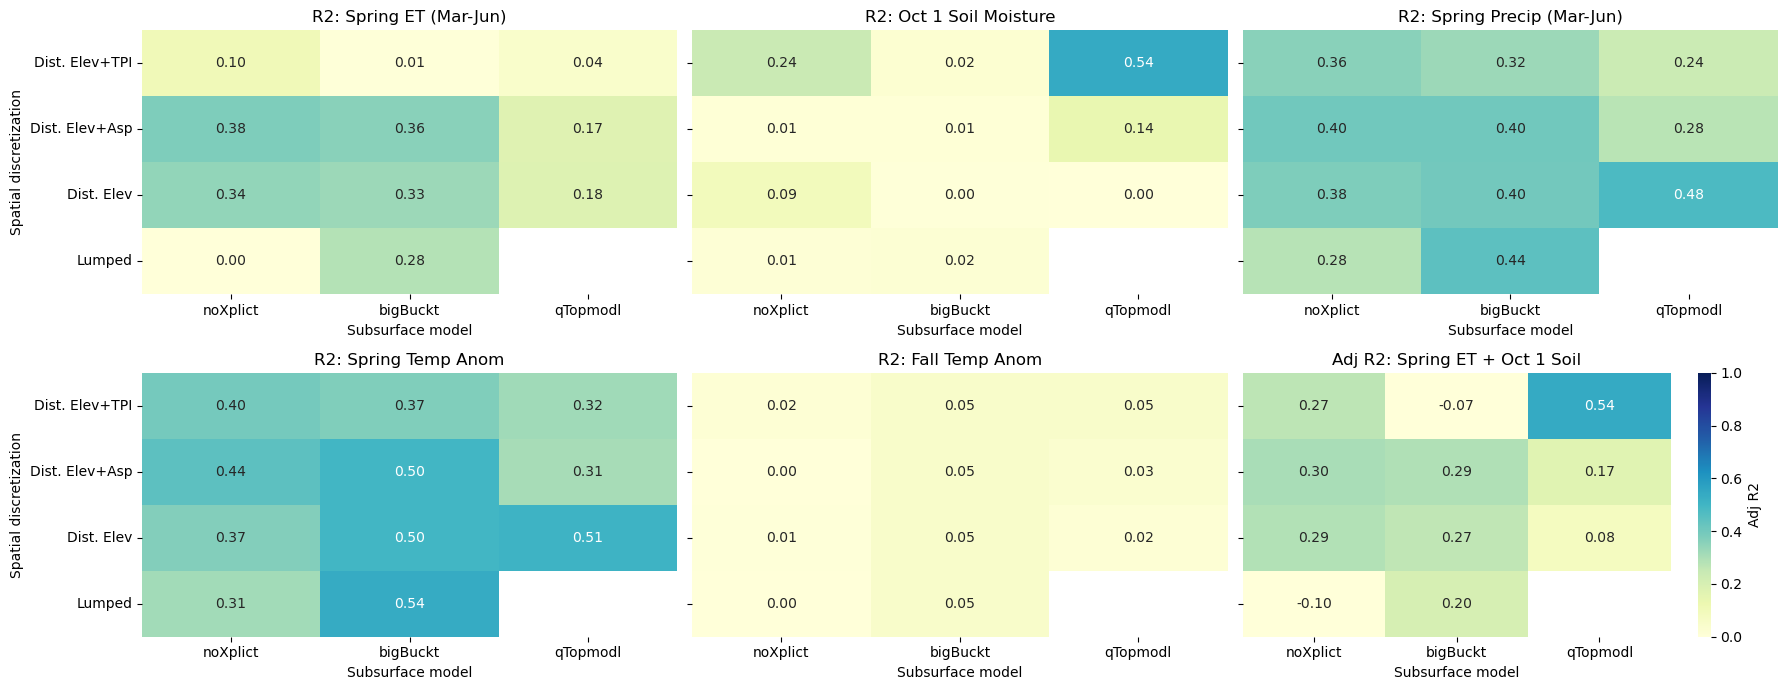

,spring_et,oct1_soil,spring_ppt,spring_temp,fall_temp,both_adj
subsurface,,,,,,
noXplict,0.205573,0.088321,0.354396,0.379569,0.006683,0.189170
bigBuckt,0.242955,0.014743,0.393264,0.476384,0.048722,0.171974
qTopmodl,0.132078,0.225920,0.330791,0.378889,0.032320,0.265326


In [ ]:
# Build annual mean discharge table for variance decomposition

target_domains = ['lumped', 'distributed_elev', 'distributed_elevAspect', 'distributed_elevTPI']
y_order = list(reversed(target_domains))
subsurface_map = {
    'bigBuckt': 'bigBuckt',
    'qTopmodl': 'qTopmodl',
    'noXplict_drainage': 'noXplict',
}
subsurface_order = ['noXplict', 'bigBuckt', 'qTopmodl']

def _combine_series(existing, new):
    if existing is None:
        return new
    return pd.concat([existing, new], axis=1).mean(axis=1)


def _norm_iqr(df, axis=0):
    q75 = df.quantile(0.75, axis=axis)
    q25 = df.quantile(0.25, axis=axis)
    med = df.median(axis=axis).replace(0, np.nan)
    return (q75 - q25) / med


def _norm_iqr_1d(series):
    q75 = series.quantile(0.75)
    q25 = series.quantile(0.25)
    med = series.median()
    if med == 0:
        return np.nan
    return (q75 - q25) / med


annual_q = {}
for domain in target_domains:
    for model_key, sim_df in model_discharge.get(domain, {}).items():
        subsurface = subsurface_map.get(model_key)
        if subsurface is None:
            continue
        q_wy = sim_df.resample('YS-OCT').mean()
        q_wy = q_wy[q_wy.index.year <= 2021]
        q_wy.index = q_wy.index
        key = (domain, subsurface)
        annual_q[key] = _combine_series(annual_q.get(key), q_wy)

annual_q_df = pd.DataFrame(annual_q)
annual_q_df.columns = pd.MultiIndex.from_tuples(annual_q_df.columns, names=['domain', 'subsurface'])
col_order = [(d, s) for d in target_domains for s in subsurface_order if (d, s) in annual_q_df.columns]
annual_q_df = annual_q_df.reindex(columns=pd.MultiIndex.from_tuples(col_order, names=['domain', 'subsurface']))
annual_q_df.index = annual_q_df.index.year

# Total timeseries spread (normalized IQR across years)
spread_norm = _norm_iqr(annual_q_df, axis=0)
spread_df = spread_norm.unstack('subsurface').reindex(index=y_order, columns=subsurface_order)
spread_df.index = [domain_labels[d] for d in spread_df.index]

plt.figure(figsize=(7.5, 4))
sns.heatmap(spread_df, annot=True, fmt='.2f', cmap='mako', cbar_kws={'label': 'Norm IQR (IQR/median)'})
plt.title('Normalized IQR Spread by Subsurface and Spatial')
plt.xlabel('Subsurface model')
plt.ylabel('Spatial discretization')
plt.tight_layout()
plt.show()

# Normalized IQR decomposition per year
domain_keys = annual_q_df.columns.get_level_values('domain').unique()
subsurface_keys = annual_q_df.columns.get_level_values('subsurface').unique()
sub_spread_by_domain = pd.concat(
    {
        d: _norm_iqr(annual_q_df.xs(d, level='domain', axis=1), axis=1)
        for d in domain_keys
    },
    axis=1,
)
spatial_spread_by_model = pd.concat(
    {
        s: _norm_iqr(annual_q_df.xs(s, level='subsurface', axis=1), axis=1)
        for s in subsurface_keys
    },
    axis=1,
)

spread_subsurface = sub_spread_by_domain.mean(axis=1)
spread_spatial = spatial_spread_by_model.mean(axis=1)

ratio_sub = spread_subsurface / (spread_subsurface + spread_spatial)
ratio_spatial = 1.0 - ratio_sub

streamflow_spread_by_domain = pd.Series(
    {
        d: _norm_iqr_1d(pd.Series(annual_q_df.xs(d, level='domain', axis=1).to_numpy().ravel()))
        for d in domain_keys
    }
)
streamflow_spread_by_model = pd.Series(
    {
        s: _norm_iqr_1d(pd.Series(annual_q_df.xs(s, level='subsurface', axis=1).to_numpy().ravel()))
        for s in subsurface_keys
    }
)
streamflow_spread_domain = streamflow_spread_by_domain.mean()
streamflow_spread_model = streamflow_spread_by_model.mean()
ratio_sub_to_flow = float(spread_subsurface.mean() / streamflow_spread_domain)
ratio_spatial_to_flow = float(spread_spatial.mean() / streamflow_spread_model)

decomp_summary = pd.DataFrame(
    {
        'norm_iqr_subsurface_mean': [spread_subsurface.mean()],
        'norm_iqr_spatial_mean': [spread_spatial.mean()],
        'ratio_subsurface': [ratio_sub.mean()],
        'ratio_spatial': [ratio_spatial.mean()],
        'ratio_sub_to_streamflow': [ratio_sub_to_flow],
        'ratio_spatial_to_streamflow': [ratio_spatial_to_flow],
    }
)
display(decomp_summary)

bar_values = [
    float(spread_subsurface.mean()),
    ratio_sub_to_flow,
    float(spread_spatial.mean()),
    ratio_spatial_to_flow,
 ]
plt.figure(figsize=(4.2, 4))
plt.bar(['subsurface', 'subsurface/Q', 'spatial', 'spatial/Q'], bar_values, color=['steelblue', 'salmon', 'steelblue', 'salmon'])
plt.ylabel('Mean norm IQR (IQR/median)')
plt.title('Normalized IQR Decomposition (mean across years)')
plt.tight_layout()
plt.show()

# Spring ET and Oct/Nov 1 soil moisture contributions

def _r2_pair(x, y):
    df = pd.concat([x, y], axis=1).dropna()
    if len(df) < 3:
        return np.nan
    return np.corrcoef(df.iloc[:, 0], df.iloc[:, 1])[0, 1] ** 2


def _r2_both(x, y1, y2):
    df = pd.concat([x, y1, y2], axis=1).dropna()
    if len(df) < 3:
        return np.nan
    X = df.iloc[:, 1:3].values
    y = df.iloc[:, 0].values
    reg = LinearRegression().fit(X, y)
    return reg.score(X, y)


def _r2_both_adj(x, y1, y2):
    df = pd.concat([x, y1, y2], axis=1).dropna()
    if len(df) < 4:
        return np.nan
    X = df.iloc[:, 1:3].values
    y = df.iloc[:, 0].values
    reg = LinearRegression().fit(X, y)
    r2 = reg.score(X, y)
    n = len(df)
    p = X.shape[1]
    if n <= p + 1:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)


spring_months = [3, 4, 5, 6]
fall_months = [9, 10, 11]
spring_et = {}
soil_oct1 = {}
spring_ppt = {}
spring_temp = {}
fall_temp = {}

for domain in target_domains:
    with xr.open_dataset(attr_paths[domain]) as attrs:
        hru_areas = attrs['HRUarea'].load()
    for model_key, filepath in model_files[domain].items():
        subsurface = subsurface_map.get(model_key)
        if subsurface is None:
            continue
        with xr.open_dataset(filepath) as ds:
            if 'scalarTotalET' not in ds.data_vars or 'scalarSnowSublimation' not in ds.data_vars:
                continue
            et_daily_df = (-ds['scalarTotalET'] * 3600).to_pandas()
            et_daily = (et_daily_df * hru_areas.values).sum(axis=1) / hru_areas.values.sum()
            et_daily = et_daily.resample('1D').sum()
            spring_daily = et_daily[et_daily.index.month.isin(spring_months)]
            spring_wy = spring_daily.resample('YS-OCT').sum()
            spring_wy = spring_wy[spring_wy.index.year <= 2021]
            spring_wy.index = spring_wy.index.year
            key = (domain, subsurface)
            spring_et[key] = _combine_series(spring_et.get(key), spring_wy)

            soil_var = None
            if 'scalarTotalSoilLiq' in ds.data_vars:
                soil_var = 'scalarTotalSoilLiq'
            elif 'scalarTotalSoilLiq_mean' in ds.data_vars:
                soil_var = 'scalarTotalSoilLiq_mean'
            if soil_var is None:
                continue
            soil_df = (ds[soil_var].to_pandas() * hru_areas.values).sum(axis=1) / hru_areas.values.sum()
            soil_df.index = pd.to_datetime(soil_df.index)

            dates_oct = pd.date_range(start='2001-10-01', end='2021-10-01', freq='YS-OCT')
            soil_oct = soil_df.reindex(dates_oct, method='nearest')
            soil_oct.index = soil_oct.index.year - 1
            soil_oct = pd.Series(soil_oct.values, index=soil_oct.index)
            soil_oct1[key] = _combine_series(soil_oct1.get(key), soil_oct)

            if 'pptrate' in ds.data_vars:
                p_rate = ds['pptrate']
                p_daily_df = (p_rate * 86400).to_pandas()
                p_daily = (p_daily_df * hru_areas.values).sum(axis=1) / hru_areas.values.sum()
                p_daily = p_daily.resample('1D').mean()
                spring_p_daily = p_daily[p_daily.index.month.isin(spring_months)]
                spring_p_wy = spring_p_daily.resample('YS-OCT').sum()
                spring_p_wy = spring_p_wy[spring_p_wy.index.year <= 2021]
                spring_p_wy.index = spring_p_wy.index.year
                spring_ppt[key] = _combine_series(spring_ppt.get(key), spring_p_wy)

            if 'airtemp' in ds.data_vars:
                t_daily_df = ds['airtemp'].to_pandas()
                t_daily = (t_daily_df * hru_areas.values).sum(axis=1) / hru_areas.values.sum()
                t_daily = t_daily.resample('1D').mean()
                spring_t_daily = t_daily[t_daily.index.month.isin(spring_months)]
                spring_t_wy = spring_t_daily.resample('YS-OCT').mean()
                spring_t_wy = spring_t_wy[spring_t_wy.index.year <= 2021]
                spring_t_wy.index = spring_t_wy.index.year
                spring_temp[key] = _combine_series(spring_temp.get(key), spring_t_wy)

                fall_t_daily = t_daily[t_daily.index.month.isin(fall_months)]
                fall_t_wy = fall_t_daily.resample('YS-OCT').mean()
                fall_t_wy = fall_t_wy[fall_t_wy.index.year <= 2021]
                fall_t_wy.index = fall_t_wy.index.year
                fall_temp[key] = _combine_series(fall_temp.get(key), fall_t_wy)

spring_et_df = pd.DataFrame(spring_et)
spring_et_df.columns = pd.MultiIndex.from_tuples(spring_et_df.columns, names=['domain', 'subsurface'])
spring_et_df = spring_et_df.reindex(columns=annual_q_df.columns)

soil_oct_df = pd.DataFrame(soil_oct1)
soil_oct_df.columns = pd.MultiIndex.from_tuples(soil_oct_df.columns, names=['domain', 'subsurface'])
soil_oct_df = soil_oct_df.reindex(columns=annual_q_df.columns)

spring_ppt_df = pd.DataFrame(spring_ppt)
spring_ppt_df.columns = pd.MultiIndex.from_tuples(spring_ppt_df.columns, names=['domain', 'subsurface'])
spring_ppt_df = spring_ppt_df.reindex(columns=annual_q_df.columns)

spring_temp_df = pd.DataFrame(spring_temp)
spring_temp_df.columns = pd.MultiIndex.from_tuples(spring_temp_df.columns, names=['domain', 'subsurface'])
spring_temp_df = spring_temp_df.reindex(columns=annual_q_df.columns)

fall_temp_df = pd.DataFrame(fall_temp)
fall_temp_df.columns = pd.MultiIndex.from_tuples(fall_temp_df.columns, names=['domain', 'subsurface'])
fall_temp_df = fall_temp_df.reindex(columns=annual_q_df.columns)

annual_q_anom = annual_q_df - annual_q_df.mean(axis=0)
spring_et_anom = spring_et_df - spring_et_df.mean(axis=0)
soil_oct_anom = soil_oct_df - soil_oct_df.mean(axis=0)
spring_ppt_anom = spring_ppt_df - spring_ppt_df.mean(axis=0)
spring_temp_anom = spring_temp_df - spring_temp_df.mean(axis=0)
fall_temp_anom = fall_temp_df - fall_temp_df.mean(axis=0)

r2_spring = {col: _r2_pair(annual_q_anom[col], spring_et_anom[col]) for col in annual_q_df.columns}
r2_oct = {col: _r2_pair(annual_q_anom[col], soil_oct_anom[col]) for col in annual_q_df.columns}
r2_spring_ppt = {col: _r2_pair(annual_q_anom[col], spring_ppt_anom[col]) for col in annual_q_df.columns}
r2_spring_temp = {col: _r2_pair(annual_q_anom[col], spring_temp_anom[col]) for col in annual_q_df.columns}
r2_fall_temp = {col: _r2_pair(annual_q_anom[col], fall_temp_anom[col]) for col in annual_q_df.columns}
r2_both_adj = {col: _r2_both_adj(annual_q_anom[col], spring_et_anom[col], soil_oct_anom[col]) for col in annual_q_df.columns}

r2_spring_series = pd.Series(r2_spring)
r2_spring_series.index = pd.MultiIndex.from_tuples(r2_spring_series.index, names=['domain', 'subsurface'])
r2_oct_series = pd.Series(r2_oct)
r2_oct_series.index = pd.MultiIndex.from_tuples(r2_oct_series.index, names=['domain', 'subsurface'])
r2_spring_ppt_series = pd.Series(r2_spring_ppt)
r2_spring_ppt_series.index = pd.MultiIndex.from_tuples(r2_spring_ppt_series.index, names=['domain', 'subsurface'])
r2_spring_temp_series = pd.Series(r2_spring_temp)
r2_spring_temp_series.index = pd.MultiIndex.from_tuples(r2_spring_temp_series.index, names=['domain', 'subsurface'])
r2_fall_temp_series = pd.Series(r2_fall_temp)
r2_fall_temp_series.index = pd.MultiIndex.from_tuples(r2_fall_temp_series.index, names=['domain', 'subsurface'])
r2_both_adj_series = pd.Series(r2_both_adj)
r2_both_adj_series.index = pd.MultiIndex.from_tuples(r2_both_adj_series.index, names=['domain', 'subsurface'])

r2_spring_df = r2_spring_series.unstack('subsurface').reindex(index=y_order, columns=subsurface_order)
r2_oct_df = r2_oct_series.unstack('subsurface').reindex(index=y_order, columns=subsurface_order)
r2_spring_ppt_df = r2_spring_ppt_series.unstack('subsurface').reindex(index=y_order, columns=subsurface_order)
r2_spring_temp_df = r2_spring_temp_series.unstack('subsurface').reindex(index=y_order, columns=subsurface_order)
r2_fall_temp_df = r2_fall_temp_series.unstack('subsurface').reindex(index=y_order, columns=subsurface_order)
r2_both_adj_df = r2_both_adj_series.unstack('subsurface').reindex(index=y_order, columns=subsurface_order)

r2_spring_df.index = [domain_labels[d] for d in r2_spring_df.index]
r2_oct_df.index = [domain_labels[d] for d in r2_oct_df.index]
r2_spring_ppt_df.index = [domain_labels[d] for d in r2_spring_ppt_df.index]
r2_spring_temp_df.index = [domain_labels[d] for d in r2_spring_temp_df.index]
r2_fall_temp_df.index = [domain_labels[d] for d in r2_fall_temp_df.index]
r2_both_adj_df.index = [domain_labels[d] for d in r2_both_adj_df.index]

fig, axes = plt.subplots(2, 3, figsize=(18, 7), sharey=True)
axes = axes.ravel()
sns.heatmap(r2_spring_df, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, ax=axes[0], cbar=False)
axes[0].set_title('R2: Spring ET (Mar-Jun)')
axes[0].set_xlabel('Subsurface model')
axes[0].set_ylabel('Spatial discretization')

sns.heatmap(r2_oct_df, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, ax=axes[1], cbar=False)
axes[1].set_title('R2: Oct 1 Soil Moisture')
axes[1].set_xlabel('Subsurface model')

sns.heatmap(r2_spring_ppt_df, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, ax=axes[2], cbar=False)
axes[2].set_title('R2: Spring Precip (Mar-Jun)')
axes[2].set_xlabel('Subsurface model')

sns.heatmap(r2_spring_temp_df, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, ax=axes[3], cbar=False)
axes[3].set_title('R2: Spring Temp Anom')
axes[3].set_xlabel('Subsurface model')
axes[3].set_ylabel('Spatial discretization')

sns.heatmap(r2_fall_temp_df, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, ax=axes[4], cbar=False)
axes[4].set_title('R2: Fall Temp Anom')
axes[4].set_xlabel('Subsurface model')

sns.heatmap(r2_both_adj_df, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1, ax=axes[5], cbar_kws={'label': 'Adj R2'})
axes[5].set_title('Adj R2: Spring ET + Oct 1 Soil')
axes[5].set_xlabel('Subsurface model')

plt.tight_layout()
plt.show()

r2_summary = pd.DataFrame(
    {
        'spring_et': r2_spring_df.mean(axis=0),
        'oct1_soil': r2_oct_df.mean(axis=0),
        'spring_ppt': r2_spring_ppt_df.mean(axis=0),
        'spring_temp': r2_spring_temp_df.mean(axis=0),
        'fall_temp': r2_fall_temp_df.mean(axis=0),
        'both_adj': r2_both_adj_df.mean(axis=0),
    }
)
display(r2_summary)

## Annual Water Balance
Stacked bar chart: **P = Q + ET + ΔS**
- **ET** = `scalarTotalET` + `scalarSnowSublimation`
- **ΔS** = Δsoil liquid + Δsoil ice + Δsnow (SWE) + Δaquifer storage (end-of-WY Sep 30)
- All depths in **mm / water year** (Oct 1 - Sep 30)
- Bars below zero (hatched) = storage drawdown contributing to Q

In [59]:
# Annual Water Balance  --  P = Q + ET + dS
# ET includes snow sublimation.  dS = dSoil + dSnow + dAquifer.
# All depths in mm per water year (Oct 1 - Sep 30).
#
# Unit conventions (SUMMA output):
#   pptrate, scalarTotalET, scalarSnowSublimation,
#   averageRoutedRunoff (or scalarTotalRunoff) : kg m-2 s-1 or m s-1
#     (all are per-area depth rates; x 3600 s/step -> mm/step; sum -> mm/WY)
#   scalarTotalSoilLiq, scalarTotalSoilIce, scalarSWE : kg m-2 = mm (water equiv.)
#   scalarAquiferStorage_mean                          : m  (x 1000 -> mm)

def _area_w(da, hru_areas):
    """Area-weighted spatial average, returns pandas Series."""
    if 'hru' in da.dims:
        df = da.to_pandas()
        return (df * hru_areas.values).sum(axis=1) / hru_areas.values.sum()
    return da.squeeze().to_pandas()


def compute_water_balance(domain, model_key, wys=range(2001, 2022)):
    """
    Compute annual water balance for one SUMMA configuration.
    Returns DataFrame indexed by water year (int) with columns:
      P, ET, Q, dS_soil, dS_snow, dS_aquifer, dS_total, residual  [mm/WY]

    Q is computed from SUMMA's averageRoutedRunoff (m/s) integrated over the
    water year:  m/s x 3600 s/step x 1000 mm/m, summed over all hourly steps.
    This is the same unit treatment as P and ET.
    """
    filepath = model_files[domain][model_key]
    with xr.open_dataset(filepath) as ds:
        hru_areas  = xr.open_dataset(attr_paths[domain])['HRUarea'].load()
        n_hru_ds   = ds.sizes.get('hru', 1)
        n_hru_attr = len(hru_areas)
        if n_hru_ds > n_hru_attr:          # routing GRU HRU appended in some configs
            ds = ds.isel(hru=slice(None, n_hru_attr))

        # Variable name discovery (handle _mean suffix variants)
        soil_liq_v = next((v for v in ['scalarTotalSoilLiq', 'scalarTotalSoilLiq_mean'] if v in ds.data_vars), None)
        soil_ice_v = next((v for v in ['scalarTotalSoilIce', 'scalarTotalSoilIce_mean'] if v in ds.data_vars), None)
        swe_v      = next((v for v in ['scalarSWE', 'scalarSWE_mean']                   if v in ds.data_vars), None)
        has_aq     = 'scalarAquiferStorage_mean' in ds.data_vars

        # Resample storage variables to daily for end-of-WY snapshots
        soil  = (_area_w(ds[soil_liq_v].resample(time='1D').mean(), hru_areas) +
                 _area_w(ds[soil_ice_v].resample(time='1D').mean(), hru_areas))
        snow  = _area_w(ds[swe_v].resample(time='1D').mean(), hru_areas)
        aquif = (_area_w(ds['scalarAquiferStorage_mean'].resample(time='1D').mean(), hru_areas) * 1000
                 if has_aq else pd.Series(0.0, index=soil.index))

        def sep30(series, year):
            """Last storage value in late September of year."""
            sl = series.loc[f'{year}-09-25':f'{year}-09-30']
            return float(sl.iloc[-1]) if len(sl) else np.nan

        records = []
        for wy in wys:
            t0, t1 = f'{wy-1}-10-01', f'{wy}-09-30'
            q_wy = (annual_q_dict[domain,model_key]['annual_q'].loc[wy] / basin_area_m2 * 1000 * 86400).values[0]# mm/WY
            wy_precip = precip_wy[wy] * 0.88
            et_wy = (-_area_w((ds['scalarTotalET']+ds['scalarSnowSublimation']).sel(time=slice(t0, t1)), hru_areas) * 3600).sum()  # mm/WY
            ds_soil = sep30(soil, wy) - sep30(soil, wy-1)
            ds_snow = sep30(snow, wy) - sep30(snow, wy-1)
            ds_aquifer = sep30(aquif, wy) - sep30(aquif, wy-1)
            ds_total = wy_precip - q_wy - et_wy 
            residual = wy_precip - q_wy - et_wy - ds_total
            # -- Precipitation [mm/WY] ----------------------------------------
            # pptrate (kg m-2 s-1) x 3600 s/step -> mm/step; sum over WY -> mm
            

            records.append(dict(
                wy=wy, P=wy_precip, ET=et_wy, Q=q_wy,
                dS_soil=ds_soil, dS_snow=ds_snow, dS_aquifer=ds_aquifer,
                dS_total=ds_total, residual=residual,
            ))
    return pd.DataFrame(records).set_index('wy')



In [60]:

# ---- Compute for selected model configurations --------------------------
wb_models = {
    # ('lumped',           'bigBuckt'):         'Lumped - Aquifer',
    # ('lumped',           'noXplict_drainage'):'Lumped - Soil',
    ('distributed_elevAspect', 'bigBuckt'):         'Dist. Elevation - Aquifer',
    # ('distributed_elev', 'noXplict_drainage'):'Dist. Elevation - Soil',
}
wb_data = {lbl: compute_water_balance(*key)
           for key, lbl in wb_models.items()}




Model                                     P       Q      ET      dS   Resid  mm/WY
---------------------------------------------------------------------------
Dist. Elevation - Aquifer               727     360     372      -4       0


(-100.0, 1100.0)

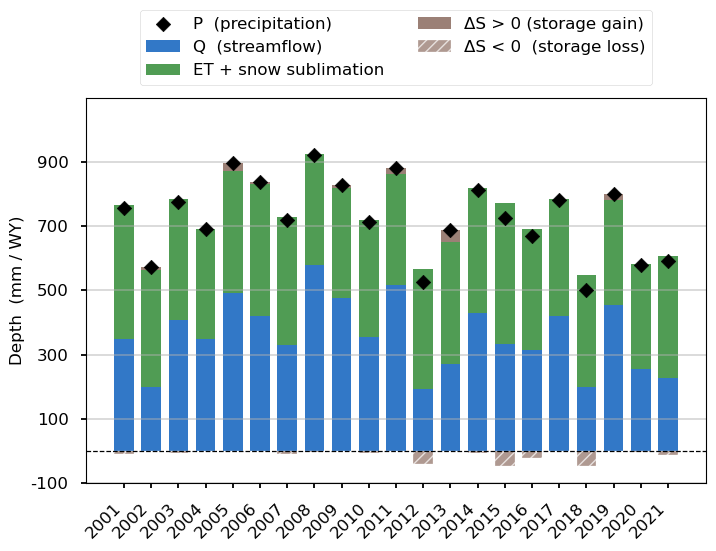

In [61]:

# ---- Plot ---------------------------------------------------------------
COMP_COLORS = dict(
    Q          = '#1565C0',   # blue
    ET         = '#388E3C',   # green
    dS_soil    = '#8D6E63',   # warm brown
    dS_snow    = '#90CAF9',   # pale blue
    dS_aquifer = '#8D6E63',   # navy
    dS_total   = '#8D6E63',   # warm brown
)
COMP_LABELS = dict(
    Q          = 'Q  (streamflow)',
    ET         = 'ET + snow sublimation',
    # dS_soil    = 'dS  soil (liq + ice)',
    # dS_snow    = 'dS  snow (SWE)',
    # dS_aquifer = 'dS  aquifer',
    dS_total   = 'ΔS > 0 (storage gain)',
)

fig, ax = plt.subplots(figsize=(8, 5))

for (lbl, wb) in wb_data.items():
    yrs = wb.index.values
    x   = np.arange(len(yrs))
    w   = 0.72

    # Positive stacks: Q at bottom, ET above, then positive dS components
    pos_bottom = np.zeros(len(yrs))
    for col in ['Q', 'ET', 'dS_total']:
        vals = wb[col].fillna(0).clip(lower=0).values
        if np.all(vals == 0):
            continue
        ax.bar(x, vals, w, bottom=pos_bottom,
               color=COMP_COLORS[col], label=COMP_LABELS[col], alpha=0.88)
        pos_bottom += vals

    # Negative dS below zero: storage drawn down (hatched, same color)
    neg_bottom = np.zeros(len(yrs))
    first_neg = True
    for col in ['dS_total']:
        vals = wb[col].fillna(0).clip(upper=0).values
        if np.all(vals == 0):
            continue
        kw = dict(label='ΔS < 0  (storage loss)') if first_neg else {}
        ax.bar(x, vals, w, bottom=neg_bottom,
               color=COMP_COLORS[col], alpha=0.7, hatch='///',
               edgecolor='white', linewidth=0.3, **kw)
        neg_bottom += vals
        first_neg = False

    # P as black diamond markers at the top of what should be each bar
    ax.scatter(x, wb['P'].values, color='black', zorder=6, s=55,
               marker='D', label='P  (precipitation)')

    # Residual triangles: P - Q - ET - dS (small = good closure)
    # ax.scatter(x, wb['residual'].values, color='#E65100', zorder=7,
    #            s=22, marker='^', alpha=0.85, label='Residual  (P - Q - ET - dS)')
    ax.grid(True, axis='y', alpha=0.5)
    ax.axhline(0, color='k', lw=0.9, ls='--', alpha=1)
    ax.set_xticks(x)
    ax.set_xticklabels(yrs, rotation=45, ha='right', fontsize=12)
    ax.set_yticks(np.arange(-100, 1100, 200))
    ax.set_yticklabels([f'{y:.0f}' for y in np.arange(-100, 1100, 200)], fontsize=12)
    ax.set_ylabel('Depth  (mm / WY)', fontsize=12)

# Shared, deduplicated legend
seen = {}
for h, l in zip(*ax.get_legend_handles_labels()):
    if l not in seen:
        seen[l] = h
        
# plt.savefig('../figures/fig_water_balance_annual.png', dpi=150, bbox_inches='tight')
plt.legend(ncols=2, bbox_to_anchor=(0.5, 1.25), loc='upper center', fontsize=12, framealpha=0.9)

# Summary table
print(f"\n{'Model':<35}  {'P':>6}  {'Q':>6}  {'ET':>6}  {'dS':>6}  {'Resid':>6}  mm/WY")
print('-' * 75)
for lbl, wb in wb_data.items():
    m = wb.mean()
    print(f"{lbl:<35}  {m['P']:>6.0f}  {m['Q']:>6.0f}  {m['ET']:>6.0f}"
          f"  {m['dS_total']:>6.0f}  {m['residual']:>6.0f}")

ax.set_ylim(-100, 1100)


In [64]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
# variance explained (coefficient of dETermination) for each predictor separately, and both togETher (R2_adj)
# predictors: total ET, dS_aquifer, ET
model.fit(wb['ET'].values.reshape(-1, 1), wb['Q'].values)
r2_ET = model.score(wb['ET'].values.reshape(-1, 1), wb['Q'].values)
model.fit(wb['dS_aquifer'].values.reshape(-1, 1)[1:], wb['Q'].shift(1).values[1:])
r2_ds = model.score(wb['dS_aquifer'].values.reshape(-1, 1)[1:], wb['Q'].shift(1).values[1:])
model.fit(wb[['ET', 'dS_aquifer']].values, wb['Q'].values)
r2_both = model.score(wb[['ET', 'dS_aquifer']].values, wb['Q'].values)
n = len(wb)
p = 2
r2_adj = 1 - (1 - r2_both) * (n - 1) / (n - p - 1)
print(f"\nVariance explained (R2): ET alone: {r2_ET:.2f}, dS alone: {r2_ds:.2f}, both: {r2_both:.2f}, adj R2: {r2_adj:.2f}")



Variance explained (R2): ET alone: 0.01, dS alone: 0.47, both: 0.23, adj R2: 0.14


## Elevation-Band Triangle + Elevation×Aspect Rose Diagram
Aggregate mean annual ET by elevation class (triangle, `distributed_elev`) and
elevation × aspect class (pentagon rose, `distributed_elevAspect`).
- **Elevation classes 1–5**: 2686 → 3997 m (low → high)
- **Aspect classes**: 0 = Mixed/S-ish, 1 = N, 2 = E, 3 = S, 4 = W
- Color = area-weighted mean annual ET + sublimation (mm / WY)

/tmp/ipykernel_811970/571785768.py:93: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  means_e      = gdf_e.groupby('elevClass').apply(aw_mean)/2
/tmp/ipykernel_811970/571785768.py:94: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  means_ea     = gdf_ea_nsew.groupby(['elevClass', 'aspectClas']).apply(aw_mean)
/tmp/ipykernel_811970/571785768.py:95: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. T

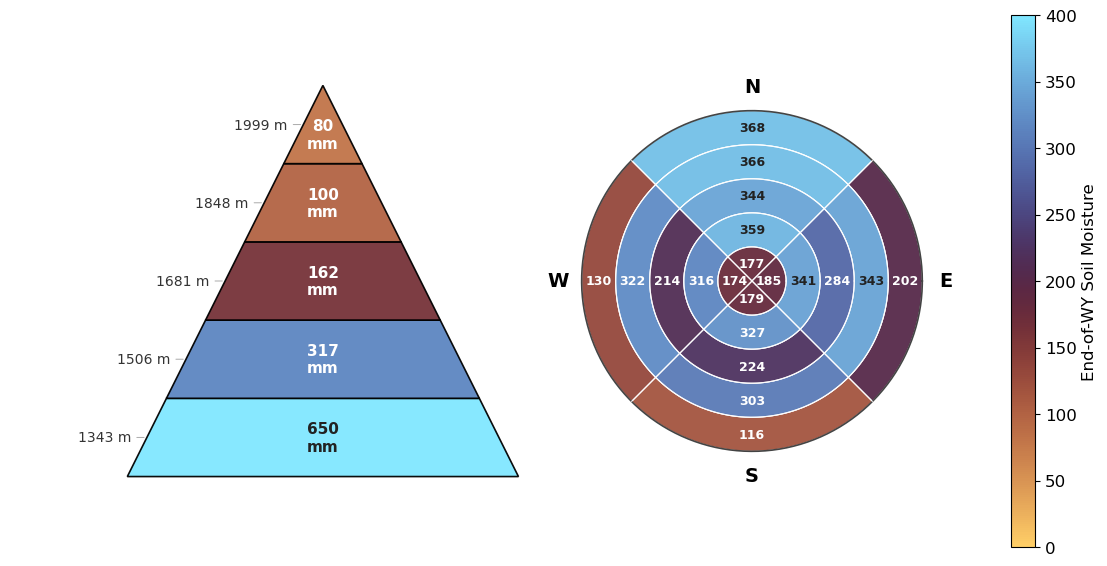

In [ ]:
# Elevation-Band Triangle  +  Elevation × Aspect Rose Diagram
# Coloring = area-weighted mean annual ET + sublimation  (mm / WY, water years)
#
# Data sources:
#   Triangle : distributed_elev domain  (5 HRUs, one per elevation band)
#   Rose     : distributed_elevAspect   (20 HRUs = 5 elev x 4 aspect classes)
#
# Aspect class mapping (from attributes.nc):
#   1 = N  (~3 deg)
#   2 = E  (~86 deg)
#   3 = S  (~183 deg)
#   4 = W  (~263 deg)

from matplotlib.patches import Polygon as MplPoly
from matplotlib.colorbar import ColorbarBase
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from glob import glob
import geopandas as gpd
import pandas as pd

# -- Config ---------------------------------------------------------------
MODEL_KEY  = 'qTopmodl'
YEAR_SLICE = slice('2001', '2021')
CMAP_NAME  = 'managua'

DOMAIN_E   = 'distributed_elev'
DOMAIN_EA  = 'distributed_elevAspect'

# 4 aspect classes (drop class 0 = Mixed), clockwise from N
ASP_ORDER  = [4, 3, 2, 1]
ASP_LABELS = {4: 'N', 3: 'E', 2: 'S', 1: 'W'}
N_ASP      = 4
HALF_SEC   = np.pi / N_ASP   # 45-degree half-width

N_ELEV  = 5
RADII   = np.linspace(0, 1, N_ELEV + 1)
# elev_class -> (r_inner, r_outer): class 5 innermost, class 1 outermost
RING_R  = {ec: (RADII[N_ELEV - ec], RADII[N_ELEV - ec + 1]) for ec in range(1, N_ELEV + 1)}

# -- Geometry helpers ------------------------------------------------------
def asp_to_math(deg):
    """Compass bearing (0=N, CW) -> math angle (0=E, CCW) in radians."""
    return np.radians(90.0 - deg)

def sector_verts(r_in, r_out, theta1, theta2, n=50):
    ts    = np.linspace(theta1, theta2, n)
    outer = np.c_[r_out * np.cos(ts), r_out * np.sin(ts)]
    inner = np.c_[r_in  * np.cos(ts[::-1]), r_in * np.sin(ts[::-1])]
    return np.vstack([outer, inner])

def tri_band_verts(y_hi, y_lo):
    """Horizontal band in a unit isosceles triangle; apex (0,1), base (+-1,-1)."""
    xh = (1.0 - y_hi) / 2.0
    xl = (1.0 - y_lo) / 2.0
    return [(-xh, y_hi), (xh, y_hi), (xl, y_lo), (-xl, y_lo)]

# -- Load data ------------------------------------------------------------
def hru_et_annual(domain, model_key=MODEL_KEY, yr=YEAR_SLICE):
    ds  = xr.open_dataset(model_files[domain][model_key])
    et  = ds['scalarTotalSoilLiq']# (-(ds['scalarTotalET'] + ds['scalarSnowSublimation'])*3600)
    ann = et.where(et.time.dt.month.isin([3,4,5,6,7,8,9,10])).resample(time='YS-OCT').last().sel(time=yr).mean(dim='time')
    return ann.to_pandas().to_dict()

et_e  = hru_et_annual(DOMAIN_E)
et_ea = hru_et_annual(DOMAIN_EA)

def load_gdf(domain, et_dict):
    shp = glob(f'{shapefile_catchment_dirs[domain]}/*.shp')[0]
    gdf = gpd.read_file(shp)
    gdf['et'] = gdf['HRU_ID'].map(et_dict)
    return gdf

def load_actual_aspect(domain):
    ds = xr.open_dataset(attr_paths[domain])
    return pd.DataFrame({'HRU_ID': ds['hruId'].values,
                         'actual_aspect': ds['aspect'].values})

gdf_e  = load_gdf(DOMAIN_E,  et_e)
gdf_ea = load_gdf(DOMAIN_EA, et_ea)
gdf_ea = gdf_ea.merge(load_actual_aspect(DOMAIN_EA), on='HRU_ID')

# Drop class 0 (Mixed) from rose computation
gdf_ea_nsew = gdf_ea[gdf_ea['aspectClas'] != 0].copy()

# Area-weighted means
def aw_mean(grp):
    return np.average(grp['et'], weights=grp['HRU_area'])

def aw_mean_elev(grp):
    return np.average(grp['elev_mean'], weights=grp['HRU_area'])

means_e      = gdf_e.groupby('elevClass').apply(aw_mean)/2
means_ea     = gdf_ea_nsew.groupby(['elevClass', 'aspectClas']).apply(aw_mean)
mean_elev    = gdf_e.groupby('elevClass').apply(aw_mean_elev)/2
mean_elev_ea = gdf_ea.groupby('elevClass').apply(aw_mean_elev)

# -- Color normalization (shared) -----------------------------------------
all_vals = np.concatenate([means_e.values, means_ea.values])
vmin, vmax = 0,400
norm   = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap_f = cm.get_cmap(CMAP_NAME)

def fc(val):
    if pd.isna(val) or np.isnan(float(val)):
        return '#cccccc'
    return cmap_f(norm(float(val)))

def text_color(val):
    rgba = cmap_f(norm(float(val)))
    lum  = 0.299*rgba[0] + 0.587*rgba[1] + 0.114*rgba[2]
    return 'white' if lum < 0.55 else '#222222'

# -- Figure ----------------------------------------------------------------
fig = plt.figure(figsize=(11, 7))
ax_tri = fig.add_axes([0.00, 0.01, 0.48, 0.98])
ax_ros = fig.add_axes([0.45, 0.01, 0.48, 0.98])
ax_cb  = fig.add_axes([0.91, 0.12, 0.022, 0.76])

# =====================================================================
# LEFT: Elevation Triangle
# Class 5 (highest) at apex; class 1 (lowest) at base.
# =====================================================================
y_edges = np.linspace(-1, 1, N_ELEV + 1)

for band_i, ec in enumerate(range(1, N_ELEV + 1)):
    y_lo = y_edges[band_i]
    y_hi = y_edges[band_i + 1]
    val  = means_e.get(ec, np.nan)

    verts = tri_band_verts(y_hi, y_lo)
    ax_tri.add_patch(MplPoly(verts, closed=True, facecolor=fc(val),
                              edgecolor='black', linewidth=1.2, alpha=0.95, zorder=2))

    y_mid       = (y_lo + y_hi) / 2.0
    x_left_edge = -(1.0 - y_mid) / 2.0
    elev_m      = mean_elev.get(ec, np.nan)

    if not np.isnan(float(val)):
        if band_i == 4:
            shift = 0.05
        else: shift = 0
        ax_tri.text(0, y_mid-shift, f'{val:.0f}\nmm',
                    ha='center', va='center', fontsize=11, fontweight='bold',
                    color=text_color(val), zorder=3)


    ax_tri.annotate(
        f'{elev_m:.0f} m',
        xy=(x_left_edge, y_mid),
        xytext=(x_left_edge - 0.08, y_mid),
        fontsize=10, ha='right', va='center', color='#333333',
        arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.7),
    )

ax_tri.set_xlim(-1.6, 1.1)
ax_tri.set_ylim(-1.15, 1.15)
ax_tri.set_aspect('equal')
ax_tri.axis('off')

# =====================================================================
# RIGHT: Elevation x Aspect Rose (4-sector: N/E/S/W)
# 4 sectors at 90-deg spacing CW from N; 5 rings (class 5 innermost).
# =====================================================================
theta_full = np.linspace(0, 2 * np.pi, 300)

for asp_pos, asp_cls in enumerate(ASP_ORDER):
    bearing_deg = asp_pos * 90.0    # N=0, E=90, S=180, W=270
    center_math = asp_to_math(bearing_deg)
    theta1      = center_math - HALF_SEC
    theta2      = center_math + HALF_SEC

    for elev_cls in range(1, N_ELEV + 1):
        r_in, r_out = RING_R[elev_cls]
        try:
            val = float(means_ea.loc[(elev_cls, asp_cls)])
        except KeyError:
            val = np.nan

        verts = sector_verts(r_in, r_out, theta1, theta2)
        ax_ros.add_patch(MplPoly(verts, closed=True, facecolor=fc(val),
                                  edgecolor='white', linewidth=0.8, alpha=0.95, zorder=2))

        r_mid = (r_in + r_out) / 2.0
        t_mid = (theta1 + theta2) / 2.0
        if not np.isnan(val):
            ax_ros.text(r_mid * np.cos(t_mid), r_mid * np.sin(t_mid),
                        f'{val:.0f}',
                        ha='center', va='center', fontsize=9, fontweight='bold',
                        color=text_color(val), zorder=3)

    # Compass direction labels
    r_lbl   = RADII[-1] + 0.14
    angle_m = asp_to_math(bearing_deg)
    ax_ros.text(r_lbl * np.cos(angle_m), r_lbl * np.sin(angle_m),
                ASP_LABELS[asp_cls], ha='center', va='center',
                fontsize=14, fontweight='bold')

# Outer circle
ax_ros.plot(np.cos(theta_full), np.sin(theta_full),
            color='#444444', lw=1.2, zorder=4)

# Inner ring boundaries
for r in RADII[1:-1]:
    ax_ros.plot(r * np.cos(theta_full), r * np.sin(theta_full),
                color='white', lw=0.8, zorder=4, alpha=0.8)

# Spoke lines at sector edges
for asp_pos in range(N_ASP):
    bearing_deg = asp_pos * 90.0
    edge_math   = asp_to_math(bearing_deg) + HALF_SEC
    ax_ros.plot([0, np.cos(edge_math)], [0, np.sin(edge_math)],
                color='white', lw=0.8, zorder=4, alpha=0.8,)

# Elevation ring labels along NE diagonal (between N and E sectors)
# Each ring center sits at (r_mid*cos45, r_mid*sin45); labels go outside
DIAG = np.radians(45)   # math angle for NE direction
for elev_cls in range(1, N_ELEV + 1):
    r_in, r_out = RING_R[elev_cls]
    r_mid       = (r_in + r_out) / 2.0
    elev_m      = mean_elev_ea.get(elev_cls, np.nan)
    x_ring = r_mid  * np.cos(DIAG)
    y_ring = r_mid  * np.sin(DIAG)
    x_lbl  = (RADII[-1] + 0.20) * np.cos(DIAG)
    y_lbl  = (RADII[-1] + 0.20) * np.sin(DIAG)

ax_ros.set_xlim(-1.45, 1.65)
ax_ros.set_ylim(-1.35, 1.35)
ax_ros.set_aspect('equal')
ax_ros.axis('off')

# -- Shared colorbar -------------------------------------------------------
cb = ColorbarBase(ax_cb, cmap=cmap_f, norm=norm, orientation='vertical', )
cb.set_label('End-of-WY Soil Moisture', fontsize=12)
cb.ax.tick_params(labelsize=12)

# plt.savefig('../figures/fig_elev_aspect_rose.png', dpi=150, bbox_inches='tight')
plt.show()
